In [1]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [ ]:
# file = 'root://cms-xrd-global.cern.ch//store/mc/RunIII2024Summer24NanoAODv15/TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v3/2810000/f60b4a6c-2801-43b0-b542-6d933a71a396.root'
# factory = NanoEventsFactory.from_root(
#     f"{file}:Events",
#     schemaclass=NanoAODSchema,
# )
# events = factory.events()

In [4]:
file = 'root://xrootd-cms.infn.it//store/mc/RunIII2024Summer24NanoAODv15/DYto2Mu-2Jets_Bin-MLL-50_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v6/2520000/3a3ff919-a8b6-4054-9518-2b203bb702b1.root'
# file = 'root://cms-xrd-global.cern.ch//store/mc/RunIII2024Summer24NanoAODv15/TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v3/2810000/a808fa28-4a7b-4807-aa90-9678f775f9b2.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [5]:
file = 'root://xrootd-cms.infn.it///store/mc/RunIII2024Summer24NanoAODv15/DYGto2LG-1Jets_Bin-MLL-50_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v2/2820000/9f7060c9-1795-4f0d-83a4-55c8adc3ea41.root'
# file = 'root://cms-xrd-global.cern.ch//store/mc/RunIII2024Summer24NanoAODv15/TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v3/2810000/a808fa28-4a7b-4807-aa90-9678f775f9b2.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events_DYG = factory.events()

In [4]:
events.fields

['HTXS',
 'FatJet',
 'Dataset',
 'DeepMETResponseTune',
 'SoftActivityJet',
 'GenJetAK8',
 'SoftActivityJetHT10',
 'DST',
 'luminosityBlock',
 'CorrT1METJet',
 'SoftActivityJetNjets2',
 'Jet',
 'boostedTau',
 'GenDressedLepton',
 'GenVtx',
 'Pileup',
 'SoftActivityJetHT2',
 'FiducialMET',
 'TrackGenJetAK4',
 'LHE',
 'L1',
 'orbitNumber',
 'TauProd',
 'Rho',
 'RawPFMET',
 'HLTriggerFinalPath',
 'run',
 'genTtbarId',
 'SoftActivityJetNjets10',
 'Electron',
 'SoftActivityJetHT5',
 'PFMET',
 'BeamSpot',
 'TauSpinner',
 'Flag',
 'SoftActivityJetHT',
 'genWeight',
 'Tau',
 'MC',
 'FsrPhoton',
 'SoftActivityJetNjets5',
 'LowPtElectron',
 'SV',
 'GenJet',
 'PFCand',
 'event',
 'LHEReweightingWeight',
 'LHEPart',
 'GenMET',
 'IsoTrack',
 'L1Reco',
 'L1simulation',
 'GenPart',
 'SubJet',
 'TrkMET',
 'HLT',
 'CaloMET',
 'Generator',
 'LHEPdfWeight',
 'Photon',
 'OtherPV',
 'RawPuppiMET',
 'bunchCrossing',
 'LHEScaleWeight',
 'HLTriggerFirstPath',
 'GenVisTau',
 'PSWeight',
 'Muon',
 'GenProton',


In [6]:
len(events)

167357

In [7]:
len(events_DYG)

177193

In [20]:
genpart = events.GenPart
genpart_DYG = events_DYG.GenPart

In [7]:
genpart.fields

['genPartIdxMother',
 'statusFlags',
 'pdgId',
 'status',
 'eta',
 'mass',
 'phi',
 'pt',
 'iso',
 'genPartIdxMotherG',
 'distinctParentIdxG',
 'childrenIdxG',
 'distinctChildrenIdxG',
 'distinctChildrenDeepIdxG']

In [21]:
gen_photons = genpart[genpart.pdgId == 22]
gen_photons_DYG = genpart_DYG[genpart_DYG.pdgId == 22]

In [6]:
gen_photons.statusFlags

<Array [??, ??, ??, ??, ..., ??, ??, ??, ??] type='167357 * var * uint16[pa...'>

In [10]:
hard_photons = gen_photons[
    (gen_photons.statusFlags & (1 << 7)) != 0
]

from_hard_photons = gen_photons[
    (gen_photons.statusFlags & (1 << 8)) != 0
]

before_fsr_photons = gen_photons[
    (gen_photons.statusFlags & (1 << 11)) != 0
]

In [12]:
ak.any(ak.num(hard_photons)>0)

False

In [9]:
ak.any(ak.num(hard_photons.pt)>0)

False

In [ ]:
gen_photons.statusFlags*1

In [13]:
def print_photon_ancestry(events, event_index=0):
    """
    Print the generator ancestry of all photons in one event.
    """

    gen = events.GenPart[event_index]

    for i, p in enumerate(gen):

        if abs(p["pdgId"]) != 22:
            continue

        print("\nPhoton")
        print(
            f"  index       = {i}"
            f"\n  pt          = {p['pt']:.2f}"
            f"\n  statusFlags = {p['statusFlags']}"
            f"\n  mother      = {p['genPartIdxMother']}"
        )

        mother = p["genPartIdxMother"]
        depth = 0

        while mother >= 0 and depth < 20:

            m = gen[mother]

            print(
                f"  {'  ' * (depth + 1)}"
                f"mother index={mother}, "
                f"pdgId={m['pdgId']}, "
                f"pt={m['pt']:.2f}, "
                f"statusFlags={m['statusFlags']}"
            )

            mother = m["genPartIdxMother"]
            depth += 1

In [12]:
print_photon_ancestry(events, 0)


Photon
  index       = 10
  pt          = 0.15
  statusFlags = 12289
  mother      = 8
    mother index=8, pdgId=13, pt=61.38, statusFlags=22913
      mother index=6, pdgId=23, pt=43.88, statusFlags=10497
        mother index=5, pdgId=23, pt=45.62, statusFlags=257
          mother index=4, pdgId=23, pt=44.62, statusFlags=257
            mother index=2, pdgId=23, pt=43.38, statusFlags=4481
              mother index=0, pdgId=21, pt=0.00, statusFlags=10625


In [ ]:
ak.sum(ak.num(gen_photons.pt))

In [14]:
gen_photons_above15 = events.GenPart[
    (events.GenPart.pdgId == 22)
    & (events.GenPart.pt > 15)
]

gen_photons_above15_DYG = events_DYG.GenPart[
    (events_DYG.GenPart.pdgId == 22)
    & (events_DYG.GenPart.pt > 15)
]

In [15]:
ak.sum(ak.num(gen_photons_above15)>0)

10377

In [16]:
ak.sum(ak.num(gen_photons_above15_DYG)>0)

103521

In [28]:
gen_pho_mother = gen_photons_DYG.genPartIdxMother
genpart_DYG[gen_pho_mother].pdgId
pho_mother = genpart_DYG[genpart_DYG[gen_pho_mother].pdgId == 22]

In [30]:
pho_mother.pdgId

<Array [[], [], [], [], ..., [], [], [], []] type='177193 * var * int32[par...'>

In [24]:
gen_pho_mother

<Array [[6, 7, 11, 14], ..., [7, 8, ..., 32]] type='177193 * var * int16[pa...'>

In [16]:
def photon_mother_pdgid(events, pt_min=15):
    gen = events.GenPart

    photons = gen[
        (gen.pdgId == 22)
        & (gen.pt > pt_min)
    ]

    mother_pdgids = []

    for event_gen, event_photons in zip(gen, photons):

        event_mothers = []

        for photon in event_photons:

            mother_idx = photon.genPartIdxMother

            if mother_idx >= 0:
                event_mothers.append(
                    event_gen[mother_idx].pdgId
                )
            else:
                event_mothers.append(0)

        mother_pdgids.append(event_mothers)

    return ak.Array(mother_pdgids)

In [21]:
mother_pdgids_DYG = photon_mother_pdgid(events_DYG)

In [22]:
mother_pdgids_DYG

<Array [[23], [23], [23], [], ..., [], [23], []] type='177193 * var * int64'>

In [28]:
is_z_mother = abs(mother_pdgids_DYG) == 23

print(
    "Photons with Z mother:",
    ak.sum(ak.flatten(is_z_mother))
)

flags = gen_photons_above15_DYG.statusFlags

print(
    "Z-mother photons:",
    ak.sum(ak.flatten(is_z_mother))
)

print(
    "Z-mother + isHardProcess:",
    ak.sum(
        ak.flatten(
            is_z_mother &
            ((flags & (1 << 7)) != 0)
        )
    )
)

print(
    "Z-mother + fromHardProcess:",
    ak.sum(
        ak.flatten(
            is_z_mother &
            ((flags & (1 << 8)) != 0)
        )
    )
)

print(
    "Z-mother + fromHardProcessBeforeFSR:",
    ak.sum(
        ak.flatten(
            is_z_mother &
            ((flags & (1 << 11)) != 0)
        )
    )
)

Photons with Z mother: 73851
Z-mother photons: 73851


Z-mother + isHardProcess: 73851
Z-mother + fromHardProcess: 73851
Z-mother + fromHardProcessBeforeFSR: 0


In [30]:
ak.where(ak.num(mother_pdgids_DYG)>1)

(<Array [31, 32, 34, 47, ..., 177165, 177170, 177180] type='27429 * int64'>,)

In [33]:
from particle import Particle
from collections import Counter


def plot_mother_pdgid(mother_pdgids, title="Mother PDG ID distribution"):
    """
    Plot the distribution of mother PDG IDs.

    Parameters
    ----------
    mother_pdgids : awkward.Array
        Jagged array of mother PDG IDs.
    title : str
        Plot title.
    """

    # Flatten event structure
    pdgids = ak.to_numpy(ak.flatten(mother_pdgids))

    # Count each PDG ID
    counts = Counter(pdgids)

    # Sort by frequency
    counts = counts.most_common()

    ids = [x[0] for x in counts]
    values = [x[1] for x in counts]

    # Convert PDG IDs to particle names
    labels = []

    for pdgid in ids:
        try:
            particle = Particle.from_pdgid(int(pdgid))

            if particle is not None:
                name = particle.name
                labels.append(f"{name} ({pdgid})")
            else:
                labels.append(str(pdgid))

        except Exception:
            labels.append(str(pdgid))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(range(len(ids)), values)

    ax.set_xticks(range(len(ids)))
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
    )

    ax.set_xlabel("Mother particle")
    ax.set_ylabel("Number of photons")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

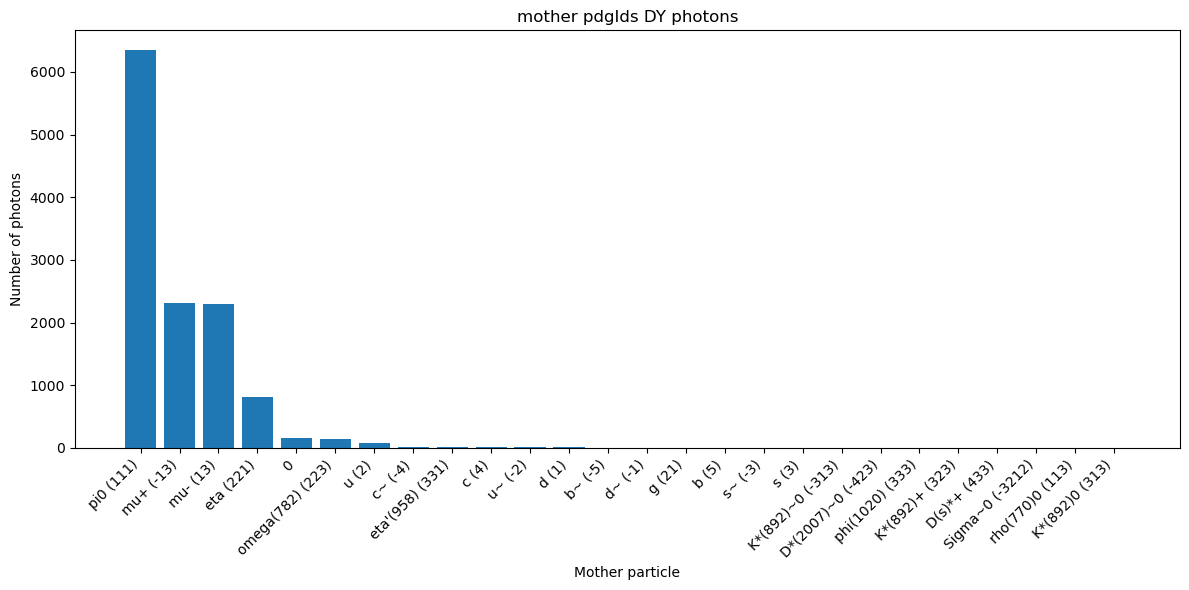

In [36]:
plot_mother_pdgid(mother_pdgids, title="mother pdgIds DY photons")

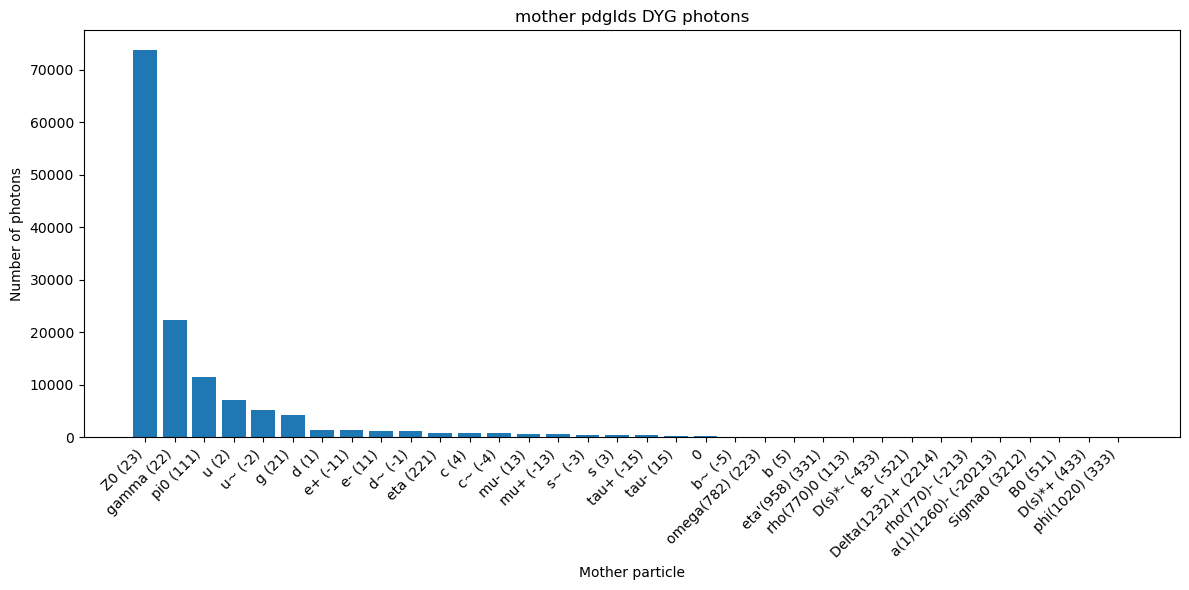

In [37]:
plot_mother_pdgid(mother_pdgids_DYG, "mother pdgIds DYG photons")

In [17]:
mother_pdgids = photon_mother_pdgid(events, pt_min=15)

In [18]:
n_muon_fsr = ak.sum(
    ak.flatten(
        (abs(mother_pdgids) == 13)
    )
)

n_electron_fsr = ak.sum(
    ak.flatten(
        (abs(mother_pdgids) == 11)
    )
)

print("Muon FSR photons:", n_muon_fsr)
print("Electron FSR photons:", n_electron_fsr)

Muon FSR photons: 4609
Electron FSR photons: 0


In [19]:
n_photons = ak.num(gen_photons_above15)

print("0 photons:", ak.sum(n_photons == 0))
print("1 photon :", ak.sum(n_photons == 1))
print("2 photons:", ak.sum(n_photons == 2))
print(">=3 photons:", ak.sum(n_photons >= 3))

0 photons: 156980
1 photon : 8982
2 photons: 1071
>=3 photons: 324


In [3]:
def draw_side_statboxes(canvas, hists,
                        x1=0.80, x2=0.98,
                        y_top=0.92,
                        box_height=0.18,
                        gap=0.02):
    """
    Draw stacked statboxes on the right side of a canvas.

    Parameters
    ----------
    canvas : ROOT.TCanvas
    hists  : list of ROOT.TH1
    x1,x2  : horizontal NDC range
    y_top  : top starting NDC position
    box_height : height of each box
    gap    : vertical gap between boxes
    """

    # Temporary canvas to force stat creation
    tmp = ROOT.TCanvas("tmp_stats", "", 1, 1)

    orig_stats = {}

    for h in hists:
        h.Draw("hist")
        tmp.Update()

        st = h.GetListOfFunctions().FindObject("stats")
        if not st:
            raise RuntimeError(f"Stats not created for {h.GetName()}")

        orig_stats[h] = st.Clone(f"stats_clone_{h.GetName()}")

    tmp.Close()

    # Disable automatic stat boxes
    ROOT.gStyle.SetOptStat(0)

    canvas.cd()
    canvas.SetRightMargin(0.2)

    # Draw stacked statboxes
    for i, (hst, st) in enumerate(orig_stats.items()):

        st.SetParent(canvas)

        y2 = y_top - i * (box_height + gap)
        y1 = y2 - box_height

        st.SetX1NDC(x1)
        st.SetX2NDC(x2)
        st.SetY1NDC(y1)
        st.SetY2NDC(y2)

        st.SetTextColor(hst.GetLineColor())
        st.SetTextFont(62)   # avoid TTF bug
        st.SetFillStyle(0)
        st.SetBorderSize(1)

        st.Draw()

    canvas.Modified()
    canvas.Update()


In [4]:
def CMS_label(pad,
              lumi="109 fb^{-1}",
              year="2024",
              energy="13.6 TeV",
              status="Simulation Preliminary",
              x=0.12,
              y=0.92):

    pad.cd()

    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextAngle(0)
    latex.SetTextColor(ROOT.kBlack)

    # ---- CMS (bold) ----
    latex.SetTextFont(61)
    latex.SetTextSize(0.06)
    latex.DrawLatex(x, y, "CMS")

    # ---- Status (italic) ----
    if status != "":
        latex.SetTextFont(52)
        latex.SetTextSize(0.045)
        latex.DrawLatex(x + 0.11, y, status)

    # ---- Lumi text (right aligned) ----
    latex.SetTextFont(42)
    latex.SetTextSize(0.045)
    latex.SetTextAlign(31)
    lumi_text = f"({year}_{lumi})"
    latex.DrawLatex(0.88, y, lumi_text)

In [5]:
import math

def merge_overflow(
    hist,
    add_underflow=False,
    add_overflow=True,
    label_overflow=True,
    float_format=".0f"
):
    """
    Merge overflow/underflow into visible bins.
    Optionally relabel last bin as ≥ upper_edge.

    Parameters
    ----------
    hist : ROOT.TH1
    add_underflow : bool
    add_overflow : bool
    label_overflow : bool
        If True, rename last bin to ≥ upper_edge
    float_format : str
        Formatting for upper edge (e.g. ".0f", ".1f")
    """

    n_bins = hist.GetNbinsX()

    # --- Underflow → first bin
    if add_underflow:
        underflow = hist.GetBinContent(0)
        first = hist.GetBinContent(1)

        hist.SetBinContent(1, first + underflow)

        err0 = hist.GetBinError(0)
        err1 = hist.GetBinError(1)
        hist.SetBinError(1, math.sqrt(err0**2 + err1**2))

        hist.SetBinContent(0, 0)
        hist.SetBinError(0, 0)

    # --- Overflow → last bin
    if add_overflow:
        overflow = hist.GetBinContent(n_bins + 1)
        last = hist.GetBinContent(n_bins)

        hist.SetBinContent(n_bins, last + overflow)

        errN = hist.GetBinError(n_bins)
        errOv = hist.GetBinError(n_bins + 1)
        hist.SetBinError(n_bins, math.sqrt(errN**2 + errOv**2))

        hist.SetBinContent(n_bins + 1, 0)
        hist.SetBinError(n_bins + 1, 0)

        # # --- Relabel last bin
        # if label_overflow:
        #     upper_edge = hist.GetXaxis().GetBinUpEdge(n_bins)
        #     label = f"#geq {format(upper_edge, float_format)}"
        #     hist.GetXaxis().SetBinLabel(n_bins, label)


In [6]:
Plot_dir = "/eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/"

In [7]:
def delta_r_manual(obj1, obj2):
    deta = obj1.eta[:, None] - obj2.eta
    dphi = np.abs(obj1.phi[:, None] - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

In [8]:
def object_preselections(
    photons: ak.Array,
    jets: ak.Array,
    electrons: ak.Array,
    muons: ak.Array,
    year="2018",
):
    """
    Apply object-level preselection only.
    Returns selected photons, bjets, and leptons.
    No event-level requirements applied here.
    """

    # ------------------------
    # Year-dependent lepton pT cuts
    # ------------------------
    if year.startswith("2016"):
        ele_pt_cut, mu_pt_cut = 27, 26
    elif year == "2017":
        ele_pt_cut, mu_pt_cut = 33, 29
    elif year == "2018":
        ele_pt_cut, mu_pt_cut = 33, 26
    elif year == "2024":
        ele_pt_cut, mu_pt_cut = 30, 24
    else:
        raise ValueError(f"Unknown year {year}")

    # ========================
    # ELECTRONS
    # ========================
    good_electrons = (
        (electrons.pt > ele_pt_cut) &
        (np.abs(electrons.eta) < 2.5) &
        ~((np.abs(electrons.eta) > 1.44) & (np.abs(electrons.eta) < 1.57)) &
        (electrons.mvaIso_WP80) &
        (electrons.pfRelIso03_all < 0.15)
    )

    selected_electrons = electrons[good_electrons]

    # ========================
    # MUONS
    # ========================
    good_muons = (
        (muons.pt > mu_pt_cut) &
        (np.abs(muons.eta) < 2.4) &
        (muons.pfRelIso03_all < 0.15)
    )

    selected_muons = muons[good_muons]

    # Combine leptons (object level only)
    selected_leptons = ak.concatenate(
        [selected_electrons, selected_muons],
        axis=1
    )

    # ========================
    # BJETS
    # ========================
    good_jets = (
        (jets.pt > 20) &
        (np.abs(jets.eta) < 2.4) &
        (jets.btagUParTAK4B > 0.1272)
    )

    selected_bjets = jets[good_jets]

    # ========================
    # PHOTONS
    # ========================
    abs_eta = np.abs(photons.eta)

    valid_eta = (
        (abs_eta <= 2.5) &
        ~((abs_eta >= 1.442) & (abs_eta <= 1.566))
    )

    is_barrel = abs_eta < 1.442
    is_endcap = (abs_eta > 1.566) & (abs_eta < 2.5)

    barrel_cut = is_barrel & (photons.mvaID > 0.0439603)
    endcap_cut = is_endcap & (photons.mvaID > -0.249526)

    good_photons = (
        (photons.pt > 15) &  # updated pT cut on photons
        valid_eta &
        (barrel_cut | endcap_cut) &
        (~photons.pixelSeed)
    )

    selected_photons = photons[good_photons]

    return selected_photons, selected_bjets, selected_leptons, selected_electrons, selected_muons


In [9]:
selected_photons, selected_bjets, selected_leptons, selected_electrons, selected_muons = object_preselections(
    events.Photon,
    events.Jet,
    events.Electron,
    events.Muon,
    year="2024"
)

one_ele = ak.num(selected_electrons) == 1
one_mu = ak.num(selected_muons) == 1
lepton_channel_mask = one_ele | one_mu
at_least_one_b = ak.num(selected_bjets) >= 1
at_least_two_pho = ak.num(selected_photons) >= 2
dr = delta_r_manual(selected_leptons, selected_photons)
dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

event_mask = lepton_channel_mask & at_least_one_b & at_least_two_pho & dr_mask


Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/n_photons_per_event_raw_TTto2L2Nu.png has been created


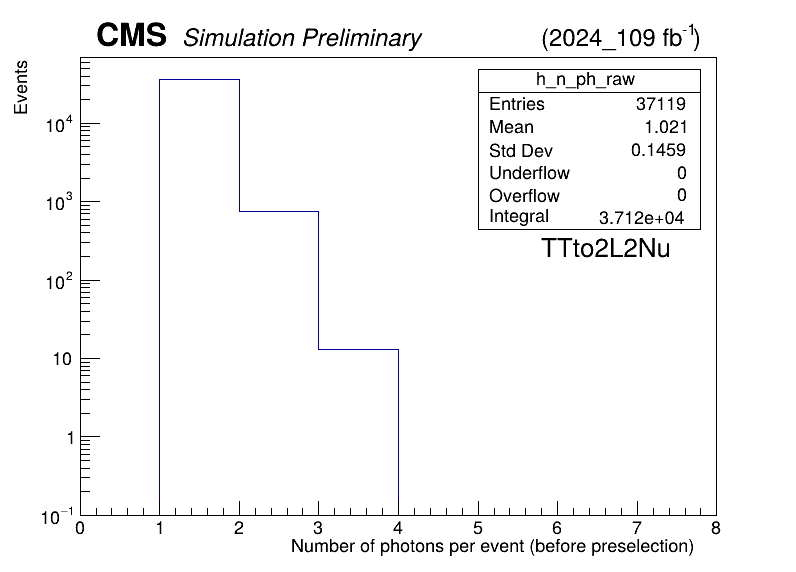

In [13]:
n_ph_raw = ak.to_numpy(ak.num(selected_photons[ak.num(selected_photons.pt)>0].pt))   # number of fj per event

# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_ph_raw",
    ";Number of photons per event (before preselection);Events",
    8, 0, 8
)

for v in n_ph_raw:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_ph_raw", "c_n_ph_raw", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_photons_per_event_raw_TTto2L2Nu.png")


Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xb

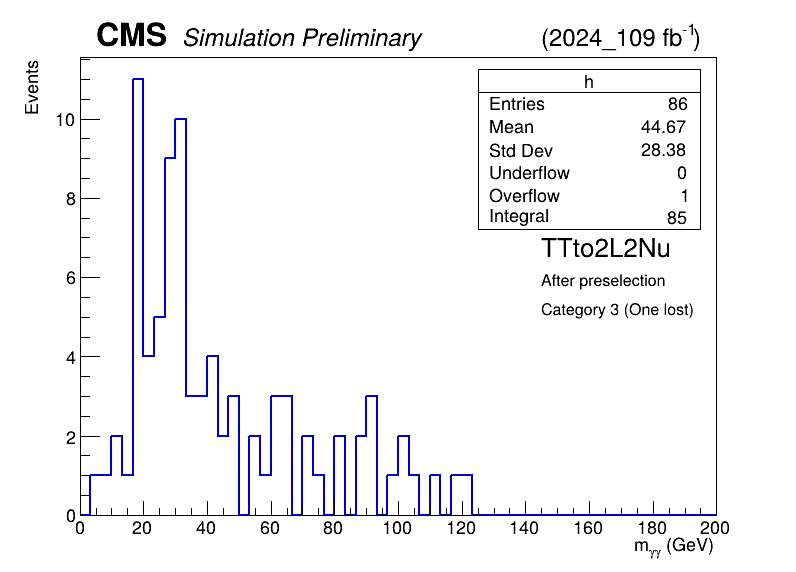

In [14]:
photons = selected_photons

sorted_photons = photons[ak.argsort(photons.pt, ascending=False)]

photons_padded = ak.pad_none(sorted_photons, 2)

lead_photon     = photons_padded[:, 0]
sublead_photon  = photons_padded[:, 1]

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";Photon p_{T} [GeV];Events", 50, 0, 200)
h_sub  = ROOT.TH1F("h_sub",  ";Photon p_{T} [GeV];Events", 50, 0, 200)

# Fill histograms
for pt in ak.drop_none(lead_photon.pt):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_photon.pt):
    h_sub.Fill(pt)


c = ROOT.TCanvas("c", "c", 700, 600)
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, f"Leading #gamma", "l")
leg.AddEntry(h_sub, f"Subleading #gamma", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "Before preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"photons_pt_lead_sublead_raw_TTto2L2Nu.png")


In [15]:
len(events)

820990

In [16]:
selected_photons.fields

['cutBased',
 'electronVeto',
 'hasConversionTracks',
 'isScEtaEB',
 'isScEtaEE',
 'mvaID_WP80',
 'mvaID_WP90',
 'pixelSeed',
 'seedGain',
 'electronIdx',
 'jetIdx',
 'seediEtaOriX',
 'seediPhiOriY',
 'vidNestedWPBitmap',
 'ecalPFClusterIso',
 'energyErr',
 'energyRaw',
 'esEffSigmaRR',
 'esEnergyOverRawE',
 'eta',
 'etaWidth',
 'haloTaggerMVAVal',
 'hcalPFClusterIso',
 'hoe',
 'hoe_PUcorr',
 'hoe_Tower',
 'mvaID',
 'pfChargedIso',
 'pfChargedIsoPFPV',
 'pfChargedIsoWorstVtx',
 'pfPhoIso03',
 'pfRelIso03_all_quadratic',
 'pfRelIso03_chg_quadratic',
 'phi',
 'phiWidth',
 'pt',
 'r9',
 's4',
 'sieie',
 'sieip',
 'sipip',
 'superclusterEta',
 'trkSumPtHollowConeDR03',
 'trkSumPtSolidConeDR04',
 'x_calo',
 'y_calo',
 'z_calo',
 'genPartFlav',
 'genPartIdx',
 'electronIdxG',
 'genPartIdxG',
 'jetIdxG']

In [17]:
selected_photons[event_mask].genPartFlav*1

<Array [[0, 1], [1, 1], ..., [1, ...], [1, 11]] type='208 * var * uint8[par...'>

In [18]:
selected_photons.pt

<Array [[], [], [], [], ..., [], [], [], [30]] type='820990 * var * float32...'>

In [ ]:
gen = events[ak.num(selected_photons.pt)>0].GenPart

pho_idx = selected_photons[ak.num(selected_photons.pt)>0].genPartIdx
gen_photons = gen[pho_idx]

mother = gen[gen_photons.genPartIdxMother]

mpdg = mother.pdgId

In [20]:
mpdg*1

<Array [[13], [111], [-24], ..., [5], [24]] type='37119 * var * int32[param...'>

In [21]:
from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat = ak.flatten(mpdg)
flat_np = np.array(flat)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco Photons;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "Before preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_photons_raw_TTto2L2Nu.png")



Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/genPart_photons_raw_TTto2L2Nu.png has been created


In [22]:
gen_presel = events[event_mask].GenPart

pho_idx = selected_photons[event_mask].genPartIdx
gen_photons = gen_presel[pho_idx]

mother = gen_presel[gen_photons.genPartIdxMother]

mpdg_presel = mother.pdgId


In [23]:
from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat = ak.flatten(mpdg_presel)
flat_np = np.array(flat)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco Photons;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_photons_presel_TTto2L2Nu.png")



Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/genPart_photons_presel_TTto2L2Nu.png has been created


Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/n_jets_per_event_raw_TTto2L2Nu.png has been created


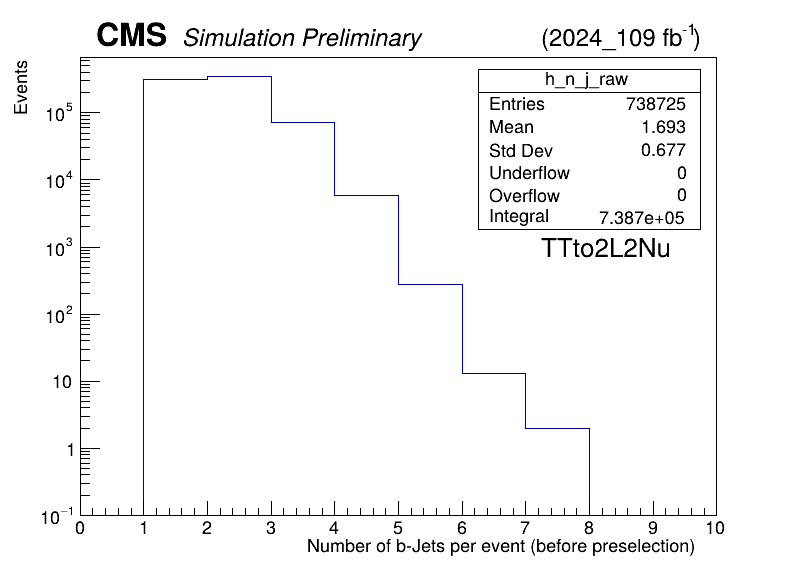

In [24]:
n_j_raw = ak.to_numpy(ak.num(selected_bjets[ak.num(selected_bjets.pt)>0].pt))   # number of fj per event

# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_j_raw",
    ";Number of b-Jets per event (before preselection);Events",
    10, 0, 10
)

for v in n_j_raw:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_j_raw", "c_n_j_raw", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_jets_per_event_raw_TTto2L2Nu.png")


In [25]:
jets = selected_bjets

sorted_jets = jets[ak.argsort(jets.pt, ascending=False)]

jets_padded = ak.pad_none(sorted_jets, 2)

lead_jet     = jets_padded[:, 0]
sublead_jet  = jets_padded[:, 1]

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";b-Jets p_{T} [GeV];Events", 100, 0, 500)
h_sub  = ROOT.TH1F("h_sub",  ";b-Jets p_{T} [GeV];Events", 100, 0, 500)

# Fill histograms
for pt in ak.drop_none(lead_jet.pt):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_jet.pt):
    h_sub.Fill(pt)

c = ROOT.TCanvas("c", "c", 700, 600)
# c.SetLogy()
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

merge_overflow(h_lead)
merge_overflow(h_sub)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

c.Update()

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, "Leading b-Jet", "l")
leg.AddEntry(h_sub, "Subleading b-Jet", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "Before preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"jets_pt_lead_sublead_raw_TTto2L2Nu.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_lead (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_sub (Potential memory leak).
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char

In [26]:
evt_mask, fp, fj, fl = event_mask, selected_photons[event_mask], selected_bjets[event_mask], selected_leptons[event_mask]

In [14]:
ak.sum(events.n_jets ==2)

54064

In [20]:
# n_ph_presel = ak.to_numpy(ak.num(fp[ak.num(fp.pt)>0].pt))   # number of fj per event


n_ph_presel = events.n_photons
# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_ph_presel",
    ";Number of photons per event (After preselection);Events",
    15, 0, 15
)

for v in n_ph_presel:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_ph_presel", "c_n_ph_presel", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")


latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.65, 0.45, f"At least 1 b-Jet")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_photons_per_event_presel_TTto2L2Nu.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_n_ph_presel (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_n_ph_presel
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/n_photons_per_event_presel_TTto2L2Nu.png has been created


Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/n_jets_per_event_presel_TTto2L2Nu.png has been created


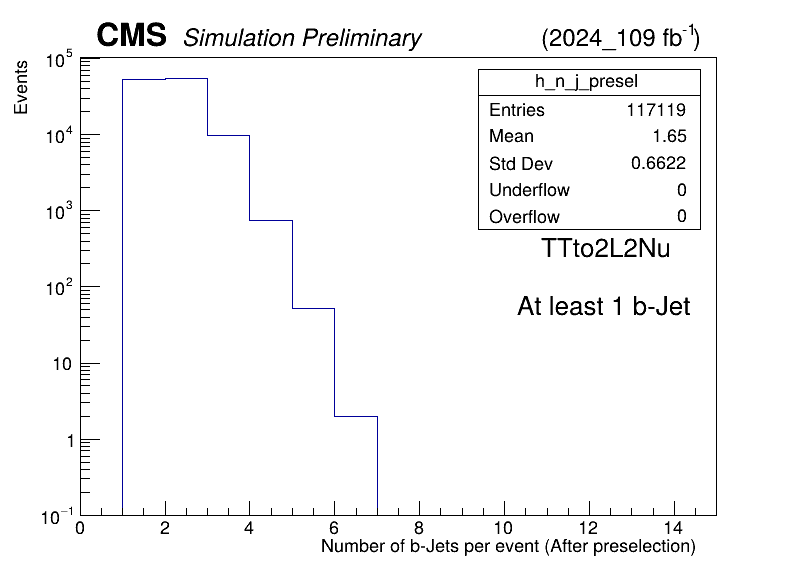

In [21]:
# n_j_presel = ak.to_numpy(ak.num(fj[ak.num(fj.pt)>0].pt))   # number of fj per event
n_j_presel = events.n_jets

# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_j_presel",
    ";Number of b-Jets per event (After preselection);Events",
    15, 0, 15
)

for v in n_j_presel:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_j_presel", "c_n_j_presel", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.65, 0.45, f"At least 1 b-Jet")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_jets_per_event_presel_TTto2L2Nu.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_lead (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_sub (Potential memory leak).
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char

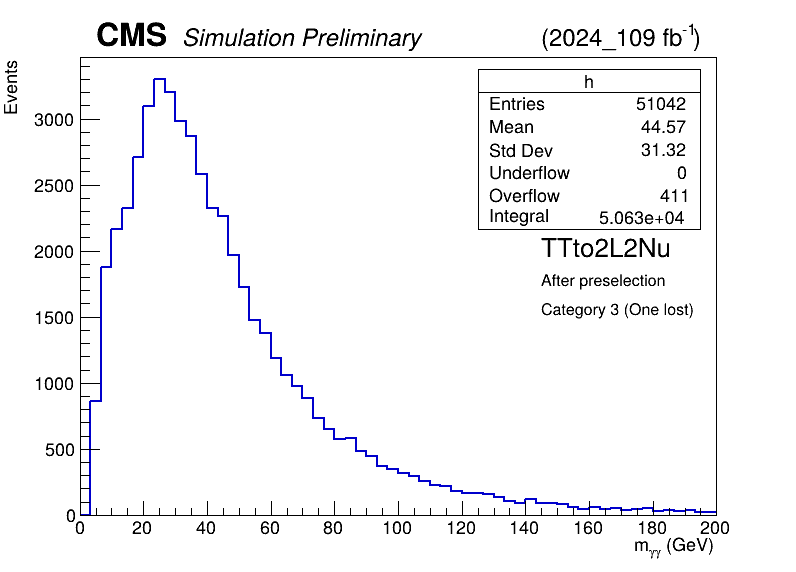

In [23]:
# sorted_photons_presel = fp[ak.argsort(fp.pt, ascending=False)]

# photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

# lead_photon_presel     = photons_padded_presel[:, 0]
# sublead_photon_presel  = photons_padded_presel[:, 1]

lead_photon_presel     = events.pholead_pt
sublead_photon_presel  = events.phosublead_pt

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";Photon p_{T} [GeV];Events", 50, 0, 200)
h_sub  = ROOT.TH1F("h_sub",  ";Photon p_{T} [GeV];Events", 50, 0, 200)

# Fill histograms
for pt in ak.drop_none(lead_photon_presel):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_photon_presel):
    h_sub.Fill(pt)


c = ROOT.TCanvas("c", "c", 700, 600)
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, f"Leading #gamma", "l")
leg.AddEntry(h_sub, f"Subleading #gamma", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "After preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"photons_pt_lead_sublead_presel_TTto2L2Nu.png")


In [28]:
# sorted_jets_presel = fj[ak.argsort(fj.pt, ascending=False)]

# jets_padded_presel = ak.pad_none(sorted_jets_presel, 2)

# lead_jet_presel     = jets_padded_presel[:, 0]
# sublead_jet_presel  = jets_padded_presel[:, 1]

lead_jet_presel     = events.first_jet_pt[(events.first_jet_pt)!=-999]
sublead_jet_presel  = events.second_jet_pt[(events.second_jet_pt)!=-999]

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";b-Jet p_{T} [GeV];Events", 100, 0, 500)
h_sub  = ROOT.TH1F("h_sub",  ";b-Jet p_{T} [GeV];Events", 100, 0, 500)

# Fill histograms
for pt in ak.drop_none(lead_jet_presel):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_jet_presel):
    h_sub.Fill(pt)

c = ROOT.TCanvas("c", "c", 700, 600)
# c.SetLogy()
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

merge_overflow(h_lead)
merge_overflow(h_sub)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

c.Update()

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, "Leading b-Jet", "l")
leg.AddEntry(h_sub, "Subleading b-Jet", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "After preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"jets_pt_lead_sublead_presel_TTto2L2Nu.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_lead (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_sub (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, ca

In [31]:
events.Jet.fields

['chMultiplicity',
 'nConstituents',
 'nElectrons',
 'nMuons',
 'nSVs',
 'neMultiplicity',
 'electronIdx1',
 'electronIdx2',
 'muonIdx1',
 'muonIdx2',
 'svIdx1',
 'svIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'PNetRegPtRawCorr',
 'PNetRegPtRawCorrNeutrino',
 'PNetRegPtRawRes',
 'UParTAK4RegPtRawCorr',
 'UParTAK4RegPtRawCorrNeutrino',
 'UParTAK4RegPtRawRes',
 'UParTAK4V1RegPtRawCorr',
 'UParTAK4V1RegPtRawCorrNeutrino',
 'UParTAK4V1RegPtRawRes',
 'area',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'btagPNetB',
 'btagPNetCvB',
 'btagPNetCvL',
 'btagPNetCvNotB',
 'btagPNetQvG',
 'btagPNetTauVJet',
 'btagUParTAK4B',
 'btagUParTAK4CvB',
 'btagUParTAK4CvL',
 'btagUParTAK4CvNotB',
 'btagUParTAK4Ele',
 'btagUParTAK4Mu',
 'btagUParTAK4QvG',
 'btagUParTAK4SvCB',
 'btagUParTAK4SvUDG',
 'btagUParTAK4TauVJet',
 'btagUParTAK4UDG',
 'btagUParTAK4probb',
 'btagUParTAK4probbb',
 'chEmEF',
 'chHEF',
 'eta',
 'hfEmEF',
 'hfHEF',
 'hfsigmaEtaEta',
 'hfsi

In [32]:
events.Jet.genJetIdx*1

<Array [[0, 1, 2, 3, 4, 8, -1, 5, 6], ...] type='820990 * var * int16[param...'>

In [33]:
gen = events[ak.num(selected_bjets.pt)>0].GenPart

bjet_idx = selected_bjets[ak.num(selected_bjets.pt)>0].genJetIdx
gen_bjets = gen[bjet_idx]

mother_bjets = gen[gen_bjets.genPartIdxMother]

mpdg_bjets = mother_bjets.pdgId


In [34]:
mpdg_bjets

<Array [[22, 21], [-11, ...], ..., [21, 21]] type='738725 * var * int32[par...'>

In [35]:
from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat = ak.flatten(mpdg_bjets)
flat_np = np.array(flat)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of b-Jets;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "Before preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_b-Jets_raw_TTto2L2Nu.png")



Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/genPart_b-Jets_raw_TTto2L2Nu.png has been created


In [36]:
gen = events[event_mask].GenPart

bjet_idx = selected_bjets[event_mask].genJetIdx
gen_bjets = gen[bjet_idx]

mother_bjets = gen[gen_bjets.genPartIdxMother]

mpdg_bjets_presel = mother_bjets.pdgId

In [37]:
from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat = ak.flatten(mpdg_bjets_presel)
flat_np = np.array(flat)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco b-Jets;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_b-Jets_presel_TTto2L2Nu.png")



Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/genPart_b-Jets_presel_TTto2L2Nu.png has been created


In [38]:
one_jet = fj[ak.num(fj.pt)>0]

In [31]:
events.first_jet_B

<Array [0.994, 0.817, 0.965, ..., 0.997, 0.683, 0.335] type='117119 * ?float64'>

In [32]:
events.second_jet_B

<Array [0.998, -999, -999, ..., -999, 0.997, 0.606] type='117119 * ?float64'>

In [33]:
# =========================
# Build histograms
# =========================
# vals = {
#     "btagUParTAK4B":      ak.flatten(one_jet.btagUParTAK4B),
#     "btagUParTAKprobb":   ak.flatten(one_jet.btagUParTAK4probb),
#     "btagUParTAKprobbb":  ak.flatten(one_jet.btagUParTAK4probbb),
# }

vals = {
    "btagUParTAK4B":      ak.concatenate([events.first_jet_B, events.second_jet_B[events.second_jet_B!=-999]]),
    "btagUParTAKprobb":   ak.concatenate([events.first_jet_probb, events.second_jet_probb[events.second_jet_probb!=-999]]),
    "btagUParTAKprobbb":  ak.concatenate([events.first_jet_probbb, events.second_jet_probbb[events.second_jet_probbb!=-999]]),
}

ROOT.gStyle.SetOptStat(111111)
ROOT.gStyle.SetStatFontSize(0.030)

hists = {}
colors = [ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2]

for (name, arr), col in zip(vals.items(), colors):
    h = ROOT.TH1F(name, name, 50, 0, 1)
    h.SetDirectory(0)                 # prevent ROOT ownership
    for x in ak.to_numpy(arr):
        h.Fill(x)
    h.SetLineColor(col)
    h.SetLineWidth(2)
    h.SetMinimum(0.1)
    hists[name] = h

# =========================
# Real canvas + overlay
# =========================
c = ROOT.TCanvas("c", "", 700, 600)
c.SetRightMargin(0.20)
c.SetLogy()

first = True
for h in hists.values():
    h.SetTitle("")
    h.GetXaxis().SetTitle("btagUParTAK4 tagger score")
    h.GetXaxis().SetTitleSize(0.045)
    h.GetXaxis().SetLabelSize(0.04)
    merge_overflow(h)

    if first:
        h.Draw("hist")
        first = False
    else:
        h.Draw("hist same")

draw_side_statboxes(c, [hists["btagUParTAK4B"], hists["btagUParTAKprobb"], hists["btagUParTAKprobbb"]])

# =========================
# Legend
# =========================
leg = ROOT.TLegend(0.35, 0.65, 0.68, 0.85)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
for name, h in hists.items():
    leg.AddEntry(h, name, "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.17, 0.85, f"After preselection")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.43, 0.60, f"TTto2L2Nu")

CMS_label(c)

# =========================
# Finalize
# =========================
c.Modified()
c.Update()
c.SaveAs(Plot_dir + f"btagger_score_after_presel_TTto2L2Nu.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error 

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/category_fractions_after_presel_TTto2L2Nu.png has been created


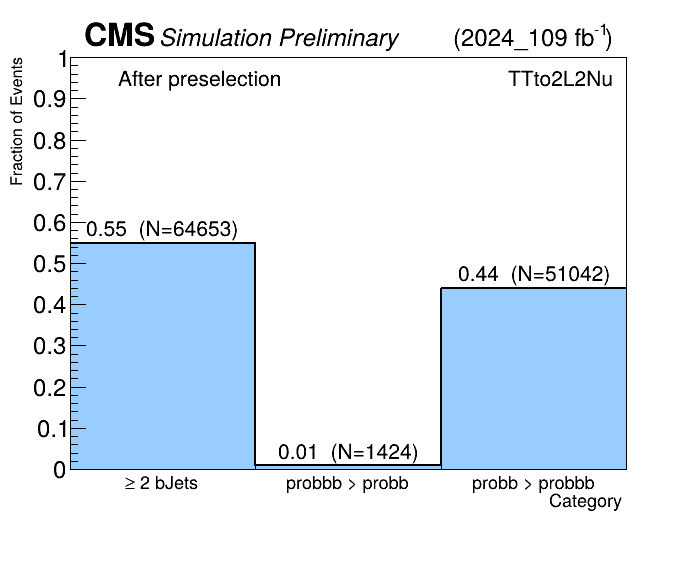

In [43]:
# n_bjets = ak.num(one_jet.pt)

cat1 = events.n_jets >= 2
cat2 = (events.n_jets == 1) & (events.first_jet_probbb > events.first_jet_probb)
cat3 = (events.n_jets == 1) & (events.first_jet_probb > events.first_jet_probbb)

n_total = len(events.n_jets)   # or int(ak.sum(n_jets >= 1)) if already filtered
n_cat1 = int(ak.sum(cat1))
n_cat2 = int(ak.sum(cat2))
n_cat3 = int(ak.sum(cat3))

f_cat1 = round(n_cat1 / n_total,2)
f_cat2 = round(n_cat2 / n_total,2)
f_cat3 = round(n_cat3 / n_total,2)

# --------------------------------
# Create histogram
# --------------------------------
h_frac = ROOT.TH1F(
    "h_frac",
    ";Category;Fraction of Events",
    3, 0, 3
)

h_frac.SetBinContent(1, f_cat1)
h_frac.SetBinContent(2, f_cat2)
h_frac.SetBinContent(3, f_cat3)

# Bin labels
h_frac.GetXaxis().SetBinLabel(1, "#geq 2 bJets")
h_frac.GetXaxis().SetBinLabel(2, "probbb > probb")
h_frac.GetXaxis().SetBinLabel(3, "probb > probbb")

# Style
h_frac.SetFillColor(ROOT.kAzure-9)
h_frac.SetLineColor(ROOT.kBlack)
h_frac.SetLineWidth(2)

h_frac.GetXaxis().SetLabelSize(0.05)
h_frac.GetYaxis().SetLabelSize(0.045)
h_frac.GetYaxis().SetTitleSize(0.03)
# h_frac.GetYaxis().SetTitleOffset(1.3)

h_frac.SetMaximum(1.0)   # fractions go up to 1

# --------------------------------
# Draw
# --------------------------------
c = ROOT.TCanvas("c_frac", "c_frac", 700, 600)
c.SetBottomMargin(0.18)
c.SetLeftMargin(1.3)

h_frac.SetMarkerSize(2.0);
# h_frac.Draw("HIST TEXT0")
h_frac.Draw("HIST")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.17, 0.85, f"After preselection")

latex = ROOT.TLatex()
latex.SetTextAlign(22)   # center
latex.SetTextSize(0.04)
latex.SetTextFont(42)

# Bin centers
for i, (frac, n) in enumerate(
    [(f_cat1, n_cat1), (f_cat2, n_cat2), (f_cat3, n_cat3)],
    start=1
):
    x = h_frac.GetBinCenter(i)
    y = frac + 0.03   # small vertical offset

    text = f"{frac:.2f}  (N={n})"
    latex.DrawLatex(x, y, text)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.73, 0.85, f"TTto2L2Nu")


c.Update()
c.SaveAs(Plot_dir+f"category_fractions_after_presel_TTto2L2Nu.png")

In [45]:
# valid_mask = (
#     ~ak.is_none(lead_photon_presel.pt) &
#     ~ak.is_none(sublead_photon_presel.pt)
# )

# lead_valid = lead_photon_presel[valid_mask]
# sublead_valid  = sublead_photon_presel[valid_mask]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": events.pholead_pt,
        "eta": events.pholead_eta,
        "phi": events.pholead_phi,
        "mass": ak.zeros_like(events.pholead_pt),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": events.phosublead_pt,
        "eta": events.phosublead_eta,
        "phi": events.phosublead_phi,
        "mass": ak.zeros_like(events.phosublead_pt),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Inclusive category")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_TTto2L2Nu.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/m_gg_presel_TTto2L2Nu.png has been created


In [43]:
one_photon = fp[ak.num(fp.pt)>0]
cat1_ph = one_photon[cat1]
cat2_ph = one_photon[cat2]
cat3_ph = one_photon[cat3]

In [46]:
# sorted_photons_presel = cat1_ph[ak.argsort(cat1_ph.pt, ascending=False)]

# photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

# lead_photon_presel     = photons_padded_presel[:, 0]
# sublead_photon_presel  = photons_padded_presel[:, 1]

# valid_mask = (
#     ~ak.is_none(lead_photon_presel.pt) &
#     ~ak.is_none(sublead_photon_presel.pt)
# )

# lead_valid = lead_photon_presel[valid_mask]
# sublead_valid  = sublead_photon_presel[valid_mask]

# lead_valid = events.pholead_pt[cat1]
# sublead_valid = events.phosublead_pt[cat1]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": events.pholead_pt[cat1],
        "eta": events.pholead_eta[cat1],
        "phi": events.pholead_phi[cat1],
        "mass": ak.zeros_like(events.pholead_pt[cat1]),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": events.phosublead_pt[cat1],
        "eta": events.phosublead_eta[cat1],
        "phi": events.phosublead_phi[cat1],
        "mass": ak.zeros_like(events.phosublead_pt[cat1]),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Category 1 (Resolved)")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_cat1_TTto2L2Nu.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/m_gg_presel_cat1_TTto2L2Nu.png has been created


In [47]:
# sorted_photons_presel = cat2_ph[ak.argsort(cat2_ph.pt, ascending=False)]

# photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

# lead_photon_presel     = photons_padded_presel[:, 0]
# sublead_photon_presel  = photons_padded_presel[:, 1]

# valid_mask = (
#     ~ak.is_none(lead_photon_presel.pt) &
#     ~ak.is_none(sublead_photon_presel.pt)
# )

# lead_valid = lead_photon_presel[valid_mask]
# sublead_valid  = sublead_photon_presel[valid_mask]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": events.pholead_pt[cat2],
        "eta": events.pholead_eta[cat2],
        "phi": events.pholead_phi[cat2],
        "mass": ak.zeros_like(events.pholead_pt[cat2]),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": events.phosublead_pt[cat2],
        "eta": events.phosublead_eta[cat2],
        "phi": events.phosublead_phi[cat2],
        "mass": ak.zeros_like(events.phosublead_pt[cat2]),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Category 2 (Merged)")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_cat2_TTto2L2Nu.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/m_gg_presel_cat2_TTto2L2Nu.png has been created


In [48]:
# sorted_photons_presel = cat3_ph[ak.argsort(cat3_ph.pt, ascending=False)]

# photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

# lead_photon_presel     = photons_padded_presel[:, 0]
# sublead_photon_presel  = photons_padded_presel[:, 1]

# valid_mask = (
#     ~ak.is_none(lead_photon_presel.pt) &
#     ~ak.is_none(sublead_photon_presel.pt)
# )

# lead_valid = lead_photon_presel[valid_mask]
# sublead_valid  = sublead_photon_presel[valid_mask]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": events.pholead_pt[cat3],
        "eta": events.pholead_eta[cat3],
        "phi": events.pholead_phi[cat3],
        "mass": ak.zeros_like(events.pholead_pt[cat3]),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": events.phosublead_pt[cat3],
        "eta": events.phosublead_eta[cat3],
        "phi": events.phosublead_phi[cat3],
        "mass": ak.zeros_like(events.phosublead_pt[cat3]),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTto2L2Nu")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Category 3 (One lost)")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_cat3_TTto2L2Nu.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/m_gg_presel_cat3_TTto2L2Nu.png has been created


In [52]:
events.GenJet.fields

['eta',
 'mass',
 'phi',
 'pt',
 'hadronFlavour',
 'nBHadrons',
 'nCHadrons',
 'partonFlavour']

In [56]:
events.GenJet.partonFlavour*1

<Array [[5, 21, 21, -5, ..., 21, 0, 0], ...] type='820990 * var * int16[par...'>

In [13]:
events.Photon.pt*1

<Array [[103, 35.6, 17.4, 14.3], ..., [...]] type='27088 * var * float32[pa...'>

In [14]:
selected_photons, selected_bjets, selected_leptons, selected_electrons, selected_muons = object_preselections(
    events.Photon,
    events.Jet,
    events.Electron,
    events.Muon,
    year="2024"
)

one_ele = ak.num(selected_electrons) == 1
one_mu = ak.num(selected_muons) == 1
lepton_channel_mask = one_ele | one_mu
at_least_one_b = ak.num(selected_bjets) >= 1
at_least_two_pho = ak.num(selected_photons) >= 2
dr = delta_r_manual(selected_leptons, selected_photons)
dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

event_mask = lepton_channel_mask & at_least_one_b & at_least_two_pho & dr_mask


In [16]:
selected_photons[event_mask].pt

<Array [[17.4, 14.3], [...], ..., [10.3, 10.2]] type='22198 * var * float32...'>

In [19]:
ak.where(ak.num(selected_photons[event_mask].pt)==3)

(<Array [97, 214, 254, 698, ..., 21918, 22012, 22172, 22179] type='162 * int64'>,)

In [22]:
gen = events[event_mask].GenPart

In [23]:
gen.fields

['genPartIdxMother',
 'statusFlags',
 'pdgId',
 'status',
 'eta',
 'mass',
 'phi',
 'pt',
 'iso',
 'genPartIdxMotherG',
 'distinctParentIdxG',
 'childrenIdxG',
 'distinctChildrenIdxG',
 'distinctChildrenDeepIdxG']

In [11]:
selected_photons[event_mask].pt

<Array [[14.5, 11.7], [...], ..., [48.4, 18.8]] type='60955 * var * float32...'>

In [10]:
gen = events[event_mask].GenPart

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/genPart_selected_phos_TTto2L2Nu.png has been created


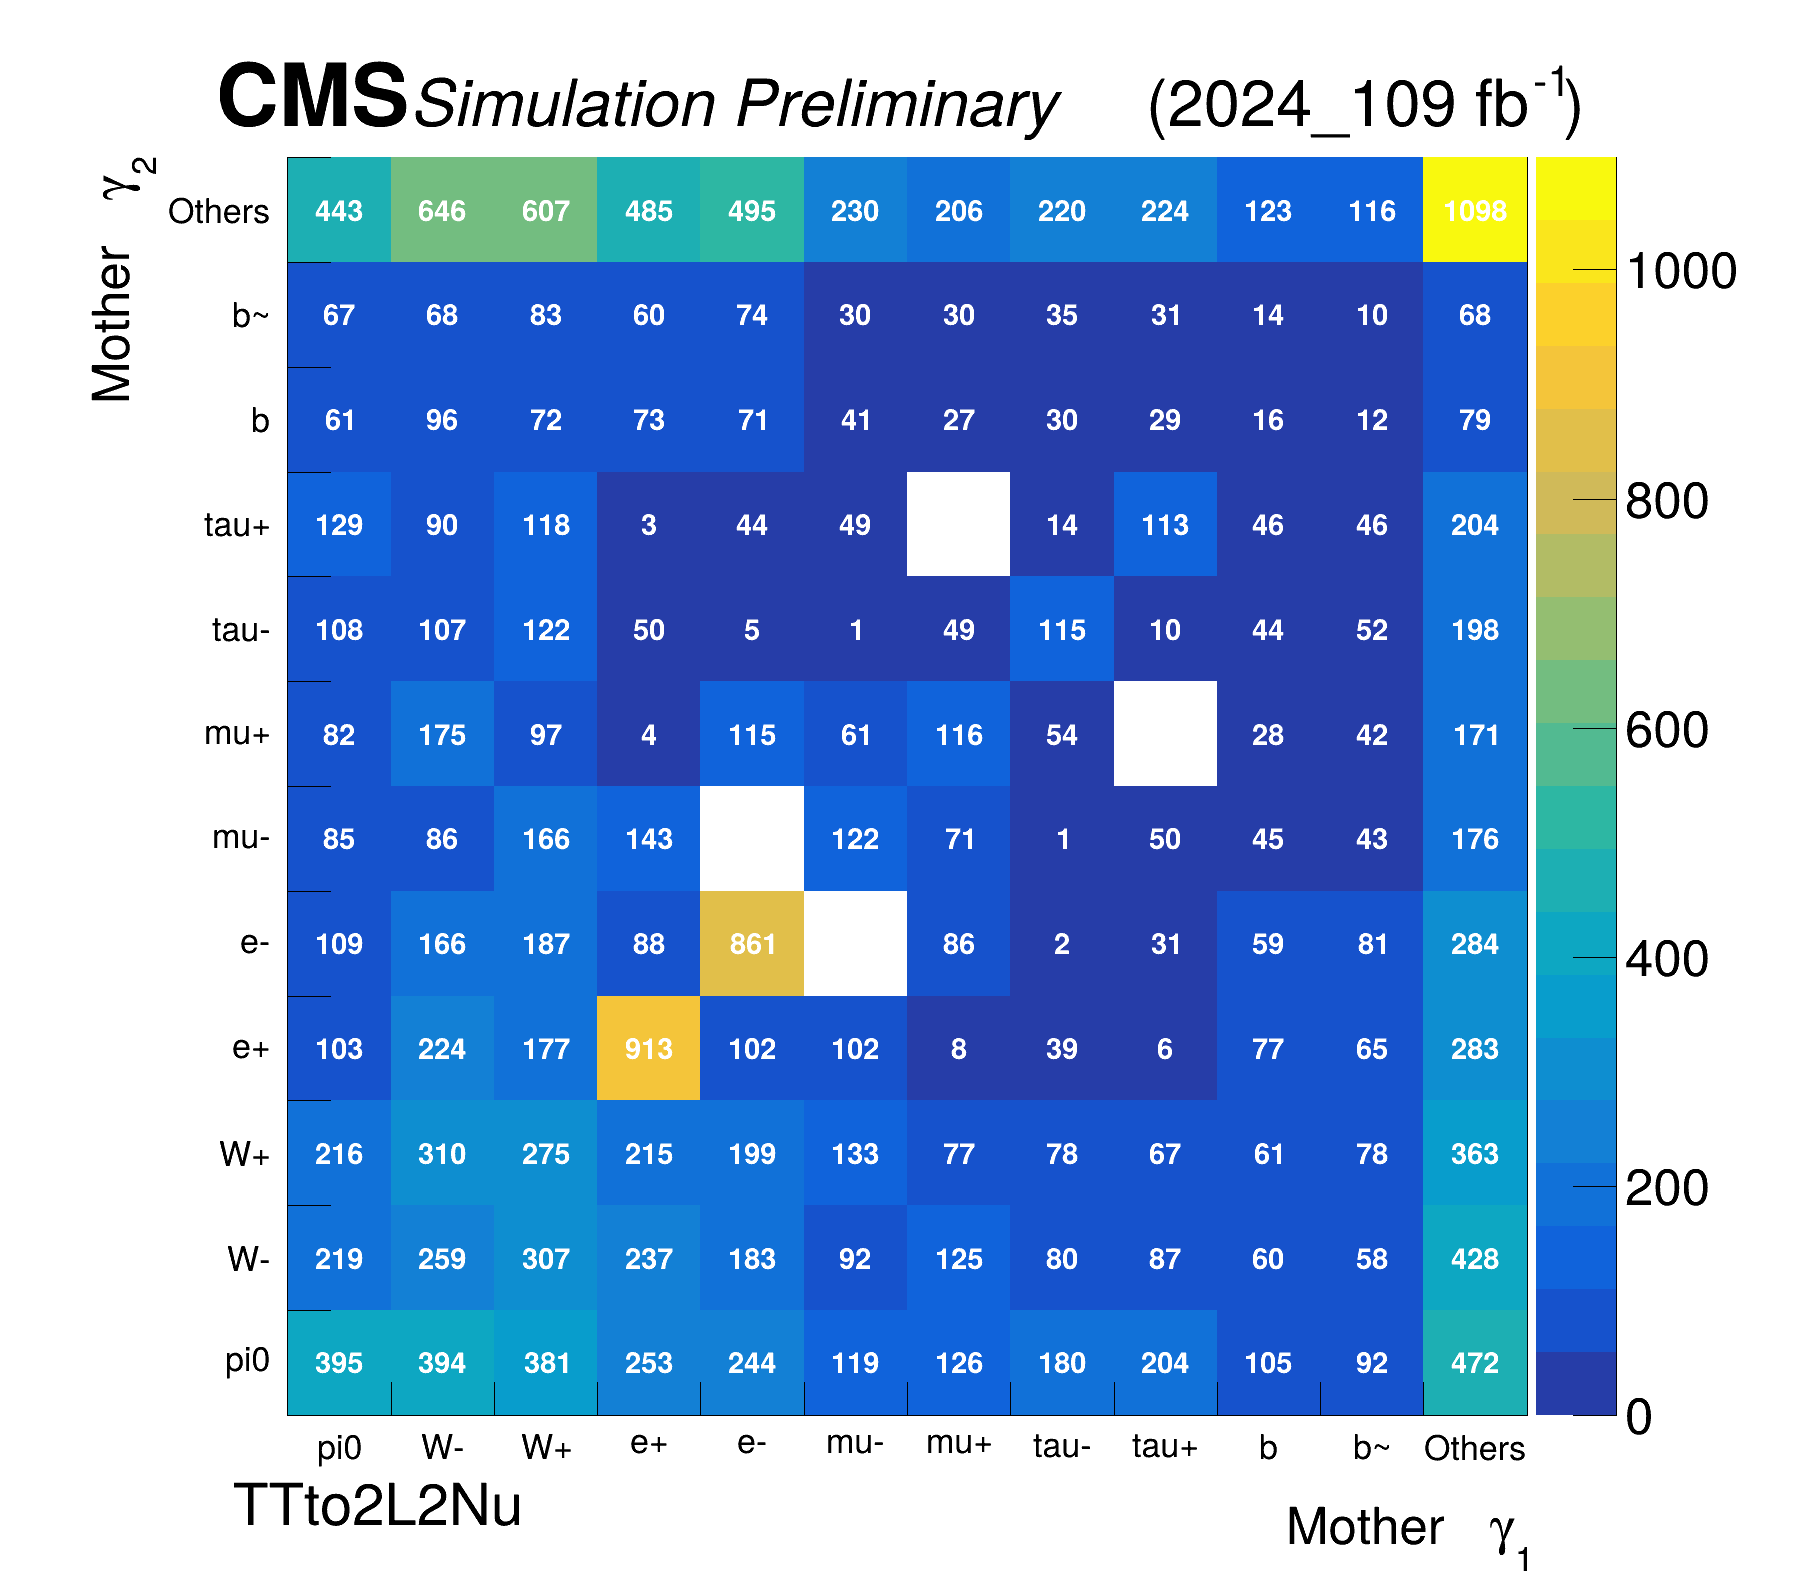

In [11]:
selected_photons = selected_photons[event_mask]

selected_photons = selected_photons[ak.argsort(selected_photons.pt, ascending=False)]

mother_pdg = gen[gen[selected_photons.genPartIdx].genPartIdxMother].pdgId

mother_ids = ak.flatten(mother_pdg)

from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat_np = np.array(mother_ids)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco Photons;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_selected_phos_TTto2L2Nu.png")



In [14]:
ak.sum(ak.num(mother_pdg)==3)

113

In [15]:
p1 = mother_pdg[:,0]
p2   = mother_pdg[:,1]

In [16]:
from particle import Particle

# Convert to numpy
p1 = ak.to_numpy(p1)
p2 = ak.to_numpy(p2)

# --- determine particle contributions ---
all_pdgs = np.concatenate([p1, p2])

unique_pdgs, pdg_counts = np.unique(all_pdgs, return_counts=True)

fractions = pdg_counts / pdg_counts.sum()

threshold = 0.02

major_pdgs = unique_pdgs[fractions >= threshold]
major_counts = pdg_counts[fractions >= threshold]

# sort by contribution (largest first)
order = np.argsort(-major_counts)
major_pdgs = major_pdgs[order]

pdgs = list(major_pdgs)

# --- define histogram size ---
others_bin = len(pdgs) + 1
n = len(pdgs) + 1

# delete existing histogram if ROOT already has one
if ROOT.gROOT.FindObject("h2D"):
    ROOT.gROOT.FindObject("h2D").Delete()

h2D = ROOT.TH2F(
    "h2D",
    ";Mother #gamma_{1};Mother #gamma_{2}",
    n, 0, n,
    n, 0, n
)

# --- map pdg -> bin ---
pdg_to_bin = {pdg: i+1 for i, pdg in enumerate(pdgs)}

# --- fill histogram ---
for d, m in zip(p1, p2):

    x = pdg_to_bin.get(d, others_bin)
    y = pdg_to_bin.get(m, others_bin)

    h2D.Fill(x-0.5, y-0.5)

# --- pdg -> particle name ---
def name(pdg):
    try:
        return Particle.from_pdgid(int(pdg)).name
    except:
        return str(pdg)

# --- set axis labels ---
for i, pdg in enumerate(pdgs):

    label = name(pdg)

    h2D.GetXaxis().SetBinLabel(i+1, label)
    h2D.GetYaxis().SetBinLabel(i+1, label)

h2D.GetXaxis().SetBinLabel(n, "Others")
h2D.GetYaxis().SetBinLabel(n, "Others")

# --- plotting ---
c = ROOT.TCanvas("c","c",1800, 1600)

ROOT.gStyle.SetOptStat(0)

h2D.Draw("COLZ TEXT")
h2D.SetMarkerColor(ROOT.kWhite)
h2D.GetXaxis().SetTitleOffset(1.4)

c.SetRightMargin(0.15)
c.SetLeftMargin(0.16)
c.SetBottomMargin(0.10)

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.03, "TTto2L2Nu")

# latex.DrawLatex(0.13, 0.75, "After preselection")

c.SaveAs(Plot_dir+"p1_p2_2D_photons_TTto2L2Nu.png")
c.SaveAs(Plot_dir+"p1_p2_2D_photons_TTto2L2Nu.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/p1_p2_2D_photons_TTto2L2Nu.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/p1_p2_2D_photons_TTto2L2Nu.pdf has been created


In [17]:
all_pdgs

array([111, -13, -24, ...,  24, 511, 111], dtype=int32)

In [17]:
selected_electrons[event_mask].pt

<Array [[52], [45.1], ..., [47.7], [40.2]] type='60955 * var * float32[para...'>

In [18]:
gen_electrons = gen[(abs(gen.pdgId) == 11) & ((gen.statusFlags & 1) == 1)]

In [19]:
gen_electrons.pt*1

<Array [[50.9], [46.1, ..., 10.6], ..., [41.2]] type='60955 * var * float32...'>

In [20]:
ak.num(gen_electrons.pt)

<Array [1, 3, 4, 1, 1, 0, 2, 0, ..., 0, 3, 2, 0, 3, 3, 1] type='60955 * int64'>

In [21]:
ak.sum(ak.num(gen_electrons.pt) ==1)

12830

In [22]:
gen_electrons.pdgId

<Array [[11], [-11, 11, 11], ..., [...], [11]] type='60955 * var * int32[pa...'>

In [26]:
gen[gen_electrons.genPartIdxMother].pdgId

<Array [[-24], [24, -24, 11], ..., [-24]] type='60955 * var * int32[paramet...'>

In [20]:
gen[selected_photons.genPartIdx].pdgId

<Array [[22, 22], [22, 11], ..., [22, 22]] type='60955 * var * int32[parame...'>

In [14]:
gen_pho = gen[selected_photons.genPartIdx]

In [23]:
ak.sum(ak.num(gen_pho[abs(gen[selected_photons.genPartIdx].pdgId == 11)].pt) > 0)

12857

In [27]:
ak.sum(ak.num(gen_pho[abs(gen[selected_photons.genPartIdx].pdgId == 11)].pt) >1)

229

In [15]:
dR_ele_pho_lead = delta_r_manual(gen[(abs(gen.pdgId) == 11)&(gen.status == 1)&(gen.pt > 10)], selected_photons[:,0])
dR_ele_pho_sub = delta_r_manual(gen[(abs(gen.pdgId) == 11)&(gen.status == 1)&(gen.pt > 10)], selected_photons[:,1])
dR_ele_pho_lead_min = ak.min(dR_ele_pho_lead, axis=1)
dR_ele_pho_sub_min = ak.min(dR_ele_pho_sub, axis=1)

In [94]:
def make_hist1d(
    array,
    name="hist",
    title="Histogram",
    nbins=50,
    xmin=0,
    xmax=100,
    xlabel="x",
    ylabel="Events",
    outfile="hist.root",
    imgfile="hist.png",
    Process = "TTto2L2Nu",
    save_root=False,
    logy=False, 
    Normalized=False,
    stage = "After preselection"
):

    ROOT.gStyle.SetOptStat(1111111)

    # flatten awkward arrays if needed
    if isinstance(array, ak.Array):
        array = ak.to_numpy(ak.flatten(array))
    else:
        array = np.array(array)

    # histogram
    h = ROOT.TH1F(name, f";{xlabel};{ylabel}", nbins, xmin, xmax)

    for v in array:
        h.Fill(v)

    if Normalized:
        h.Scale(1.0 / h.Integral())

    # canvas
    c = ROOT.TCanvas("c","",800,600)
    if logy:
        c.SetLogy()

    h.SetLineWidth(2)
    h.Draw("hist")
    CMS_label(c)

    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.04)
    latex.SetTextFont(42)
    latex.DrawLatex(0.63, 0.8, Process)

    latex = ROOT.TLatex()
    latex.SetNDC()              # normalized (0–1) coords
    latex.SetTextSize(0.04)
    latex.SetTextFont(42)
    latex.DrawLatex(0.58, 0.70, "After preselection")

    c.Update()
    draw_side_statboxes(c, [h])
    c.Update()

    # save image
    c.SaveAs(Plot_dir+imgfile)

    if save_root:
        # save ROOT file
        f = ROOT.TFile(Plot_dir+outfile,"RECREATE")
        h.Write()
        c.Write()
        f.Close()

    return h

In [95]:
def plot_overlay(
        var1,
        var2,
        label1="Sample 1",
        label2="Sample 2",
        xlabel="Variable",
        nbins=100,
        xmin=0,
        xmax=100,
        logy=True,
        normalize=True,
        dataset_label="",
        extra_label="",
        output_name="plot",
        plot_dir="./"
    ):

    ROOT.gStyle.SetOptStat(1111111)

    # Histograms
    h1 = ROOT.TH1F("h1",";{};Events".format(xlabel),nbins,xmin,xmax)
    h2 = ROOT.TH1F("h2",";{};Events".format(xlabel),nbins,xmin,xmax)

    # Fill
    for v in np.array(ak.flatten(var1)):
        h1.Fill(v)

    for v in np.array(ak.flatten(var2)):
        h2.Fill(v)

    # Normalize
    if normalize:
        if h1.Integral()>0:
            h1.Scale(1.0/h1.Integral())
        if h2.Integral()>0:
            h2.Scale(1.0/h2.Integral())

    # Style
    h1.SetLineColor(ROOT.kRed)
    h1.SetLineWidth(2)

    h2.SetLineColor(ROOT.kBlue)
    h2.SetLineWidth(2)

    h1.SetMaximum(1.2*max(h1.GetMaximum(),h2.GetMaximum()))

    # Canvas
    c = ROOT.TCanvas("c","",800,600)

    if logy:
        c.SetLogy()

    h1.Draw("hist")
    h2.Draw("hist same")

    # Legend
    leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
    leg.AddEntry(h1,label1,"l")
    leg.AddEntry(h2,label2,"l")
    leg.Draw()

    # CMS label
    CMS_label(c)

    # Dataset text
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.04)
    latex.SetTextFont(42)

    if dataset_label:
        latex.DrawLatex(0.13,0.83,dataset_label)

    if extra_label:
        latex.DrawLatex(0.55,0.70,extra_label)

    c.Update()

    draw_side_statboxes(c,[h1,h2])

    c.Update()

    # Save
    c.SaveAs(plot_dir + output_name + ".png")

    f = ROOT.TFile(plot_dir + output_name + ".root","RECREATE")
    c.Write()
    f.Close()

In [30]:
make_hist1d(
    dR_ele_pho_lead_min,
    name="dR_ele_pho_lead_min",
    title="Minimum Delta R between Electrons and Leading Photons",
    nbins=50,
    xmin=0,
    xmax=10.0,
    xlabel="min #DeltaR(e, #gamma_{lead})",
    ylabel="Events",
    imgfile="dR_ele_pho_lead_min.png",
    Process = "TTto2L2Nu",
    save_root=True,
    logy=True
)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error 

In [31]:
make_hist1d(
    dR_ele_pho_sub_min,
    name="dR_ele_pho_sub_min",
    title="Minimum Delta R between Electrons and Sub-leading Photons",
    nbins=50,
    xmin=0,
    xmax=10.0,
    xlabel="min #DeltaR(e, #gamma_{sub-lead})",
    ylabel="Events",
    imgfile="dR_ele_pho_sub_min.png",
    Process = "TTto2L2Nu",
    save_root=True,
    logy=True
)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error 

In [32]:
dR_mu_pho_lead = delta_r_manual(gen[(abs(gen.pdgId) == 13)&(gen.status == 1)&(gen.pt > 10)], selected_photons[:,0])
dR_mu_pho_sub = delta_r_manual(gen[(abs(gen.pdgId) == 13)&(gen.status == 1)&(gen.pt > 10)], selected_photons[:,1])
dR_mu_pho_lead_min = ak.min(dR_mu_pho_lead, axis=1)
dR_mu_pho_sub_min = ak.min(dR_mu_pho_sub, axis=1)

In [33]:
make_hist1d(
    dR_mu_pho_lead_min,
    name="dR_mu_pho_lead_min",
    title="Minimum Delta R between Muons and Leading Photons",
    nbins=50,
    xmin=0,
    xmax=10.0,
    xlabel="min #DeltaR(#mu, #gamma_{lead})",
    ylabel="Events",
    imgfile="dR_mu_pho_lead_min.png",
    Process = "TTto2L2Nu",
    save_root=True,
    logy=True
)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error 

In [34]:
make_hist1d(
    dR_mu_pho_sub_min,
    name="dR_mu_pho_sub_min",
    title="Minimum Delta R between Muons and sub-Leading Photons",
    nbins=50,
    xmin=0,
    xmax=10.0,
    xlabel="min #DeltaR(#mu, #gamma_{sub-lead})",
    ylabel="Events",
    imgfile="dR_mu_pho_sub_min.png",
    Process = "TTto2L2Nu",
    save_root=True,
    logy=True
)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error 

In [35]:
dR_ele_fake_ele_pho = delta_r_manual(gen[(abs(gen.pdgId) == 11)&(gen.status == 1)&(gen.pt > 10)], selected_photons[gen[selected_photons.genPartIdx].pdgId == 11])
dR_ele_fake_ele_pho_min = ak.min(dR_ele_fake_ele_pho, axis=1)

In [36]:
make_hist1d(
    dR_ele_fake_ele_pho_min,
    name="dR_ele_fake_ele_pho_min",
    title="Minimum Delta R between Electrons and Electrons faking as Photons",
    nbins=50,
    xmin=0,
    xmax=10.0,
    xlabel="min #DeltaR(e, #gamma_{fake-ele})",
    ylabel="Events",
    imgfile="dR_ele_fake_ele_pho_min.png",
    Process = "TTto2L2Nu",
    save_root=True,
    logy=True
)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error 

In [218]:
flattened_phos = ak.flatten(selected_photons)
pi0_pho = flattened_phos[abs(ak.flatten(mother_pdg)) == 111]
jet_fake_pho = flattened_phos[(abs(ak.flatten(mother_pdg)) != 22) & (abs(ak.flatten(mother_pdg)) != 11) & (abs(ak.flatten(mother_pdg)) != 13) & (abs(ak.flatten(mother_pdg)) != 111)]
true_pho = flattened_phos[abs(ak.flatten(mother_pdg)) == 22]

In [182]:
jet_fake_pho.pfPhoIso03

<Array [0, 0.537, 4.43, 0.623, ..., 3.3, 0, 0] type='70101 * float32[parame...'>

In [220]:
# pi0_pho and true_pho should be your 1D arrays (numpy/awkward flattened)


ROOT.gStyle.SetOptStat(1111111)

nbins, xmin, xmax = 50, 0, 0.6

h_pi0  = ROOT.TH1F("h_pi0",  ";H/E;Normalized Events", nbins, xmin, xmax)
h_jet_fake = ROOT.TH1F("h_jet_fake", ";H/E;Normalized Events", nbins, xmin, xmax)

for v in np.array(pi0_pho.hoe):
    h_pi0.Fill(v)

for v in np.array(jet_fake_pho.hoe):
    h_jet_fake.Fill(v)

# Normalize for shape comparison
if h_pi0.Integral() > 0:
    h_pi0.Scale(1.0 / h_pi0.Integral())
if h_jet_fake.Integral() > 0:
    h_jet_fake.Scale(1.0 / h_jet_fake.Integral())

# Style
h_pi0.SetLineColor(ROOT.kRed)
h_pi0.SetLineWidth(2)

h_jet_fake.SetLineColor(ROOT.kBlue)
h_jet_fake.SetLineWidth(2)

h_pi0.SetMaximum(1.2 * max(h_pi0.GetMaximum(), h_jet_fake.GetMaximum()))

# Canvas
c = ROOT.TCanvas("c","",800,600)
c.SetLogy()

h_pi0.Draw("hist")
h_jet_fake.Draw("hist same")

leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
leg.AddEntry(h_pi0, "#pi^{0} photons", "l")
leg.AddEntry(h_jet_fake, "Jet_fake photons", "l")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.Update()
draw_side_statboxes(c, [h_pi0, h_jet_fake])
c.Update()

c.SaveAs(Plot_dir + "hoe_overlay_normalized.png")


f = ROOT.TFile(Plot_dir + "hoe_overlay_normalized.root","RECREATE")
c.Write()
f.Close()

Warning in <TROOT::Append>: Replacing existing TH1: h_pi0 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_jet_fake (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000

In [169]:
# pi0_pho and true_pho should be your 1D arrays (numpy/awkward flattened)


ROOT.gStyle.SetOptStat(1111111)

nbins, xmin, xmax = 50, 0, 2.0

h_pi0  = ROOT.TH1F("h_pi0",  ";R_{9};Events", nbins, xmin, xmax)
h_jet_fake = ROOT.TH1F("h_jet_fake", ";R_{9};Events", nbins, xmin, xmax)

for v in np.array(pi0_pho.r9):
    h_pi0.Fill(v)

for v in np.array(jet_fake_pho.r9):
    h_jet_fake.Fill(v)

# Normalize for shape comparison
# if h_pi0.Integral() > 0:
#     h_pi0.Scale(1.0 / h_pi0.Integral())
# if h_jet_fake.Integral() > 0:
#     h_jet_fake.Scale(1.0 / h_jet_fake.Integral())

# Style
h_pi0.SetLineColor(ROOT.kRed)
h_pi0.SetLineWidth(2)

h_jet_fake.SetLineColor(ROOT.kBlue)
h_jet_fake.SetLineWidth(2)

h_pi0.SetMaximum(1.2 * max(h_pi0.GetMaximum(), h_jet_fake.GetMaximum()))

# Canvas
c = ROOT.TCanvas("c","",800,600)
c.SetLogy()

h_pi0.Draw("hist")
h_jet_fake.Draw("hist same")

leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
leg.AddEntry(h_pi0, "#pi^{0} photons", "l")
leg.AddEntry(h_jet_fake, "Jet-fake photons", "l")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")


latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.Update()
draw_side_statboxes(c, [h_pi0, h_jet_fake])
c.Update()

c.SaveAs(Plot_dir + "R9_overlay.png")


f = ROOT.TFile(Plot_dir + "R9_overlay.root","RECREATE")
c.Write()
f.Close()

Warning in <TROOT::Append>: Replacing existing TH1: h_pi0 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_jet_fake (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000

In [187]:
# pi0_pho and true_pho should be your 1D arrays (numpy/awkward flattened)


ROOT.gStyle.SetOptStat(1111111)

nbins, xmin, xmax = 50, 0, 10.0

h_pi0  = ROOT.TH1F("h_pi0",  ";pfPhoIso03;Normalized Events", nbins, xmin, xmax)
h_jet_fake = ROOT.TH1F("h_jet_fake", ";pfPhoIso03;Normalized Events", nbins, xmin, xmax)

for v in np.array(pi0_pho.pfPhoIso03):
    h_pi0.Fill(v)

for v in np.array(jet_fake_pho.pfPhoIso03):
    h_jet_fake.Fill(v)

# Normalize for shape comparison
if h_pi0.Integral() > 0:
    h_pi0.Scale(1.0 / h_pi0.Integral())
if h_jet_fake.Integral() > 0:
    h_jet_fake.Scale(1.0 / h_jet_fake.Integral())

# Style
h_pi0.SetLineColor(ROOT.kRed)
h_pi0.SetLineWidth(2)

h_jet_fake.SetLineColor(ROOT.kBlue)
h_jet_fake.SetLineWidth(2)

h_pi0.SetMaximum(1.2 * max(h_pi0.GetMaximum(), h_jet_fake.GetMaximum()))

# Canvas
c = ROOT.TCanvas("c","",800,600)
c.SetLogy()

h_pi0.Draw("hist")
h_jet_fake.Draw("hist same")

leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
leg.AddEntry(h_pi0, "#pi^{0} photons", "l")
leg.AddEntry(h_jet_fake, "Jet-fake photons", "l")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.Update()
draw_side_statboxes(c, [h_pi0, h_jet_fake])
c.Update()

c.SaveAs(Plot_dir + "pfIso_overlay_normalized.png")


f = ROOT.TFile(Plot_dir + "pfIso_overlay_normalized.root","RECREATE")
c.Write()
f.Close()

Warning in <TROOT::Append>: Replacing existing TH1: h_pi0 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_jet_fake (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000

In [ ]:
selected_photons.pt

<Array [[14.5, 11.7], [...], ..., [48.4, 18.8]] type='67762 * var * float32...'>

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [ ]:
gen[selected_photons.genPartIdx].pdgId

<Array [[22, 22], [22, 11], ..., [22, 22]] type='60955 * var * int32[parame...'>

In [35]:
gen[selected_photons.genPartIdx].pt

<Array [[15.6, 10.1], [...], ..., [59.5, 13.8]] type='60955 * var * float32...'>

In [34]:
gen[gen[selected_photons.genPartIdx].genPartIdxMother].pdgId

<Array [[-6, 111], [-24, ...], ..., [-5, 111]] type='60955 * var * int32[pa...'>

In [3]:
photons = events.Photon

abs_eta = np.abs(photons.eta)

valid_eta = (
    (abs_eta <= 2.5) &
    ~((abs_eta >= 1.442) & (abs_eta <= 1.566))
)
good_photons = (
    (photons.pt > 5.0) &
    valid_eta 
)

selected_photons = photons[good_photons]

at_least_one_photon = ak.num(selected_photons)>0

event_mask = at_least_one_photon

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/genPart_selected_phos_TTto2L2Nu_raw.png has been created


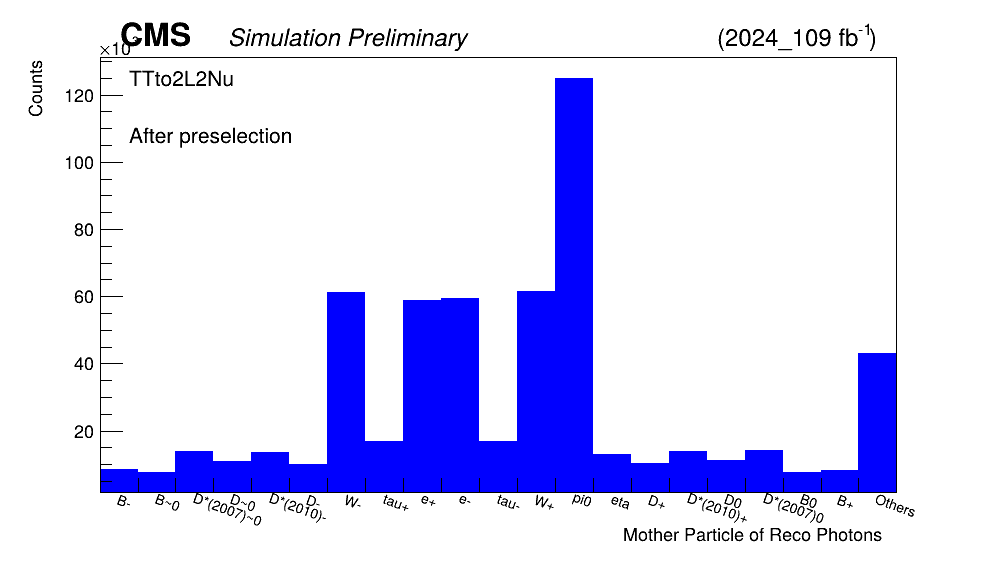

In [9]:
gen = events[event_mask].GenPart

selected_photons = selected_photons[event_mask]

selected_photons = selected_photons[ak.argsort(selected_photons.pt, ascending=False)]

mother_pdg = gen[gen[selected_photons.genPartIdx].genPartIdxMother].pdgId

mother_ids = ak.flatten(mother_pdg)

from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat_np = np.array(mother_ids)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco Photons;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_selected_phos_TTto2L2Nu_raw.png")

In [10]:
gen = events[event_mask].GenPart

selected_photons = selected_photons[event_mask]

selected_photons = selected_photons[ak.argsort(selected_photons.pt, ascending=False)]

mother_pdg = gen[gen[selected_photons.genPartIdx].genPartIdxMother].pdgId

mother_ids = ak.flatten(mother_pdg)

from particle import Particle

In [11]:
gen[selected_photons.genPartIdx].pdgId*1

<Array [[22, 22], [22, 11], ..., [22, 22]] type='60955 * var * int32[parame...'>

In [12]:
pdg_ids = np.unique(ak.to_numpy(ak.flatten(gen[selected_photons.genPartIdx].pdgId)))

for pid in pdg_ids:
    print(pid, "->", Particle.from_pdgid(int(pid)).name)

-4332 -> Omega(c)~0
-4232 -> Xi(c)~-
-4132 -> Xi(c)~0
-4122 -> Lambda(c)~-
-521 -> B-
-511 -> B~0
-431 -> D(s)-
-421 -> D~0
-411 -> D-
-321 -> K-
-311 -> K~0
-211 -> pi-
-14 -> nu(mu)~
-13 -> mu+
-12 -> nu(e)~
-11 -> e+
11 -> e-
12 -> nu(e)
13 -> mu-
14 -> nu(mu)
21 -> g
22 -> gamma
130 -> K(L)0
211 -> pi+
221 -> eta
310 -> K(S)0
311 -> K0
321 -> K+
411 -> D+
421 -> D0
431 -> D(s)+
441 -> eta(c)(1S)
443 -> J/psi(1S)
445 -> chi(c2)(1P)
511 -> B0
4122 -> Lambda(c)+
4132 -> Xi(c)0
4232 -> Xi(c)+
4332 -> Omega(c)0


In [11]:
pho_gen = gen[gen[selected_photons.genPartIdx].genPartIdxMother]

In [14]:
pho_gen.pdgId

<Array [[-6, 111], [-24, ...], ..., [-5, 111]] type='60955 * var * int32[pa...'>

In [15]:
pho_gen.pt

<Array [??, ??, ??, ??, ..., ??, ??, ??, ??] type='60955 * var * float32[pa...'>

In [16]:
brem_pho = ak.sum(ak.num(pho_gen[abs(pho_gen.pdgId) == 11].pdgId))

In [17]:
all_pho = ak.sum(ak.num(selected_photons.pt))

In [18]:
brem_rate = (brem_pho/all_pho)*100

In [19]:
brem_rate

18.241350872465688

In [20]:
abs(pho_gen.pdgId) == 11

<Array [[False, False], ..., [False, ...]] type='60955 * var * bool[paramet...'>

In [21]:
#pho_gen is the reco matched gen particle's mother particle
brems = selected_photons[(abs(pho_gen.pdgId) == 11) & (abs(gen[selected_photons.genPartIdx].pdgId) == 22)]

In [22]:
gen[selected_photons.genPartIdx].pdgId

<Array [[22, 22], [22, 11], ..., [22, 22]] type='60955 * var * int32[parame...'>

In [23]:
one_mask = ak.num(brems.pt)>0

In [24]:
Electrons = events[event_mask].Electron
eles = Electrons[one_mask]

In [25]:
brems[one_mask].pt

<Array [[22.4], [33.6, 17.2], ..., [44], [24]] type='10655 * var * float32[...'>

In [26]:
brems_padded = ak.pad_none(brems[one_mask],2)

brem1 = brems_padded[:, 0]
brem2 = brems_padded[:, 1]

In [27]:
brem1.pt

<Array [22.4, 33.6, 16.5, ..., 34.3, 44, 24] type='10655 * ?float32[paramet...'>

In [28]:
eles.pt

<Array [[60.2, 12.4], [34.5], ..., [...], []] type='10655 * var * float32[p...'>

In [29]:
brem1_dr = delta_r_manual(brem1, eles)
brem2_dr = delta_r_manual(brem2, eles)

In [30]:
brem1_dr

<Array [[0.416, 2.71], [3.39], ..., [...], []] type='10655 * var * ?float32...'>

In [31]:
min_brem1_dr = ak.min(brem1_dr, axis =1)
min_brem2_dr = ak.min(brem2_dr, axis =1)

In [32]:
min_brem1_dr

<Array [0.416, 3.39, 0.863, ..., 1.96, 1.39, None] type='10655 * ?float32'>

In [33]:
min_brem2_dr

<Array [None, 0.644, None, None, ..., 1.53, None, None] type='10655 * ?float32'>

In [34]:
is_near_ele1 = min_brem1_dr[~ak.is_none(min_brem1_dr)]<0.1
is_near_ele2 = min_brem2_dr[~ak.is_none(min_brem2_dr)]<0.1

In [35]:
is_near_ele1

<Array [False, False, False, ..., False, False, False] type='9603 * ?bool'>

In [36]:
is_near_ele2

<Array [False, False, False, ..., False, False, False] type='500 * ?bool'>

In [37]:
brem1_match_rate = ak.sum(is_near_ele1)/ak.sum(~ak.is_none(brem1.pt))
brem2_match_rate = ak.sum(is_near_ele2)/ak.sum(~ak.is_none(brem2.pt))

In [38]:
brem1_match_rate

0.04185828249648053

In [39]:
brem2_match_rate

0.06802721088435375

In [40]:
brems_padded.pt

<Array [[22.4, None], [...], ..., [24, None]] type='10655 * var * ?float32[...'>

In [41]:
Photons = events[event_mask].Photon
phos = Photons[one_mask]

In [42]:
brem_pho_dr1 = delta_r_manual(brem1, phos)
brem_pho_dr2 = delta_r_manual(brem2, phos)

In [43]:
brem_pho_dr1_non0 = brem_pho_dr1[brem_pho_dr1!=0]
brem_pho_dr2_non0 = brem_pho_dr2[brem_pho_dr2!=0]
min_brem_pho_dr1 = ak.min(brem_pho_dr1_non0, axis =1)
min_brem_pho_dr2 = ak.min(brem_pho_dr2_non0, axis =1)

In [44]:
one_masked_gen = gen[one_mask]

In [45]:
one_masked_gen[brems[one_mask].genPartIdx].pdgId

<Array [[22], [22, 22], [22], ..., [22], [22]] type='10655 * var * int32[pa...'>

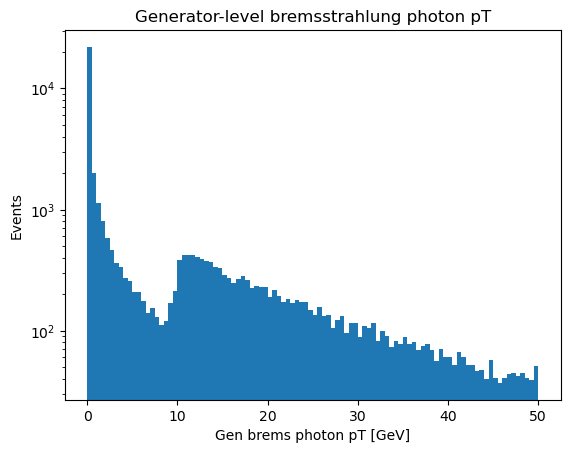

In [46]:
Gen = events.GenPart

gen_photons = Gen[abs(Gen.pdgId) == 22]

mother1 = Gen[gen_photons.genPartIdxMother]
mother2 = Gen[mother1.genPartIdxMother]

brem_mask = (
    (abs(gen_photons.pdgId) == 22) &
    (abs(mother1.pdgId) == 11) 
)

brem_photons = gen_photons[brem_mask]

brem_pt = ak.flatten(brem_photons.pt)

import matplotlib.pyplot as plt

plt.hist(ak.to_numpy(brem_pt), bins=100, range=(0,50))
plt.xlabel("Gen brems photon pT [GeV]")
plt.ylabel("Events")
plt.title("Generator-level bremsstrahlung photon pT")
plt.yscale('log')
plt.show()

In [47]:
ak.sum(brem_pt>10)/ak.sum((gen_photons.pt>0.0000001)&(gen_photons.pt<10))

0.14487726787620064

In [48]:
brem_one_mask = brems[one_mask]

In [49]:
gen_one_mask = gen[one_mask]

In [50]:
gen_one_mask[gen_one_mask[brem_one_mask.genPartIdx].genPartIdxMother].pdgId

<Array [[-11], [-11, 11], ..., [-11], [-11]] type='10655 * var * int32[para...'>

In [51]:
gen_electrons = gen_one_mask[abs(gen_one_mask.pdgId) == 11]

In [52]:
gen_electrons.genPartIdxMother

<Array [[9, 12, 24, 24, ..., 28, 31, 31], ...] type='10655 * var * int16[pa...'>

In [53]:
gen_electrons.pt

<Array [[81.8, 60.2, ..., 0.0632, 0.615], ...] type='10655 * var * float32[...'>

In [54]:
gen_one_mask[brem_one_mask.genPartIdx].genPartIdxMother

<Array [[12], [14, 20], [15], ..., [15], [14]] type='10655 * var * int16[pa...'>

In [55]:
brem1_id = gen_one_mask[brem_one_mask.genPartIdx].genPartIdxMother[:,0]
# brem2_id = gen_one_mask[brem_one_mask.genPartIdx].genPartIdxMother[:,1]

In [56]:
brem_ele = gen_electrons[gen_electrons.genPartIdxMother == brem1_id]

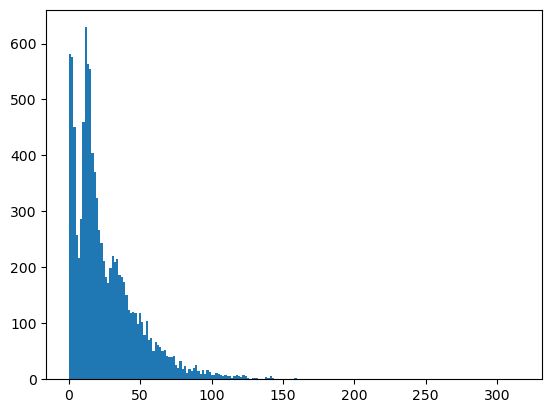

In [57]:
plt.hist(ak.flatten(brem_ele.pt), bins = 200);

In [58]:
DeltaR = delta_r_manual(brem_ele, brem1)

In [59]:
brem1.pt

<Array [22.4, 33.6, 16.5, ..., 34.3, 44, 24] type='10655 * ?float32[paramet...'>

In [60]:
brem_ele.pt

<Array [[60.2], [5.48], ..., [12.7], [11.4]] type='10655 * var * float32[pa...'>

In [61]:
gen_one_mask[gen_one_mask[brem_one_mask.genPartIdx].genPartIdxMother].pt

<Array [[81.8], [34.2, 51], ..., [35.8]] type='10655 * var * float32[parame...'>

In [62]:
DeltaR

<Array [[[0.416]], [[0.0191]], ..., [[0.656]]] type='10655 * option[1 * var...'>

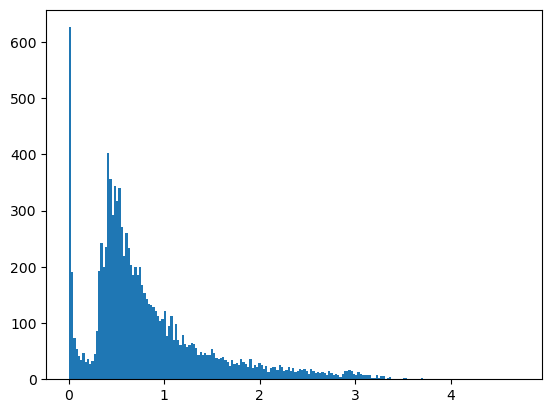

In [63]:
plt.hist(ak.flatten(ak.flatten(DeltaR)), bins = 200);

In [64]:
#pho_gen is the reco matched gen particle's mother particle
ele_fake = selected_photons[(abs(pho_gen.pdgId) == 11) & (abs(gen[selected_photons.genPartIdx].pdgId) == 11)]

In [65]:
ele_fake[ak.num(ele_fake.pt)>0].pt

<Array [[10.6], [15.4], ..., [114], [10.7]] type='11062 * var * float32[par...'>

In [66]:
ak.sum(ak.num(ele_fake.pt)>1)

33

In [67]:
gen[ak.num(ele_fake.pt)>0].pt

<Array [[0, 0, 108, ..., 102, 14.3, 12.9], ...] type='11062 * var * float32...'>

In [68]:
second_eles = Electrons[ak.num(ele_fake.pt)>0]

In [69]:
second_eles.pt

<Array [[45.1, 10.9], [108, ...], ..., []] type='11062 * var * float32[para...'>

In [70]:
Delta_R1_case2 = delta_r_manual(ele_fake[ak.num(ele_fake.pt)>0][:,0], second_eles)
# Delta_R2_case2 = delta_r_manual(ele_fake[ak.num(ele_fake.pt)>0][:,1], second_eles)

In [71]:
Delta_R1_case2

<Array [[1.23, 0.0741], [2.37, ...], ..., []] type='11062 * var * float32[p...'>

In [72]:
gen2 = gen[ak.num(ele_fake.pt)>0]

In [73]:
second_eles.genPartIdx

<Array [??, ??, ??, ??, ..., ??, ??, ??, ??] type='11062 * var * int16[para...'>

In [74]:
gen2[ele_fake[ak.num(ele_fake.pt)>0].genPartIdx].pdgId

<Array [[11], [-11], [-11], ..., [11], [-11]] type='11062 * var * int32[par...'>

In [75]:
DeltaR2_mask = Delta_R1_case2<0.1

In [76]:
DeltaR2_mask 

<Array [[False, True], [False, ...], ..., []] type='11062 * var * bool[para...'>

In [77]:
second_eles.genPartIdx[DeltaR2_mask]

<Array [[21], [13], [14], ..., [17], [17], []] type='11062 * var * int16[pa...'>

In [78]:
ele_gen = gen[abs(gen.pdgId)==11]

In [79]:
ele_gen = ele_gen[one_mask]

In [80]:
ele_gen.genPartIdxMother

<Array [[9, 12, 24, 24, ..., 28, 31, 31], ...] type='10655 * var * int16[pa...'>

In [81]:
reco_matched = gen[selected_photons.genPartIdx]

In [82]:
matched_reco_pho = reco_matched[reco_matched.pdgId == 22]
matched_reco_pho = matched_reco_pho[one_mask]
matched_reco_pho = ak.pad_none(matched_reco_pho, 2)
matched_reco_pho_lead = matched_reco_pho[:,0]
matched_reco_pho_sublead = matched_reco_pho[:,1]

In [83]:
matched_reco_pho_sublead.genPartIdxMother

<Array [40, 20, None, None, ..., 19, 10, None] type='10655 * ?int16[paramet...'>

In [84]:
bremmed_ele1 = ele_gen[ele_gen.genPartIdxMother == matched_reco_pho_lead.genPartIdxMother]
bremmed_ele2 = ele_gen[ele_gen.genPartIdxMother == matched_reco_pho_sublead.genPartIdxMother]

In [85]:
bremmed_ele1.pdgId

<Array [[-11], [-11], [-11], ..., [-11], [-11]] type='10655 * option[var * ...'>

In [86]:
brem1_dr = delta_r_manual(bremmed_ele1, matched_reco_pho_lead)
brem2_dr = delta_r_manual(bremmed_ele2, matched_reco_pho_sublead)

In [87]:
brem1_dr

<Array [[[0.411]], ..., [[0.649]]] type='10655 * option[1 * option[var * ?f...'>

In [88]:
brem2_dr

<Array [[[]], [[0.626]], None, ..., [[]], None] type='10655 * option[1 * op...'>

In [89]:
all_brem_dr = ak.concatenate([ak.flatten(brem1_dr),ak.flatten(brem2_dr)])

In [90]:
all_brem_dr = all_brem_dr[ak.num(all_brem_dr)>0]

In [91]:
close_fraction = ak.sum(all_brem_dr<0.1)/len(ak.flatten(all_brem_dr))

In [92]:
close_fraction

0.09973489350031996

Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xb

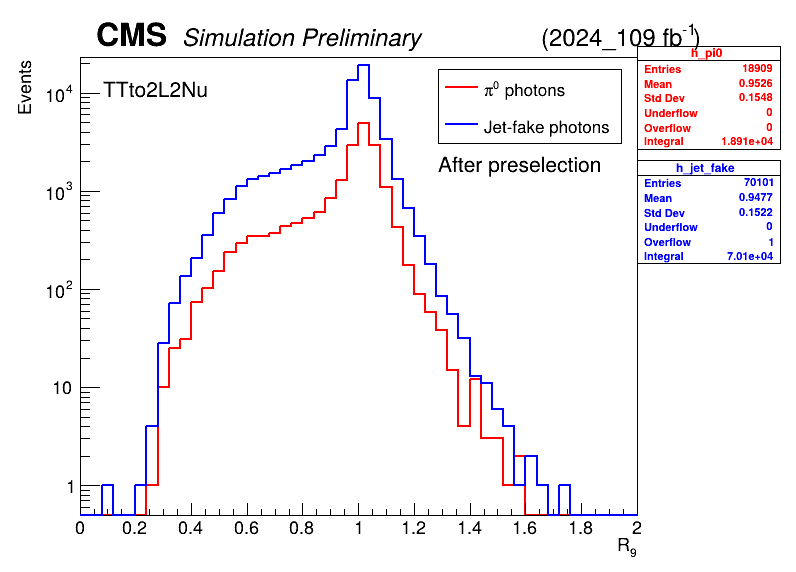

In [96]:
make_hist1d(
    all_brem_dr,
    name="dR_bremmed_ele_brem_pho",
    title="Delta R between bremmed electrons and brem photon (Gen)",
    nbins=50,
    xmin=0,
    xmax=10.0,
    xlabel="#Delta R between bremmed electron and brem photon (Gen)",
    ylabel="Events",
    imgfile="dR_bremmed_ele_brem_pho.png",
    Process = "TTto2L2Nu",
    save_root=True,
    logy=True
)

In [97]:
mother_gen_ele = pho_gen[abs(pho_gen.pdgId) == 11]

In [155]:
mother_gen_ele.status*1

<Array [[], [23], [23], [], ..., [], [], []] type='60955 * var * int32[para...'>

In [157]:
reco_matched_ele = reco_matched[abs(reco_matched.pdgId) == 11]

In [159]:
reco_matched_ele.status

<Array [[], [1], [1], [], ..., [1, 1], [], []] type='60955 * var * int32[pa...'>

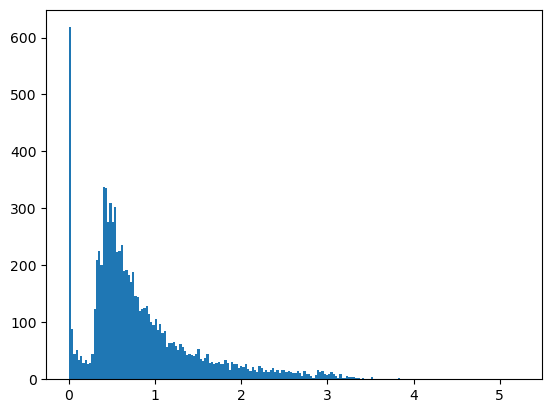

In [98]:
plt.hist(ak.flatten(ak.flatten(brem1_dr)), bins = 200);

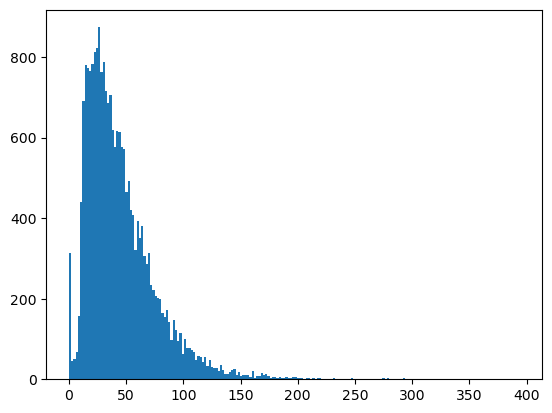

In [99]:
plt.hist(ak.flatten(mother_gen_ele.pt), bins = 200);

In [100]:
bremmed_ele1.pt*1

<Array [[60.2], [5.48], ..., [12.7], [11.4]] type='10655 * option[var * flo...'>

In [37]:
len(events[event_mask])

20945

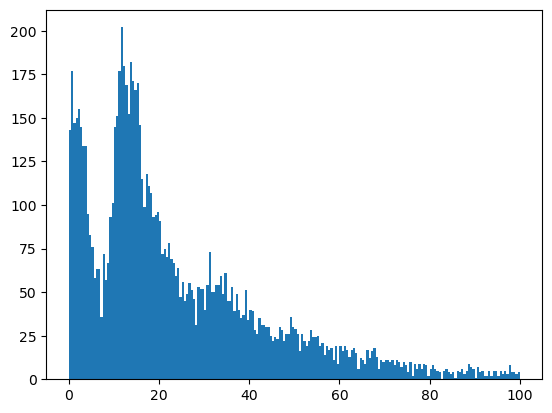

In [101]:
plt.hist(ak.flatten(bremmed_ele1.pt), bins = 200, range = (00, 100));

In [102]:
ele_gen.fields

['genPartIdxMother',
 'statusFlags',
 'pdgId',
 'status',
 'eta',
 'mass',
 'phi',
 'pt',
 'iso',
 'genPartIdxMotherG',
 'distinctParentIdxG',
 'childrenIdxG',
 'distinctChildrenIdxG',
 'distinctChildrenDeepIdxG']

In [103]:
mother_gen_ele.pdgId

<Array [[], [11], [-11], [], ..., [], [], []] type='60955 * var * int32[par...'>

In [29]:
ele_faking_pho = selected_photons[((abs(pho_gen.pdgId) == 11)) & (abs(gen[selected_photons.genPartIdx].pdgId) == 11)]

In [30]:
ele_faking_pho = ele_faking_pho[ak.num(ele_faking_pho.pt)>0]

In [31]:
ele_faking_pho.pt

<Array [[15.4], [93.3], ..., [60.2], [20.1]] type='4397 * var * float32[par...'>

In [33]:
brems_pho = selected_photons[((abs(pho_gen.pdgId) == 11)) & (abs(gen[selected_photons.genPartIdx].pdgId) == 22)]

In [34]:
brems_pho = brems_pho[ak.num(brems_pho.pt)>0]

In [35]:
brems_pho.pt

<Array [[22.4], [33.6, 17.2], ..., [44]] type='4296 * var * float32[paramet...'>

In [21]:
pho_gen.pdgId[:,1]

<Array [-11, 111, 111, 24, ..., 24, 511, 111] type='20945 * int32[parameter...'>

In [140]:
ROOT.gStyle.SetOptStat(1111111)

nbins, xmin, xmax = 200, 0, 200

h_ele_fake_pho  = ROOT.TH1F("h_ele_fake_pho",  ";p_{T};Events", nbins, xmin, xmax)
h_brems_pho = ROOT.TH1F("h_brems_pho", ";p_{T};Events", nbins, xmin, xmax)

for v in np.array(ak.flatten(brems_pho.pt)):
    h_brems_pho.Fill(v)

for v in np.array(ak.flatten(ele_faking_pho.pt)):
    h_ele_fake_pho.Fill(v)

# Normalize for shape comparison
if h_brems_pho.Integral() > 0:
    h_brems_pho.Scale(1.0 / h_brems_pho.Integral())
if h_ele_fake_pho.Integral() > 0:
    h_ele_fake_pho.Scale(1.0 / h_ele_fake_pho.Integral())

# Style
h_brems_pho.SetLineColor(ROOT.kRed)
h_brems_pho.SetLineWidth(2)

h_ele_fake_pho.SetLineColor(ROOT.kBlue)
h_ele_fake_pho.SetLineWidth(2)

h_brems_pho.SetMaximum(1.2 * max(h_brems_pho.GetMaximum(), h_ele_fake_pho.GetMaximum()))

# Canvas
c = ROOT.TCanvas("c","",800,600)
c.SetLogy()

h_brems_pho.Draw("hist")
h_ele_fake_pho.Draw("hist same")

h_brems_pho.GetXaxis().SetTitleSize(0.04)

leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
leg.AddEntry(h_brems_pho, "brem photon", "l")
leg.AddEntry(h_ele_fake_pho, "electron faking photon", "l")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.23, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.Update()
draw_side_statboxes(c, [h_brems_pho, h_ele_fake_pho])
c.Update()

c.SaveAs(Plot_dir + "pT_dist_brems_vs_ele_fake_normalized.png")


f = ROOT.TFile(Plot_dir + "pT_dist_brems_vs_ele_fake_normlaized.root","RECREATE")
c.Write()
f.Close()

Warning in <TROOT::Append>: Replacing existing TH1: h_ele_fake_pho (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_brems_pho (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161

In [111]:
brems_pho.electronVeto*1

<Array [[1], [1], [1], ..., [1], [1], [1, 1]] type='5205 * var * int64[para...'>

In [112]:
ele_faking_pho.electronVeto*1

<Array [[0], [1], [1], [1], ..., [0], [1], [1]] type='5578 * var * int64[pa...'>

In [150]:
ak.sum(ele_faking_pho.electronVeto[ele_faking_pho.electronVeto == 1])

3210

In [152]:
ak.sum(brems_pho.electronVeto[brems_pho.electronVeto == 1])

5265

In [113]:
true_brem_pho_frac = ak.sum(brems_pho.electronVeto)/len(ak.flatten(brems_pho.electronVeto))
true_fake_ele_pho_frac = ak.sum(ele_faking_pho.electronVeto)/len(ak.flatten(ele_faking_pho.electronVeto))

In [191]:
len(ak.flatten(brems_pho))

5386

In [192]:
len(ak.flatten(ele_faking_pho))

5579

In [214]:
brems_frac = len(ak.flatten(brems_pho))/(2*len(selected_photons))
fake_ele_frac = len(ak.flatten(ele_faking_pho))/(2*len(selected_photons))

In [215]:
brems_frac

0.0441801328849151

In [216]:
fake_ele_frac

0.04576326798457879

In [148]:
# Histogram with 2 bins
h = ROOT.TH1F("h_frac", ";; Electron Veto passing Fraction", 2, 0, 2)

h.SetBinContent(1, true_brem_pho_frac)
h.SetBinContent(2, true_fake_ele_pho_frac)

h.GetXaxis().SetBinLabel(1, "brem photon")
h.GetXaxis().SetBinLabel(2, "electron fake photon")

# Style
h.SetFillColor(ROOT.kAzure+1)
h.SetBarWidth(0.5)
h.SetBarOffset(0.25)
h.GetXaxis().SetLabelSize(0.06)
h.GetXaxis().SetTitleOffset(1.1)

# Canvas
c = ROOT.TCanvas("c","",700,600)

h.SetMaximum(1.0)
h.SetMinimum(0.0)
h.Draw("bar")

c.Update()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.SaveAs(Plot_dir+"electronVeto_fraction_TTto2L2Nu.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_frac (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/electronVeto_fraction_TTto2L2Nu.png has been created


In [217]:
# Histogram with 2 bins
h = ROOT.TH1F("h_frac", ";; Brem vs ele-fake-pho percentage", 2, 0, 2)

h.SetBinContent(1, brems_frac*100)
h.SetBinContent(2, fake_ele_frac*100)

h.GetXaxis().SetBinLabel(1, "brem photon")
h.GetXaxis().SetBinLabel(2, "electron fake photon")

# Style
h.SetFillColor(ROOT.kAzure+1)
h.SetBarWidth(0.5)
h.SetBarOffset(0.25)
h.GetXaxis().SetLabelSize(0.06)
h.GetXaxis().SetTitleOffset(1.1)

# Canvas
c = ROOT.TCanvas("c","",700,600)

h.SetMaximum(10)
h.SetMinimum(0.0)
h.Draw("bar")

c.Update()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.SaveAs(Plot_dir+"fake_pho_fraction_TTto2L2Nu.png")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/fake_pho_fraction_TTto2L2Nu.png has been created


In [114]:
true_brem_pho_frac

0.9775343483104345

In [115]:
true_fake_ele_pho_frac

0.5753719304534863

In [116]:
brems_pho.fields

['cutBased',
 'electronVeto',
 'hasConversionTracks',
 'isScEtaEB',
 'isScEtaEE',
 'mvaID_WP80',
 'mvaID_WP90',
 'pixelSeed',
 'seedGain',
 'electronIdx',
 'jetIdx',
 'seediEtaOriX',
 'seediPhiOriY',
 'vidNestedWPBitmap',
 'ecalPFClusterIso',
 'energyErr',
 'energyRaw',
 'esEffSigmaRR',
 'esEnergyOverRawE',
 'eta',
 'etaWidth',
 'haloTaggerMVAVal',
 'hcalPFClusterIso',
 'hoe',
 'hoe_PUcorr',
 'hoe_Tower',
 'mvaID',
 'pfChargedIso',
 'pfChargedIsoPFPV',
 'pfChargedIsoWorstVtx',
 'pfPhoIso03',
 'pfRelIso03_all_quadratic',
 'pfRelIso03_chg_quadratic',
 'phi',
 'phiWidth',
 'pt',
 'r9',
 's4',
 'sieie',
 'sieip',
 'sipip',
 'superclusterEta',
 'trkSumPtHollowConeDR03',
 'trkSumPtSolidConeDR04',
 'x_calo',
 'y_calo',
 'z_calo',
 'genPartFlav',
 'genPartIdx',
 'electronIdxG',
 'genPartIdxG',
 'jetIdxG']

In [117]:
truec_brem_pho_frac = ak.sum(brems_pho.hasConversionTracks)/len(ak.flatten(brems_pho.hasConversionTracks))
truec_fake_ele_pho_frac = ak.sum(ele_faking_pho.hasConversionTracks)/len(ak.flatten(ele_faking_pho.hasConversionTracks))

In [139]:
ROOT.gStyle.SetOptStat(1111111)

nbins, xmin, xmax = 200, 0, 0.1

h_ele_fake_pho  = ROOT.TH1F("h_ele_fake_pho",  ";#sigma_{i#etai#eta};Events", nbins, xmin, xmax)
h_brems_pho = ROOT.TH1F("h_brems_pho", ";#sigma_{i#etai#eta};Events", nbins, xmin, xmax)

for v in np.array(ak.flatten(brems_pho.sieie)):
    h_brems_pho.Fill(v)

for v in np.array(ak.flatten(ele_faking_pho.sieie)):
    h_ele_fake_pho.Fill(v)

# Normalize for shape comparison
if h_brems_pho.Integral() > 0:
    h_brems_pho.Scale(1.0 / h_brems_pho.Integral())
if h_ele_fake_pho.Integral() > 0:
    h_ele_fake_pho.Scale(1.0 / h_ele_fake_pho.Integral())

# Style
h_brems_pho.SetLineColor(ROOT.kRed)
h_brems_pho.SetLineWidth(2)

h_ele_fake_pho.SetLineColor(ROOT.kBlue)
h_ele_fake_pho.SetLineWidth(2)

h_brems_pho.SetMaximum(1.2 * max(h_brems_pho.GetMaximum(), h_ele_fake_pho.GetMaximum()))

# Canvas
c = ROOT.TCanvas("c","",800,600)
c.SetLogy()

h_brems_pho.Draw("hist")
h_ele_fake_pho.Draw("hist same")

h_brems_pho.GetXaxis().SetTitleSize(0.04)

leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
leg.AddEntry(h_brems_pho, "brem photon", "l")
leg.AddEntry(h_ele_fake_pho, "electron faking photon", "l")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.23, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.Update()
draw_side_statboxes(c, [h_brems_pho, h_ele_fake_pho])
c.Update()

c.SaveAs(Plot_dir + "sieie_dist_brems_vs_ele_fake_normalized.png")


f = ROOT.TFile(Plot_dir + "sieie_dist_brems_vs_ele_fake_normlaized.root","RECREATE")
c.Write()
f.Close()

Warning in <TROOT::Append>: Replacing existing TH1: h_ele_fake_pho (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_brems_pho (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161

In [138]:
ROOT.gStyle.SetOptStat(1111111)

nbins, xmin, xmax = 200, 0, 2.0

h_ele_fake_pho  = ROOT.TH1F("h_ele_fake_pho",  ";R_{9};Events", nbins, xmin, xmax)
h_brems_pho = ROOT.TH1F("h_brems_pho", ";R_{9};Events", nbins, xmin, xmax)

for v in np.array(ak.flatten(brems_pho.r9)):
    h_brems_pho.Fill(v)

for v in np.array(ak.flatten(ele_faking_pho.r9)):
    h_ele_fake_pho.Fill(v)

# Normalize for shape comparison
if h_brems_pho.Integral() > 0:
    h_brems_pho.Scale(1.0 / h_brems_pho.Integral())
if h_ele_fake_pho.Integral() > 0:
    h_ele_fake_pho.Scale(1.0 / h_ele_fake_pho.Integral())

# Style
h_brems_pho.SetLineColor(ROOT.kRed)
h_brems_pho.SetLineWidth(2)

h_ele_fake_pho.SetLineColor(ROOT.kBlue)
h_ele_fake_pho.SetLineWidth(2)

h_brems_pho.SetMaximum(1.2 * max(h_brems_pho.GetMaximum(), h_ele_fake_pho.GetMaximum()))

# Canvas
c = ROOT.TCanvas("c","",800,600)
c.SetLogy()

h_brems_pho.Draw("hist")
h_ele_fake_pho.Draw("hist same")

h_brems_pho.GetXaxis().SetTitleSize(0.04)

leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
leg.AddEntry(h_brems_pho, "brem photon", "l")
leg.AddEntry(h_ele_fake_pho, "electron faking photon", "l")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.Update()
draw_side_statboxes(c, [h_brems_pho, h_ele_fake_pho])
c.Update()

c.SaveAs(Plot_dir + "R9_brems_vs_ele_fake_normalized.png")


f = ROOT.TFile(Plot_dir + "R9_brems_vs_ele_fake_normlaized.root","RECREATE")
c.Write()
f.Close()

Warning in <TROOT::Append>: Replacing existing TH1: h_ele_fake_pho (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_brems_pho (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161

In [137]:
ROOT.gStyle.SetOptStat(1111111)

nbins, xmin, xmax = 200, 0, 0.001

h_ele_fake_pho  = ROOT.TH1F("h_ele_fake_pho",  ";#sigma_{i#etaip};Events", nbins, xmin, xmax)
h_brems_pho = ROOT.TH1F("h_brems_pho", ";#sigma_{i#etaip};Events", nbins, xmin, xmax)

for v in np.array(ak.flatten(brems_pho.sieip)):
    h_brems_pho.Fill(v)

for v in np.array(ak.flatten(ele_faking_pho.sieip)):
    h_ele_fake_pho.Fill(v)

# Normalize for shape comparison
if h_brems_pho.Integral() > 0:
    h_brems_pho.Scale(1.0 / h_brems_pho.Integral())
if h_ele_fake_pho.Integral() > 0:
    h_ele_fake_pho.Scale(1.0 / h_ele_fake_pho.Integral())

# Style
h_brems_pho.SetLineColor(ROOT.kRed)
h_brems_pho.SetLineWidth(2)

h_ele_fake_pho.SetLineColor(ROOT.kBlue)
h_ele_fake_pho.SetLineWidth(2)

h_brems_pho.SetMaximum(1.2 * max(h_brems_pho.GetMaximum(), h_ele_fake_pho.GetMaximum()))

# Canvas
c = ROOT.TCanvas("c","",800,600)
c.SetLogy()

h_brems_pho.Draw("hist")
h_ele_fake_pho.Draw("hist same")

h_brems_pho.GetXaxis().SetNoExponent(False)
h_brems_pho.GetXaxis().SetMaxDigits(3)
h_brems_pho.GetXaxis().SetTitleSize(0.04)

ROOT.gPad.Modified()
ROOT.gPad.Update()

leg = ROOT.TLegend(0.55,0.75,0.78,0.88)
leg.AddEntry(h_brems_pho, "brem photon", "l")
leg.AddEntry(h_ele_fake_pho, "electron faking photon", "l")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.Update()
draw_side_statboxes(c, [h_brems_pho, h_ele_fake_pho])
c.Update()

c.SaveAs(Plot_dir + "sieip_dist_brems_vs_ele_fake_normalized.png")


f = ROOT.TFile(Plot_dir + "sieip_dist_brems_vs_ele_fake_normlaized.root","RECREATE")
c.Write()
f.Close()

Warning in <TROOT::Append>: Replacing existing TH1: h_ele_fake_pho (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_brems_pho (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161

In [121]:
pho_gen.pdgId

<Array [[-6, 111], [-24, ...], ..., [-5, 111]] type='60955 * var * int32[pa...'>

In [21]:
ak.sum(ak.num(pho_gen.pdgId)==3)

113

In [122]:
# your awkward array (example variable name)
pdg_array = pho_gen.pdgId   # replace with your array

# flatten the particle list
flat = ak.to_numpy(ak.flatten(pdg_array))

# define PDG groups
groups = {
    "W+/W-": [24, -24],
    "e+/e-": [11, -11],
    "pi0": [111],
    "mu+/mu-": [13, -13],
    "tau+/tau-": [15, -15],
    "t/anti-top": [6, -6]
}

counts = {}

# count particles in each group
for name, pdgs in groups.items():
    counts[name] = np.sum(np.isin(flat, pdgs))

# count others
all_pdgs = np.concatenate(list(groups.values()))
mask_all = np.isin(flat, all_pdgs)
counts["others"] = np.sum(~mask_all)

# convert to fractions
total = len(flat)
fractions = {k: v/total for k,v in counts.items()}

# ROOT histogram (bar plot)
labels = list(fractions.keys())
values = list(fractions.values())

h = ROOT.TH1F("h_fraction", ";Particle Type;Fraction",
              len(labels), 0, len(labels))

for i, (label, val) in enumerate(zip(labels, values), start=1):
    h.SetBinContent(i, val)
    h.GetXaxis().SetBinLabel(i, label)

h.SetFillColor(ROOT.kAzure+1)
h.SetBarWidth(0.8)
h.SetBarOffset(0.1)

c = ROOT.TCanvas("c", "c", 800, 600)
h.Draw("bar2")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.55, 0.70, "After preselection")

c.SaveAs(Plot_dir+"particle_fraction_TTto2L2Nu.png")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/particle_fraction_TTto2L2Nu.png has been created


In [23]:
pdg_array = pho_gen.pdgId

# ensure at least 2 photons per event
pdg_padded = ak.pad_none(pdg_array, 2)

lead_pdg = ak.to_numpy(pdg_padded[:, 0])
sublead_pdg = ak.to_numpy(pdg_padded[:, 1])

# remove NaN / None
lead_pdg = lead_pdg[~np.isnan(lead_pdg)]
sublead_pdg = sublead_pdg[~np.isnan(sublead_pdg)]

# -------------------------
# Define PDG groups
# -------------------------
groups = {
    "W+/W-": [24, -24],
    "e+/e-": [11, -11],
    "pi0": [111],
    "mu+/mu-": [13, -13],
    "tau+/tau-": [15, -15],
    "t/anti-top": [6, -6]
}

# -------------------------
# Function-like inline logic
# -------------------------
def compute_fraction(arr):
    counts = {}
    for name, pdgs in groups.items():
        counts[name] = np.sum(np.isin(arr, pdgs))

    all_pdgs = np.concatenate(list(groups.values()))
    mask_all = np.isin(arr, all_pdgs)
    counts["others"] = np.sum(~mask_all)

    total = len(arr)
    return {k: v/total if total > 0 else 0 for k, v in counts.items()}

fractions_lead = compute_fraction(lead_pdg)
fractions_sublead = compute_fraction(sublead_pdg)

# -------------------------
# Plot: Leading photon
# -------------------------
labels = list(fractions_lead.keys())

h_lead = ROOT.TH1F("h_lead", ";Particle Type;Fraction",
                  len(labels), 0, len(labels))

for i, label in enumerate(labels, start=1):
    h_lead.SetBinContent(i, fractions_lead[label])
    h_lead.GetXaxis().SetBinLabel(i, label)

h_lead.SetFillColor(ROOT.kAzure+1)
h_lead.SetBarWidth(0.8)
h_lead.SetBarOffset(0.1)

c1 = ROOT.TCanvas("c1", "c1", 800, 600)
h_lead.Draw("bar2")

CMS_label(c1)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")
latex.DrawLatex(0.55, 0.70, "Leading photon")

c1.SaveAs(Plot_dir + "particle_fraction_lead.png")

# -------------------------
# Plot: Subleading photon
# -------------------------
h_sub = ROOT.TH1F("h_sub", ";Particle Type;Fraction",
                 len(labels), 0, len(labels))

for i, label in enumerate(labels, start=1):
    h_sub.SetBinContent(i, fractions_sublead[label])
    h_sub.GetXaxis().SetBinLabel(i, label)

h_sub.SetFillColor(ROOT.kAzure+1)
h_sub.SetBarWidth(0.8)
h_sub.SetBarOffset(0.1)

c2 = ROOT.TCanvas("c2", "c2", 800, 600)
h_sub.Draw("bar2")

CMS_label(c2)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.DrawLatex(0.13, 0.83, "TTto2L2Nu")
latex.DrawLatex(0.55, 0.70, "Subleading photon")

c2.SaveAs(Plot_dir + "particle_fraction_sublead.png")

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/particle_fraction_lead.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTto2L2Nu/particle_fraction_sublead.png has been created


In [24]:
len(ak.flatten(pho_gen[abs(pho_gen.pdgId) == 11].pdgId))

8986

In [36]:
len(ak.flatten(brems_pho.pt))

4575

In [32]:
len(ak.flatten(ele_faking_pho.pt))

4411

In [ ]:
import awkward as ak
import numpy as np
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import correctionlib

def add_zero_photon_mass_and_charge(photons: ak.Array) -> ak.Array:
    """Add zero mass to the Photon object in the events."""
    # add zero photon mass and charge
    # TODO: remove this temporary fix when https://github.com/scikit-hep/vector/issues/498 is resolved
    photons["mass"] = ak.zeros_like(photons.pt)
    photons["charge"] = ak.zeros_like(photons.pt)
    return photons

def add_jetId(jets, flattenUnflatten=False):
    """
    Add (or recompute) jet ID to the jets object based on the NanoAOD version.
    """
    abs_eta = abs(jets.eta)

    jerc_json = "/eos/user/b/bbapi/HiggsDNA_220526/HiggsDNA/higgs_dna/systematics/JSONs/POG/JME/2024_Summer24/jetid.json.gz"

    cset = correctionlib.CorrectionSet.from_file(jerc_json)

    if flattenUnflatten:
        counts = ak.num(jets)
        jets = ak.flatten(jets, axis=1)

    eval_dict = {
        "eta": jets.eta,
        "chHEF": jets.chHEF,
        "neHEF": jets.neHEF,
        "chEmEF": jets.chEmEF,
        "neEmEF": jets.neEmEF,
        "muEF": jets.muEF,
        "chMultiplicity": jets.chMultiplicity,
        "neMultiplicity": jets.neMultiplicity,
        "multiplicity": jets.chMultiplicity + jets.neMultiplicity
    }

    ## Default tight for NanoAOD version 13 and above
    idTight = cset["AK4PUPPI_Tight"]
    inputsTight = [eval_dict[input.name] for input in idTight.inputs]
    idTight_value = idTight.evaluate(*inputsTight) * 2  # equivalent to bit2

    # Default tight lepton veto
    idTightLepVeto = cset["AK4PUPPI_TightLeptonVeto"]
    inputsTightLepVeto = [eval_dict[input.name] for input in idTightLepVeto.inputs]
    idTightLepVeto_value = idTightLepVeto.evaluate(*inputsTightLepVeto) * 4  # equivalent to bit3

    # Default jet ID
    id_value = idTight_value + idTightLepVeto_value

    if flattenUnflatten:
        return ak.unflatten(id_value, counts)
    else:
        return id_value


def delta_r_mask(
    first: ak.highlevel.Array, second: ak.highlevel.Array, threshold: float
) -> ak.highlevel.Array:

    mval = first.metric_table(second)
    return ak.all(mval > threshold, axis=-1)

def build_diphoton_candidates(photons, min_pt_lead_photon):
    # Sort photons in descending order of pT
    sorted_photons = photons[ak.argsort(photons.pt, ascending=False)]

    # Create all possible pairs of photons (combinations) with fields "pho_lead" and "pho_sublead"
    diphotons = ak.combinations(sorted_photons, 2, fields=["pho_lead", "pho_sublead"])

    # Apply the cut on the leading photon's pT
    diphotons = diphotons[diphotons["pho_lead"].pt > min_pt_lead_photon]

    # Combine four-momenta of the two photons
    diphoton_4mom = diphotons["pho_lead"] + diphotons["pho_sublead"]
    diphotons["pt"] = diphoton_4mom.pt
    diphotons["eta"] = diphoton_4mom.eta
    diphotons["phi"] = diphoton_4mom.phi
    diphotons["mass"] = diphoton_4mom.mass
    diphotons["charge"] = diphoton_4mom.charge

    # Calculate rapidity
    diphoton_pz = diphoton_4mom.z
    diphoton_e = diphoton_4mom.energy
    diphotons["rapidity"] = 0.5 * np.log((diphoton_e + diphoton_pz) / (diphoton_e - diphoton_pz))

    # Sort diphoton candidates by pT in descending order
    diphotons = diphotons[ak.argsort(diphotons.pt, ascending=False)]
    diphotons = ak.with_name(diphotons, "PtEtaPhiMCandidate")

    return diphotons

def photon_preselection_bbgg(
    photons: ak.Array,
    events: ak.Array,
    electrons: ak.Array,
    muons: ak.Array
) -> ak.Array:

    dr_cut = delta_r_mask(photons, electrons, 0.2)
    dr_cut_muon = delta_r_mask(photons, muons, 0.2)

    return photons[
        (~photons.pixelSeed)
        & (photons.pt > 15.0)
        & (photons.isScEtaEB | photons.isScEtaEE)
        & dr_cut
        & dr_cut_muon
        &(ak.where(photons.isScEtaEB, photons.mvaID > 0.0439603, photons.mvaID > -0.249526))
    ]


def select_electrons_bbgg(
    electrons: ak.highlevel.Array
) -> ak.highlevel.Array:
    pt_cut = electrons.pt > 30

    eta_cut = abs(electrons.eta) < 2.5

    id_cut = electrons.mvaIso_WP80

    return pt_cut & eta_cut & id_cut

def select_muons_bbgg(
    muons: ak.highlevel.Array
) -> ak.highlevel.Array:
    pt_cut = muons.pt > 26.0

    eta_cut = abs(muons.eta) < 2.4

    id_cut = muons.mediumId
        
    iso_cut = muons.pfIsoId >= 3
   
    global_cut = muons.isGlobal

    return pt_cut & eta_cut & id_cut & iso_cut & global_cut 


def select_jets_bbgg(
    jets: ak.highlevel.Array,
    diphotons: ak.highlevel.Array,
    muons: ak.highlevel.Array,
    electrons: ak.highlevel.Array,
    clean_jet_pho: bool = True,
    clean_jet_ele: bool = True,
    clean_jet_muo: bool = True
) -> ak.highlevel.Array:
    

    jetId_cut = jets.jetId >= 2

    pt_cut = jets.pt > 20
    eta_cut = abs(jets.eta) < 2.4

    if (clean_jet_pho) & (ak.num(diphotons.pt, axis=0) > 0):
        lead = ak.zip(
            {
                "pt": diphotons.pho_lead.pt,
                "eta": diphotons.pho_lead.eta,
                "phi": diphotons.pho_lead.phi,
                "mass": diphotons.pho_lead.mass,
                "charge": diphotons.pho_lead.charge,
            }
        )
        lead = ak.with_name(lead, "PtEtaPhiMCandidate")
        sublead = ak.zip(
            {
                "pt": diphotons.pho_sublead.pt,
                "eta": diphotons.pho_sublead.eta,
                "phi": diphotons.pho_sublead.phi,
                "mass": diphotons.pho_sublead.mass,
                "charge": diphotons.pho_sublead.charge,
            }
        )
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        sublead = ak.with_name(sublead, "PtEtaPhiMCandidate")
        dr_pho_lead_cut = delta_r_mask(jets, lead, 0.4)
        dr_pho_sublead_cut = delta_r_mask(jets, sublead, 0.4)
    else:
        dr_pho_lead_cut = jets.pt > -1
        dr_pho_sublead_cut = jets.pt > -1

    if (clean_jet_ele) & (ak.num(electrons.pt, axis=0) > 0):
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        dr_electrons_cut = delta_r_mask(jets, electrons, 0.4)
    else:
        dr_electrons_cut = jets.pt > -1

    if (clean_jet_muo) & (ak.num(muons.pt, axis=0) > 0):
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        dr_muons_cut = delta_r_mask(jets, muons, 0.4)
    else:
        dr_muons_cut = jets.pt > -1

    return (
        (jetId_cut)
        & (pt_cut)
        & (eta_cut)
        & (dr_pho_lead_cut)
        & (dr_pho_sublead_cut)
        & (dr_electrons_cut)
        & (dr_muons_cut)
    )

file = ' /eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Skimmer/DYto2E50_24SummerRun3/0075b06d-f7d6-4e1d-9e47-21fbfe50cdaa_skim.root'

factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

electrons = events.Electron
muons = events.Muon
photons = events.Photon
photons = add_zero_photon_mass_and_charge(photons)
Jets = events.Jet
Jet_id = add_jetId(Jets, flattenUnflatten=True)
events["Jet"] = ak.with_field(Jets, Jet_id, "jetId")
jets = events.Jet
genPart = events.GenPart

electrons = electrons[select_electrons_bbgg(electrons)]
muons = muons[select_muons_bbgg(muons)]
photons = photon_preselection_bbgg(photons, events, electrons, muons)
diphotons = build_diphoton_candidates(photons, 15.0)
jets = jets[select_jets_bbgg(jets, diphotons, muons, electrons)]

one_ele = ak.num(electrons) == 1
zero_ele = ak.num(electrons) == 0

one_mu = ak.num(muons) == 1
zero_mu = ak.num(muons) == 0

# Define the two exclusive channels
electron_channel = one_ele & zero_mu
muon_channel     = one_mu & zero_ele


lepton_channel_mask = electron_channel | muon_channel


b_jets = jets[jets.btagUParTAK4B > 0.1272]
at_least_one_bjets = ak.num(b_jets) >= 1
at_least_two_photons = ak.num(photons) >= 2

event_mask = (lepton_channel_mask & at_least_two_photons & at_least_one_bjets)


photons = photons[event_mask]
electrons = electrons[event_mask]
muons = muons[event_mask]
b_jets = b_jets[event_mask]
n_bjets = ak.num(b_jets)
events = events[event_mask]
genPart = genPart[event_mask]

photons = photons[ak.argsort(photons.pt, ascending=False)]

diphotons = build_diphoton_candidates(photons, 15.0)

: 

In [5]:
photons.pt

<Array [[36.4, 32.8], [43.4, 20.3]] type='2 * var * float32[parameters={"__...'>

In [12]:
genPart[photons.genPartIdx].pdgId

<Array [[22, -11], [-11, 22]] type='2 * var * int32[parameters={"__doc__": ...'>

In [15]:
genPart[photons.genPartIdx].pt

<Array [[35.2, 33.1], [43.6, 19.3]] type='2 * var * float32[parameters={"__...'>

In [14]:
genPart[genPart[photons.genPartIdx].genPartIdxMother].pdgId

<Array [[11, -11], [-11, -11]] type='2 * var * int32[parameters={"__doc__":...'>

In [16]:
genPart[genPart[photons.genPartIdx].genPartIdxMother].pt

<Array [[92.5, 33.1], [63.2, 63.2]] type='2 * var * float32[parameters={"__...'>

In [18]:
def delta_r(obj1, obj2):
    dphi = np.arctan2(np.sin(obj1.phi - obj2.phi), np.cos(obj1.phi - obj2.phi))
    deta = obj1.eta - obj2.eta
    return np.sqrt(deta**2 + dphi**2)

In [19]:
delta_r(genPart[photons.genPartIdx][:, 0], genPart[photons.genPartIdx][:, 1])

<Array [2.74, 0.327] type='2 * float32[parameters={"typename": "float[]"}]'>

In [21]:
genPart[photons.genPartIdx][:, 1].pt

<Array [33.1, 19.3] type='2 * float32[parameters={"__doc__": "GenPart_pt[nG...'>

In [7]:
genPart.pt*1

<Array [[0, 0, 64.8, ..., 3.66, 5.27], ...] type='2 * var * float32[paramet...'>

In [9]:
genPart[genPart[photons.genPartIdx].genPartIdxMother*1].pdgId*1

<Array [[11, -11], [-11, -11]] type='2 * var * int32[parameters={"__doc__":...'>

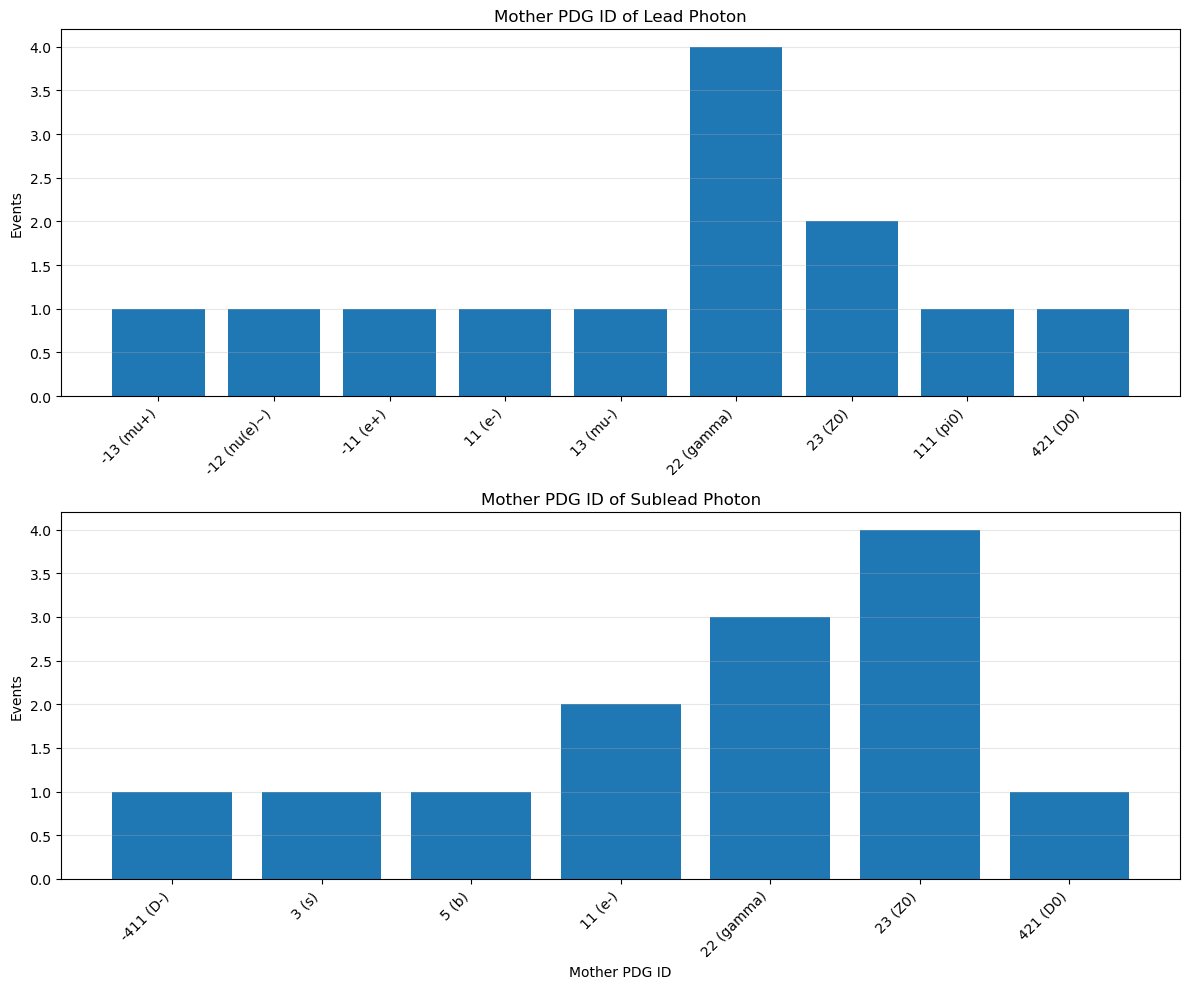

In [15]:
import matplotlib.pyplot as plt
from particle import Particle


# ---------------------------------------------------------
# Mother PDG IDs of lead and sublead photons
# photons are assumed to be already sorted by pT
# ---------------------------------------------------------

photon_genparts = genPart[photons.genPartIdx]

mother_idx = photon_genparts.genPartIdxMother

mother_pdgId = genPart[mother_idx].pdgId

lead_mother_pdgId = mother_pdgId[:, 0]
sublead_mother_pdgId = mother_pdgId[:, 1]


# ---------------------------------------------------------
# Convert PDG ID -> particle name
# ---------------------------------------------------------

def pdgid_to_name(pdgid):
    try:
        p = Particle.from_pdgid(int(pdgid))
        return p.name if p is not None else str(int(pdgid))
    except Exception:
        return str(int(pdgid))


# ---------------------------------------------------------
# Remove None and convert to numpy
# ---------------------------------------------------------

lead_pdg = ak.to_numpy(
    lead_mother_pdgId[~ak.is_none(lead_mother_pdgId)]
)

sublead_pdg = ak.to_numpy(
    sublead_mother_pdgId[~ak.is_none(sublead_mother_pdgId)]
)


# ---------------------------------------------------------
# Get unique PDG IDs and their counts
# ---------------------------------------------------------

lead_ids, lead_counts = np.unique(
    lead_pdg,
    return_counts=True
)

sublead_ids, sublead_counts = np.unique(
    sublead_pdg,
    return_counts=True
)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 10)
)

# Lead
axes[0].bar(
    np.arange(len(lead_ids)),
    lead_counts
)

axes[0].set_xticks(np.arange(len(lead_ids)))
axes[0].set_xticklabels(
    [
        f"{int(pdg)} ({pdgid_to_name(pdg)})"
        for pdg in lead_ids
    ],
    rotation=45,
    ha="right"
)

axes[0].set_ylabel("Events")
axes[0].set_title("Mother PDG ID of Lead Photon")
axes[0].grid(axis="y", alpha=0.3)


# Sublead
axes[1].bar(
    np.arange(len(sublead_ids)),
    sublead_counts
)

axes[1].set_xticks(np.arange(len(sublead_ids)))
axes[1].set_xticklabels(
    [
        f"{int(pdg)} ({pdgid_to_name(pdg)})"
        for pdg in sublead_ids
    ],
    rotation=45,
    ha="right"
)

axes[1].set_xlabel("Mother PDG ID")
axes[1].set_ylabel("Events")
axes[1].set_title("Mother PDG ID of Sublead Photon")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import awkward as ak
import numpy as np

In [2]:
from pathlib import Path
import awkward as ak

output_dir = Path("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/DYGto2LG50_24SummerRun3_selected")

files = sorted(output_dir.glob("part_*.parquet"))

arrays = [ak.from_parquet(str(f)) for f in files]

events_DYG = ak.concatenate(arrays, axis=0)

print(f"Total events: {len(events_DYG)}")

Total events: 26546


In [6]:
from pathlib import Path
import awkward as ak

output_dir = Path("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/DYto2E50_24SummerRun3_selected")

files = sorted(output_dir.glob("part_*.parquet"))

arrays = [ak.from_parquet(str(f)) for f in files]

events = ak.concatenate(arrays, axis=0)

print(f"Total events: {len(events)}")

Total events: 1706


In [7]:
from pathlib import Path
import awkward as ak

output_dir = Path("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/DYto2Mu50_24SummerRun3_selected")

files = sorted(output_dir.glob("part_*.parquet"))

arrays = [ak.from_parquet(str(f)) for f in files]

events_Mu = ak.concatenate(arrays, axis=0)

print(f"Total events: {len(events_Mu)}")

Total events: 1465


In [22]:
events.fields

['luminosityBlock',
 'PSWeight',
 'PV',
 'Photon',
 'run',
 'event',
 'Flag',
 'PuppiMET',
 'Pileup',
 'genWeight',
 'Electron',
 'Rho',
 'GenPart',
 'Jet',
 'GenVtx',
 'Muon',
 'PFMET']

In [29]:
events.GenPart.pt

<Array [[0, 0, 37.8, ..., 0.0652, 0.0255], ...] type='1706 * var * float32[...'>

In [2]:
import awkward as ak
import numpy as np
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import correctionlib

def add_zero_photon_mass_and_charge(photons: ak.Array) -> ak.Array:
    """Add zero mass to the Photon object in the events."""
    # add zero photon mass and charge
    # TODO: remove this temporary fix when https://github.com/scikit-hep/vector/issues/498 is resolved
    photons["mass"] = ak.zeros_like(photons.pt)
    photons["charge"] = ak.zeros_like(photons.pt)
    return photons

def add_jetId(jets, flattenUnflatten=False):
    """
    Add (or recompute) jet ID to the jets object based on the NanoAOD version.
    """
    abs_eta = abs(jets.eta)

    jerc_json = "/eos/user/b/bbapi/HiggsDNA_220526/HiggsDNA/higgs_dna/systematics/JSONs/POG/JME/2024_Summer24/jetid.json.gz"

    cset = correctionlib.CorrectionSet.from_file(jerc_json)

    if flattenUnflatten:
        counts = ak.num(jets)
        jets = ak.flatten(jets, axis=1)

    eval_dict = {
        "eta": jets.eta,
        "chHEF": jets.chHEF,
        "neHEF": jets.neHEF,
        "chEmEF": jets.chEmEF,
        "neEmEF": jets.neEmEF,
        "muEF": jets.muEF,
        "chMultiplicity": jets.chMultiplicity,
        "neMultiplicity": jets.neMultiplicity,
        "multiplicity": jets.chMultiplicity + jets.neMultiplicity
    }

    ## Default tight for NanoAOD version 13 and above
    idTight = cset["AK4PUPPI_Tight"]
    inputsTight = [eval_dict[input.name] for input in idTight.inputs]
    idTight_value = idTight.evaluate(*inputsTight) * 2  # equivalent to bit2

    # Default tight lepton veto
    idTightLepVeto = cset["AK4PUPPI_TightLeptonVeto"]
    inputsTightLepVeto = [eval_dict[input.name] for input in idTightLepVeto.inputs]
    idTightLepVeto_value = idTightLepVeto.evaluate(*inputsTightLepVeto) * 4  # equivalent to bit3

    # Default jet ID
    id_value = idTight_value + idTightLepVeto_value

    if flattenUnflatten:
        return ak.unflatten(id_value, counts)
    else:
        return id_value


def delta_r_mask(first, second, threshold):
    deta = first.eta[:, :, None] - second.eta[:, None, :]
    dphi = np.arctan2(np.sin(first.phi[:, :, None] - second.phi[:, None, :]), np.cos(first.phi[:, :, None] - second.phi[:, None, :]))
    return ak.all((deta * deta + dphi * dphi) > threshold * threshold, axis=-1)

def build_diphoton_candidates(photons, min_pt_lead_photon):
    sorted_photons = photons[ak.argsort(photons.pt, ascending=False)]
    diphotons = ak.combinations(sorted_photons, 2, fields=["pho_lead", "pho_sublead"])
    diphotons = diphotons[diphotons["pho_lead"].pt > min_pt_lead_photon]
    pt1 = diphotons.pho_lead.pt
    eta1 = diphotons.pho_lead.eta
    phi1 = diphotons.pho_lead.phi
    mass1 = diphotons.pho_lead.mass
    pt2 = diphotons.pho_sublead.pt
    eta2 = diphotons.pho_sublead.eta
    phi2 = diphotons.pho_sublead.phi
    mass2 = diphotons.pho_sublead.mass
    px1 = pt1 * np.cos(phi1)
    py1 = pt1 * np.sin(phi1)
    pz1 = pt1 * np.sinh(eta1)
    e1 = np.sqrt(px1 * px1 + py1 * py1 + pz1 * pz1 + mass1 * mass1)
    px2 = pt2 * np.cos(phi2)
    py2 = pt2 * np.sin(phi2)
    pz2 = pt2 * np.sinh(eta2)
    e2 = np.sqrt(px2 * px2 + py2 * py2 + pz2 * pz2 + mass2 * mass2)
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    energy = e1 + e2
    pt = np.sqrt(px * px + py * py)
    phi = np.arctan2(py, px)
    eta = np.arcsinh(pz / pt)
    mass2_total = energy * energy - px * px - py * py - pz * pz
    mass = np.sqrt(np.maximum(mass2_total, 0))
    rapidity = 0.5 * np.log((energy + pz) / (energy - pz))
    diphotons["pt"] = pt
    diphotons["eta"] = eta
    diphotons["phi"] = phi
    diphotons["mass"] = mass
    diphotons["charge"] = diphotons.pho_lead.charge + diphotons.pho_sublead.charge
    diphotons["rapidity"] = rapidity
    diphotons = diphotons[ak.argsort(diphotons.pt, ascending=False)]
    return diphotons

def photon_preselection_bbgg(
    photons: ak.Array,
    events: ak.Array,
    electrons: ak.Array,
    muons: ak.Array
) -> ak.Array:

    dr_cut = delta_r_mask(photons, electrons, 0.2)
    dr_cut_muon = delta_r_mask(photons, muons, 0.2)

    return photons[
        (~photons.pixelSeed)
        & (photons.pt > 15.0)
        & (photons.isScEtaEB | photons.isScEtaEE)
        & dr_cut
        & dr_cut_muon
        &(ak.where(photons.isScEtaEB, photons.mvaID > 0.0439603, photons.mvaID > -0.249526))
    ]


def select_electrons_bbgg(
    electrons: ak.highlevel.Array
) -> ak.highlevel.Array:
    pt_cut = electrons.pt > 30

    eta_cut = abs(electrons.eta) < 2.5

    id_cut = electrons.mvaIso_WP80

    return pt_cut & eta_cut & id_cut

def select_muons_bbgg(
    muons: ak.highlevel.Array
) -> ak.highlevel.Array:
    pt_cut = muons.pt > 26.0

    eta_cut = abs(muons.eta) < 2.4

    id_cut = muons.mediumId
        
    iso_cut = muons.pfIsoId >= 3
   
    global_cut = muons.isGlobal

    return pt_cut & eta_cut & id_cut & iso_cut & global_cut 


def select_jets_bbgg(
    jets: ak.highlevel.Array,
    diphotons: ak.highlevel.Array,
    muons: ak.highlevel.Array,
    electrons: ak.highlevel.Array,
    clean_jet_pho: bool = True,
    clean_jet_ele: bool = True,
    clean_jet_muo: bool = True
) -> ak.highlevel.Array:
    

    jetId_cut = jets.jetId >= 2

    pt_cut = jets.pt > 20
    eta_cut = abs(jets.eta) < 2.4

    if (clean_jet_pho) & (ak.num(diphotons.pt, axis=0) > 0):
        lead = ak.zip(
            {
                "pt": diphotons.pho_lead.pt,
                "eta": diphotons.pho_lead.eta,
                "phi": diphotons.pho_lead.phi,
                "mass": diphotons.pho_lead.mass,
                "charge": diphotons.pho_lead.charge,
            }
        )
        lead = ak.with_name(lead, "PtEtaPhiMCandidate")
        sublead = ak.zip(
            {
                "pt": diphotons.pho_sublead.pt,
                "eta": diphotons.pho_sublead.eta,
                "phi": diphotons.pho_sublead.phi,
                "mass": diphotons.pho_sublead.mass,
                "charge": diphotons.pho_sublead.charge,
            }
        )
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        sublead = ak.with_name(sublead, "PtEtaPhiMCandidate")
        dr_pho_lead_cut = delta_r_mask(jets, lead, 0.4)
        dr_pho_sublead_cut = delta_r_mask(jets, sublead, 0.4)
    else:
        dr_pho_lead_cut = jets.pt > -1
        dr_pho_sublead_cut = jets.pt > -1

    if (clean_jet_ele) & (ak.num(electrons.pt, axis=0) > 0):
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        dr_electrons_cut = delta_r_mask(jets, electrons, 0.4)
    else:
        dr_electrons_cut = jets.pt > -1

    if (clean_jet_muo) & (ak.num(muons.pt, axis=0) > 0):
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        dr_muons_cut = delta_r_mask(jets, muons, 0.4)
    else:
        dr_muons_cut = jets.pt > -1

    return (
        (jetId_cut)
        & (pt_cut)
        & (eta_cut)
        & (dr_pho_lead_cut)
        & (dr_pho_sublead_cut)
        & (dr_electrons_cut)
        & (dr_muons_cut)
    )

In [3]:
def select_events(events):
    electrons = events.Electron
    muons = events.Muon
    photons = events.Photon
    photons = add_zero_photon_mass_and_charge(photons)
    Jets = events.Jet
    Jet_id = add_jetId(Jets, flattenUnflatten=True)
    events["Jet"] = ak.with_field(Jets, Jet_id, "jetId")
    jets = events.Jet
    genPart = events.GenPart

    electrons = electrons[select_electrons_bbgg(electrons)]
    muons = muons[select_muons_bbgg(muons)]
    photons = photon_preselection_bbgg(photons, events, electrons, muons)
    diphotons = build_diphoton_candidates(photons, 15.0)
    jets = jets[select_jets_bbgg(jets, diphotons, muons, electrons)]

    one_ele = ak.num(electrons) == 1
    zero_ele = ak.num(electrons) == 0

    one_mu = ak.num(muons) == 1
    zero_mu = ak.num(muons) == 0

    # Define the two exclusive channels
    electron_channel = one_ele & zero_mu
    muon_channel     = one_mu & zero_ele


    lepton_channel_mask = electron_channel | muon_channel


    b_jets = jets[jets.btagUParTAK4B > 0.1272]
    at_least_one_bjets = ak.num(b_jets) >= 1
    at_least_two_photons = ak.num(photons) >= 2

    event_mask = (lepton_channel_mask & at_least_two_photons & at_least_one_bjets)


    photons = photons[event_mask]
    electrons = electrons[event_mask]
    muons = muons[event_mask]
    b_jets = b_jets[event_mask]
    n_bjets = ak.num(b_jets)
    events = events[event_mask]
    genPart = genPart[event_mask]

    photons = photons[ak.argsort(photons.pt, ascending=False)]

    return photons, genPart

In [4]:
photons_DYG, genPart_DYG = select_events(events_DYG)

In [5]:
len(photons_DYG)

26546

In [89]:
photons_DYMu, genPart_DYMu = select_events(events_Mu)

In [10]:
photons_DYG.pt

<Array [[35, 19.4], [...], ..., [24.7, 17]] type='26546 * var * float32[par...'>

In [38]:
photons.pt

<Array [[25.7, 17.7], [...], ..., [25.6, 20.8]] type='1706 * var * float32[...'>

In [48]:
photon_genparts = genPart[photons.genPartIdx]
mother_idx = photon_genparts.genPartIdxMother
mother_pdgId = genPart[mother_idx].pdgId

lead_mother_pdgId, sublead_mother_pdgId = mother_pdgId[:, 0], mother_pdgId[:, 1]


valid = ~ak.is_none(lead_mother_pdgId) & ~ak.is_none(sublead_mother_pdgId)
lead_pdg = ak.to_numpy(lead_mother_pdgId[valid])
sublead_pdg = ak.to_numpy(sublead_mother_pdgId[valid])

same_genpart = photons.genPartIdx[:, 0] == photons.genPartIdx[:, 1]
same_genpart = ak.fill_none(same_genpart, False)

# -------------------------------------------------
# Check (-11, -11) mother combination
# -------------------------------------------------

mask41 = (lead_mother_pdgId == -11) & (sublead_mother_pdgId == -11)
mask41 = ak.fill_none(mask41, False)

In [49]:
mask41

<Array [False, False, False, ..., False, False] type='1706 * bool[parameter...'>

In [50]:
same_gen_photons = photons[mask41]

In [52]:
same_gen_photons.genPartIdx

<Array [[11, 12], [11, 10], ..., [20, 15]] type='282 * var * int16[paramete...'>

In [61]:
same_gen_photons.pt

<Array [[43.4, 20.3], [...], ..., [28.7, 18.8]] type='282 * var * float32[p...'>

In [56]:
genPart_masked = genPart[mask41]
genPart_masked[same_gen_photons.genPartIdx].pdgId

<Array [[-11, 22], [22, ...], ..., [-11, 22]] type='282 * var * int32[param...'>

In [59]:
genPart_masked[same_gen_photons.genPartIdx].pt

<Array [[43.6, 19.3], [...], ..., [28.8, 19.8]] type='282 * var * float32[p...'>

In [57]:
genPart_masked[genPart_masked[same_gen_photons.genPartIdx].genPartIdxMother].pdgId

<Array [[-11, -11], [...], ..., [-11, -11]] type='282 * var * int32[paramet...'>

In [58]:
genPart_masked[genPart_masked[same_gen_photons.genPartIdx].genPartIdxMother].pt

<Array [[63.2, 63.2], [...], ..., [33.8, 33.8]] type='282 * var * float32[p...'>

In [64]:
def print_genpart_history(genPart, event_idx):
    particles = genPart[event_idx]
    print(f"\n{'=' * 130}")
    print(f"EVENT {event_idx} | {len(particles)} GenPart particles")
    print(f"{'=' * 130}")
    print(f"{'idx':>5} {'pdgId':>7} {'status':>7} {'mother':>7} {'pt':>10} {'eta':>10} {'phi':>10} {'mass':>10} {'statusFlags':>12}")
    print("-" * 130)
    for i in range(len(particles)):
        p = particles[i]
        mother = int(p.genPartIdxMother)
        pdgid = int(p.pdgId)
        status = int(p.status) if "status" in particles.fields else -1
        pt = float(p.pt) if "pt" in particles.fields else 0.0
        eta = float(p.eta) if "eta" in particles.fields else 0.0
        phi = float(p.phi) if "phi" in particles.fields else 0.0
        mass = float(p.mass) if "mass" in particles.fields else 0.0
        flags = int(p.statusFlags) if "statusFlags" in particles.fields else 0
        print(f"{i:5d} {pdgid:7d} {status:7d} {mother:7d} {pt:10.3f} {eta:10.3f} {phi:10.3f} {mass:10.3f} {flags:12d}")

In [11]:
from particle import Particle

def particle_name(pdgid):
    try:
        return Particle.from_pdgid(int(pdgid)).name
    except Exception:
        return str(int(pdgid))

def print_genpart_tree(genPart, event_idx):
    particles = genPart[event_idx]
    daughters = {}
    for i in range(len(particles)):
        mother = int(particles[i].genPartIdxMother)
        if mother >= 0 and mother != i:
            daughters.setdefault(mother, []).append(i)

    def print_node(idx, prefix="", is_last=True):
        p = particles[idx]
        name = particle_name(p.pdgId)
        pt = float(p.pt)
        eta = float(p.eta)
        phi = float(p.phi)
        mass = float(p.mass)
        connector = "└── " if is_last else "├── "
        print(f"{prefix}{connector}{name}  pt={pt:.2f}  eta={eta:.2f}  phi={phi:.2f}  mass={mass:.2f}")
        children = daughters.get(idx, [])
        for j, child in enumerate(children):
            child_prefix = prefix + ("    " if is_last else "│   ")
            print_node(child, child_prefix, j == len(children) - 1)

    print("\n" + "=" * 100)
    print(f"EVENT {event_idx}")
    print("=" * 100)

    roots = [i for i in range(len(particles)) if int(particles[i].genPartIdxMother) < 0]
    for j, root in enumerate(roots):
        print_node(root, "", j == len(roots) - 1)

In [71]:
print_genpart_tree(genPart_masked, 2)


EVENT 2
├── g  pt=0.00  eta=22848.00  phi=0.00  mass=0.00
│   ├── Z0  pt=50.38  eta=0.26  phi=2.17  mass=110.75
│   │   └── Z0  pt=59.00  eta=0.19  phi=2.23  mass=110.75
│   │       └── Z0  pt=56.12  eta=0.17  phi=2.20  mass=110.75
│   │           └── Z0  pt=56.25  eta=0.17  phi=2.26  mass=110.75
│   │               ├── e+  pt=82.25  eta=0.40  phi=2.36  mass=0.00
│   │               │   ├── gamma  pt=18.25  eta=0.64  phi=1.29  mass=0.00
│   │               │   ├── e+  pt=42.12  eta=0.28  phi=2.40  mass=0.00
│   │               │   └── gamma  pt=29.50  eta=0.15  phi=2.82  mass=0.00
│   │               └── e-  pt=26.88  eta=-0.79  phi=-0.58  mass=0.00
│   │                   └── e-  pt=21.69  eta=-0.79  phi=-0.58  mass=0.00
│   └── b  pt=50.38  eta=-0.96  phi=-0.97  mass=0.00
│       ├── b  pt=27.69  eta=-0.86  phi=-0.99  mass=0.00
│       │   └── B*-  pt=36.75  eta=-0.86  phi=-0.98  mass=5.33
│       │       └── B-  pt=36.25  eta=-0.86  phi=-0.98  mass=5.28
│       │           ├── nu(m

In [12]:
genPart_DYG[photons_DYG.genPartIdx].pdgId

<Array [[22, 22], [22, 22], ..., [22, 22]] type='26546 * var * int32[parame...'>

In [83]:
genPart_DYG[genPart_DYG[genPart_DYG[photons_DYG.genPartIdx].genPartIdxMother].pdgId == 21].genPartIdxMother[95:105]

<Array [[], [], [], [], ..., [], [], [], []] type='10 * var * int16[paramet...'>

In [84]:
genPart_DYG[genPart_DYG[genPart_DYG[genPart_DYG[photons_DYG.genPartIdx].genPartIdxMother].pdgId == 21].genPartIdxMother].pdgId[95:105]

<Array [[], [], [], [], ..., [], [], [], []] type='10 * var * int32[paramet...'>

In [86]:
genPart_DYG[95:105].pdgId

<Array [[1, -1, 23, ..., -11, 11, -11], ...] type='10 * var * int32[paramet...'>

In [49]:
mask = genPart_DYG[genPart_DYG[photons_DYG.genPartIdx].genPartIdxMother].pdgId ==22

In [8]:
mask_g = genPart_DYG[genPart_DYG[photons_DYG.genPartIdx].genPartIdxMother].pdgId ==2

In [76]:
genPart_DYG[genPart_DYG[photons_DYG.genPartIdx].genPartIdxMother].genPartIdxMother[95:105]

<Array [[7, 8], [7, 9], ..., [9, ...], [-1, 4]] type='10 * var * int16[para...'>

In [57]:
mask_g[95:105]

<Array [[False, False], ..., [False, ...]] type='10 * var * bool[parameters...'>

In [65]:
genPart_DYG[120].pdgId

<Array [3, 21, 23, 3, 23, ..., 22, 3, -2, 21] type='14 * int32[parameters={...'>

In [73]:
ak.sum(genPart_DYG.genPartIdxMother[0] == -1)

5

In [70]:
genPart_DYG.pdgId[0]

<Array [1, 21, 23, 22, 1, ..., -1, 1, 11, -11] type='24 * int32[parameters=...'>

In [36]:
gm_photon = genPart_DYG[genPart_DYG[photons_DYG.genPartIdx].genPartIdxMother]

In [51]:
gm_g = genPart_DYG[genPart_DYG[photons_DYG.genPartIdx].genPartIdxMother]

In [43]:
event_idx_true = ak.local_index(mask, axis=0)[ak.any(mask, axis=1)]

print(event_idx_true)

[0, 4, 12, 13, 14, 18, 22, ..., 26526, 26529, 26531, 26533, 26534, 26538, 26542]


In [9]:
event_idx_true_g = ak.local_index(mask_g, axis=0)[ak.any(mask_g, axis=1)]

print(event_idx_true_g)

[65, 79, 104, 137, 149, 156, 177, ..., 26326, 26358, 26371, 26383, 26528, 26544]


In [40]:
pdgids = genPart_DYG[gm_photon[mask].genPartIdxMother].pdgId

from particle import Particle

for event in pdg_ids:
    for pdgid in event:
        p = Particle.from_pdgid(int(pdgid))
        print(p.name)

d
b~
s~
g
g
u~
u~
u
u
u~
d
u
g
u~
u~
g
c~
g
d~
u
g
u~
c
u
g
g
d~
g
d
b~
u
u~
d
u~
g
u~
g
g
g
d~
g
u~
d~
u~
u~
g
u~
u~
g
c
u~
u~
u~
s~
u
g
u~
u~
s~
g
g
s~
u~
g
g
u~
u
g
s~
c~
c
u
u~
u
g
u~
pi0
g
u
u
g
g
u~
u~
g
b~
d
u~
g
u~
g
u
s~
g
d
g
c~
g
c
c
b~
d
g
g
s~
u
g
u~
g
b
s~
g
g
u~
g
s
u
d
b~
g
g
c~
c
d
u
d
u
u~
u~
g
u~
s
u
s~
u
u
g
u~
u
u~
u
u
u
u
u~
u~
g
u
u~
u~
g
u~
g
u
b~
u
c
d~
g
g
b
g
d~
g
u~
u
g
g
s
u
g
g
u~
g
u
u~
c
s~
u
g
d~
b
u
d
u~
c~
c
g
Z0
u
u
g
g
g
u~
b
b
u
u
d
u~
g
u
u
u
u
s
u
u
u
d~
s~
u
d
s~
u~
u~
c
g
u
u
u
g
u~
d~
s
d~
u~
u~
u~
b~
d~
g
d
u~
g
u
u~
pi0
g
g
u~
g
c~
s
u~
u
u
g
u
b~
b
u~
g
g
eta
u
g
c~
u
u
u
g
u~
g
g
d
u~
d
d
g
u~
g
g
u
s
d~
u
u~
g
g
u
g
b
u
c
u~
u~
g
u
u
u~
d
g
u
u
u
s~
u~
g
u
u
u
u
u
u~
u~
c~
c~
g
u~
g
g
c
u
u~
u
b
g
u~
g
u~
d
u~
c~
g
b~
c
u
b~
b~
u
c
c~
u
g
g
u~
g
d
d
g
u~
u~
u~
g
u
s~
d
u
g
s~
u
b~
u
c
d
u
u
u~
g
d
u~
g
d~
u
u
b
d
u~
g
u
g
u
u
u~
u~
u
s
s
u
g
u
g
c~
u
d~
b~
c~
b~
c~
g
c~
c
u
c~
d
u~
g
g
d
u~
d
c
u
d
g
u
u~
u
c~
u
g
u~
c~
g
u
u
d~
s
c
u
c
g

In [12]:
print_genpart_tree(genPart_DYG, 65)


EVENT 65
├── g  pt=0.00  eta=22848.00  phi=0.00  mass=0.00
│   ├── Z0  pt=43.00  eta=-3.17  phi=-2.66  mass=92.00
│   │   └── Z0  pt=42.38  eta=-3.18  phi=-2.70  mass=92.00
│   │       └── Z0  pt=42.25  eta=-3.18  phi=-2.70  mass=92.00
│   │           └── Z0  pt=40.50  eta=-3.22  phi=-2.76  mass=92.00
│   │               └── Z0  pt=40.38  eta=-3.23  phi=-2.75  mass=92.00
│   │                   ├── e+  pt=9.00  eta=-4.50  phi=1.60  mass=0.00
│   │                   │   ├── e+  pt=8.97  eta=-4.50  phi=1.60  mass=0.00
│   │                   │   └── gamma  pt=0.00  eta=-4.47  phi=1.61  mass=0.00
│   │                   ├── e-  pt=30.50  eta=-1.45  phi=-2.70  mass=0.00
│   │                   │   └── e-  pt=30.50  eta=-1.45  phi=-2.70  mass=0.00
│   │                   └── gamma  pt=14.88  eta=-1.76  phi=-2.26  mass=0.00
│   └── u  pt=43.00  eta=1.70  phi=0.48  mass=0.00
│       └── u  pt=65.50  eta=1.28  phi=0.98  mass=0.00
│           ├── gamma  pt=15.69  eta=-0.29  phi=-2.20  mass=0.0

In [90]:
photons_DYMu.pt

<Array [[27.5, 26.6], [...], ..., [40.6, 16.5]] type='1465 * var * float32[...'>

In [94]:
genPart_DYMu[genPart_DYMu[photons_DYMu.genPartIdx].genPartIdxMother].pdgId

<Array [[13, 111], [-11, ...], ..., [13, 12]] type='1465 * var * int32[para...'>

In [102]:
genPart_DYMu[photons_DYMu.genPartIdx].genPartIdxMother

<Array [[10, 19], [-1, 12], ..., [13, -1]] type='1465 * var * int16[paramet...'>

In [105]:
genPart_DYMu.pdgId

<Array [[-1, 21, 23, ..., 431, 431, 421], ...] type='1465 * var * int32[par...'>

In [99]:
photons_DYMu

<Array [[{cutBased: 3, ...}, {...}], ...] type='1465 * var * Photon[cutBase...'>

In [100]:
print_genpart_tree(genPart_DYMu, 6)


EVENT 6
├── d~  pt=0.00  eta=22848.00  phi=0.00  mass=0.00
│   ├── Z0  pt=41.75  eta=0.71  phi=1.72  mass=89.75
│   │   └── Z0  pt=41.00  eta=0.69  phi=1.64  mass=89.75
│   │       └── Z0  pt=30.94  eta=0.99  phi=1.39  mass=89.75
│   │           └── Z0  pt=38.12  eta=0.80  phi=1.19  mass=89.75
│   │               └── Z0  pt=37.50  eta=0.82  phi=1.18  mass=89.75
│   │                   └── Z0  pt=37.50  eta=0.82  phi=1.19  mass=89.75
│   │                       └── Z0  pt=37.75  eta=0.82  phi=1.19  mass=89.75
│   │                           ├── mu+  pt=41.75  eta=0.18  phi=2.70  mass=0.00
│   │                           │   ├── mu+  pt=23.50  eta=0.30  phi=2.38  mass=0.00
│   │                           │   └── gamma  pt=19.50  eta=0.05  phi=3.04  mass=0.00
│   │                           └── mu-  pt=54.62  eta=0.48  phi=0.32  mass=0.00
│   │                               └── mu-  pt=53.12  eta=0.48  phi=0.32  mass=0.00
│   ├── d~  pt=88.25  eta=-0.14  phi=-1.61  mass=0.00
│   │   ├── 

In [13]:
def photon_from_DYG(events):

    photons = events.Photon
    genpart = events.GenPart

    idx = photons.genPartIdx
    valid = idx >= 0

    # GenPart corresponding to reco photon
    photon = ak.mask(genpart[idx], valid)

    # Direct mother
    mother_idx = photon.genPartIdxMother
    mother = ak.mask(
        genpart[mother_idx],
        mother_idx >= 0
    )

    # Grandmother
    grandmother_idx = mother.genPartIdxMother
    grandmother = ak.mask(
        genpart[grandmother_idx],
        grandmother_idx >= 0
    )

    mother_pdgId = mother.pdgId
    grandmother_pdgId = grandmother.pdgId

    # Case 1: grandmother is Z
    from_Z = abs(grandmother_pdgId) == 23

    # Case 2: grandmother is photon
    from_gamma = abs(grandmother_pdgId) == 22

    # Case 3:
    # grandmother is lepton AND direct mother is photon
    from_lepton = (
        (
            (abs(grandmother_pdgId) == 11) |
            (abs(grandmother_pdgId) == 13)
        )
        &
        (abs(mother_pdgId) == 22)
    )

    is_DYG_photon = (
        from_Z |
        from_gamma |
        from_lepton
    )

    # At least one reco photon satisfies the condition
    event_is_DYGto2LG = ak.any(is_DYG_photon, axis=1)

    return event_is_DYGto2LG

In [17]:
valid_DYG_mask = photon_from_DYG(events_DYG)
valid_DYG_events = events_DYG[valid_DYG_mask]
valid_DYE_events = events[~photon_from_DYG(events)]
valid_DYM_events = events_Mu[~photon_from_DYG(events_Mu)]
valid_DYG_gen = valid_DYG_events.GenPart
valid_DYE_gen = valid_DYE_events.GenPart
valid_DYM_gen = valid_DYM_events.GenPart
valid_DYG_photons = valid_DYG_events.Photon
valid_DYE_photons = valid_DYE_events.Photon
valid_DYM_photons = valid_DYM_events.Photon


In [18]:
valid_DYG_photons.pt

<Array [[35, 19.4], ..., [24.7, 17.1, ..., 15]] type='22778 * var * float32...'>

In [20]:
valid_DYE_photons.pt

<Array [[22.9, 15.1], [...], ..., [27.7, 15.6]] type='211 * var * float32[p...'>

In [21]:
valid_DYM_photons.pt

<Array [[47.6, 15.3], ..., [47.8, ..., 15]] type='218 * var * float32[param...'>

In [23]:
len(events)

1706

In [25]:
len(events_Mu)

1465

In [7]:
# =========================================================
# 2D plotting function
# =========================================================
def pdgid_to_name(pdgid):
    try:
        p = Particle.from_pdgid(int(pdgid))
        return p.name if p is not None else str(int(pdgid))
    except Exception:
        return str(int(pdgid))

def plot_mother_2d(events, sample_name, output_name):

    pair_counts = get_pair_counts(events)

    matrix = np.zeros(
        (len(y_pdgids), len(x_pdgids)),
        dtype=int
    )

    for (lead, sublead), count in pair_counts.items():

        if lead in y_pdgids and sublead in x_pdgids:

            i = y_pdgids.index(lead)
            j = x_pdgids.index(sublead)

            matrix[i, j] = count


    # =====================================================
    # Plot
    # =====================================================

    fig, ax = plt.subplots(figsize=(18, 16))

    im = ax.imshow(
        matrix,
        aspect="equal",
        origin="lower"
    )

    x_labels = ["Invalid/Unmatched" if pdgid == -999 else f"{pdgid}\n{pdgid_to_name(pdgid)}" for pdgid in x_pdgids]
    y_labels = ["Invalid/Unmatched" if pdgid == -999 else f"{pdgid}\n{pdgid_to_name(pdgid)}" for pdgid in y_pdgids]

    ax.set_xticks(np.arange(len(x_pdgids)))
    ax.set_yticks(np.arange(len(y_pdgids)))

    ax.set_xticklabels(
        x_labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(y_labels)

    ax.set_xlabel(
        "Sublead photon mother PDG ID"
    )

    ax.set_ylabel(
        "Lead photon mother PDG ID"
    )

    ax.set_title(
        f"Lead vs Sublead Photon Mother PDG ID — {sample_name}"
    )

    # Write counts inside cells
    for i in range(len(y_pdgids)):
        for j in range(len(x_pdgids)):

            if matrix[i, j] != 0:
                ax.text(
                    j,
                    i,
                    str(matrix[i, j]),
                    ha="center",
                    va="center",
                    fontsize=9
                )

    fig.colorbar(
        im,
        ax=ax,
        label="Events"
    )

    plt.tight_layout()

    plt.savefig(
        output_name,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [8]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import os


forced_pdgids = [23, 11, -11, 13, -13, 111, 22, 21, 2, -4, 1, 4, -5, 3, 5, -421, 221, 411, -413, 421, -999]

x_pdgids = forced_pdgids
y_pdgids = forced_pdgids


# =========================================================
# Get mother PDG IDs of photons
# =========================================================

import awkward as ak
import numpy as np

def get_photon_mother_pdgids(events):

    photons = events.Photon
    genPart = events.GenPart

    photon_genparts = genPart[ak.where(photons.genPartIdx >= 0, photons.genPartIdx, 0)]

    valid_photon = photons.genPartIdx >= 0

    mother_idx = ak.where(valid_photon, photon_genparts.genPartIdxMother, -1)

    valid_mother = mother_idx >= 0

    mother_pdgId = ak.where(valid_mother, genPart[ak.where(valid_mother, mother_idx, 0)].pdgId, -999)

    return mother_pdgId

# =========================================================
# Build lead/sublead mother pair counts
# =========================================================

def get_pair_counts(events):

    photons = events.Photon

    mother_pdgids = get_photon_mother_pdgids(events)

    order = ak.argsort(photons.pt, axis=1, ascending=False)

    mother_pdgids = mother_pdgids[order]

    lead = ak.to_numpy(mother_pdgids[:, 0])
    sublead = ak.to_numpy(mother_pdgids[:, 1])

    pair_counts = {}

    for l, s in zip(lead, sublead):

        pair = (int(l), int(s))

        pair_counts[pair] = pair_counts.get(pair, 0) + 1

    return pair_counts

In [44]:
pair_counts = get_pair_counts(valid_DYG_events)

print("Z,Z =", pair_counts.get((23, 23), 0))
print("Z,invalid =", pair_counts.get((23, -999), 0))
print("invalid,Z =", pair_counts.get((-999, 23), 0))
print("invalid,invalid =", pair_counts.get((-999, -999), 0))

Z,Z = 929
Z,invalid = 2492
invalid,Z = 1834
invalid,invalid = 100


In [47]:
print(ak.num(valid_DYG_events.Photon, axis=1)[:20])
print(ak.num(get_photon_mother_pdgids(valid_DYG_events), axis=1)[:20])

[2, 2, 4, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[2, 2, 4, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [48]:
mother_pdgids = get_photon_mother_pdgids(valid_DYG_events)

print("Total photons:", ak.sum(ak.num(mother_pdgids, axis=1)))
print("Invalid mothers:", ak.sum(mother_pdgids == -999))

pair_counts = get_pair_counts(valid_DYG_events)

print("(23, 23):", pair_counts.get((23, 23), 0))
print("(23, -999):", pair_counts.get((23, -999), 0))
print("(-999, 23):", pair_counts.get((-999, 23), 0))
print("(-999, -999):", pair_counts.get((-999, -999), 0))

Total photons: 49049
Invalid mothers: 6621
(23, 23): 929
(23, -999): 2492
(-999, 23): 1834
(-999, -999): 100


In [49]:
mother_pdgids = get_photon_mother_pdgids(valid_DYG_events)

zz = (mother_pdgids[:, 0] == 23) & (mother_pdgids[:, 1] == 23)

print("ZZ events:", ak.sum(zz))

ZZ events: 929


In [52]:
photons = valid_DYG_events.Photon
genpart = valid_DYG_events.GenPart

photon_idx = ak.fill_none(photons.genPartIdx, -1)
safe_photon_idx = ak.where(photon_idx >= 0, photon_idx, 0)
matched = genpart[safe_photon_idx]

mother_idx = ak.fill_none(matched.genPartIdxMother, -1)
safe_mother_idx = ak.where(mother_idx >= 0, mother_idx, 0)

mother = genpart[safe_mother_idx]
mother_pdgid = ak.where(mother_idx >= 0, mother.pdgId, -999)

order = ak.argsort(photons.pt, axis=1, ascending=False)

photons_sorted = photons[order]
mother_sorted = mother_pdgid[order]

has_two = ak.num(photons_sorted, axis=1) >= 2

photons_sorted = photons_sorted[has_two]
mother_sorted = mother_sorted[has_two]

lead_mother = mother_sorted[:, 0]
sublead_mother = mother_sorted[:, 1]

zz = (lead_mother == 23) & (sublead_mother == 23)

print("ZZ:", ak.sum(zz))

ZZ: 929


In [53]:
mother_pdgids = get_photon_mother_pdgids(valid_DYG_events)

n_Z = ak.sum(mother_pdgids == 23, axis=1)

print("Events with 2 Z-mother photons:", ak.sum(n_Z >= 2))
print("Events with 3 Z-mother photons:", ak.sum(n_Z >= 3))
print("Events with 4 Z-mother photons:", ak.sum(n_Z >= 4))

Events with 2 Z-mother photons: 1023
Events with 3 Z-mother photons: 4
Events with 4 Z-mother photons: 0


In [57]:
events_DYG.Photon.genPartIdx

<Array [[16, 12], [...], ..., [12, 21, 10, -1]] type='26546 * var * int16[p...'>

In [75]:
events_DYG.GenPart[events_DYG.GenPart.pdgId==22][2].pt

<Array [54.8, 13.9, 0.971, ..., 10.2, 14.7] type='6 * float32[parameters={"...'>

In [76]:
events_DYG.GenPart[2].pt

<Array [0, 0, 135, 148, ..., 20.4, 10.2, 14.7] type='55 * float32[parameter...'>

In [66]:
events_DYG.GenPart[events_DYG.Photon.genPartIdx].pdgId

<Array [[22, 22], ..., [22, 22, 22, -11]] type='26546 * var * int32[paramet...'>

In [67]:
events_DYG.GenPart[events_DYG.Photon.genPartIdx].pt

<Array [[34.5, 19.1], ..., [24.2, ..., 0.146]] type='26546 * var * float32[...'>

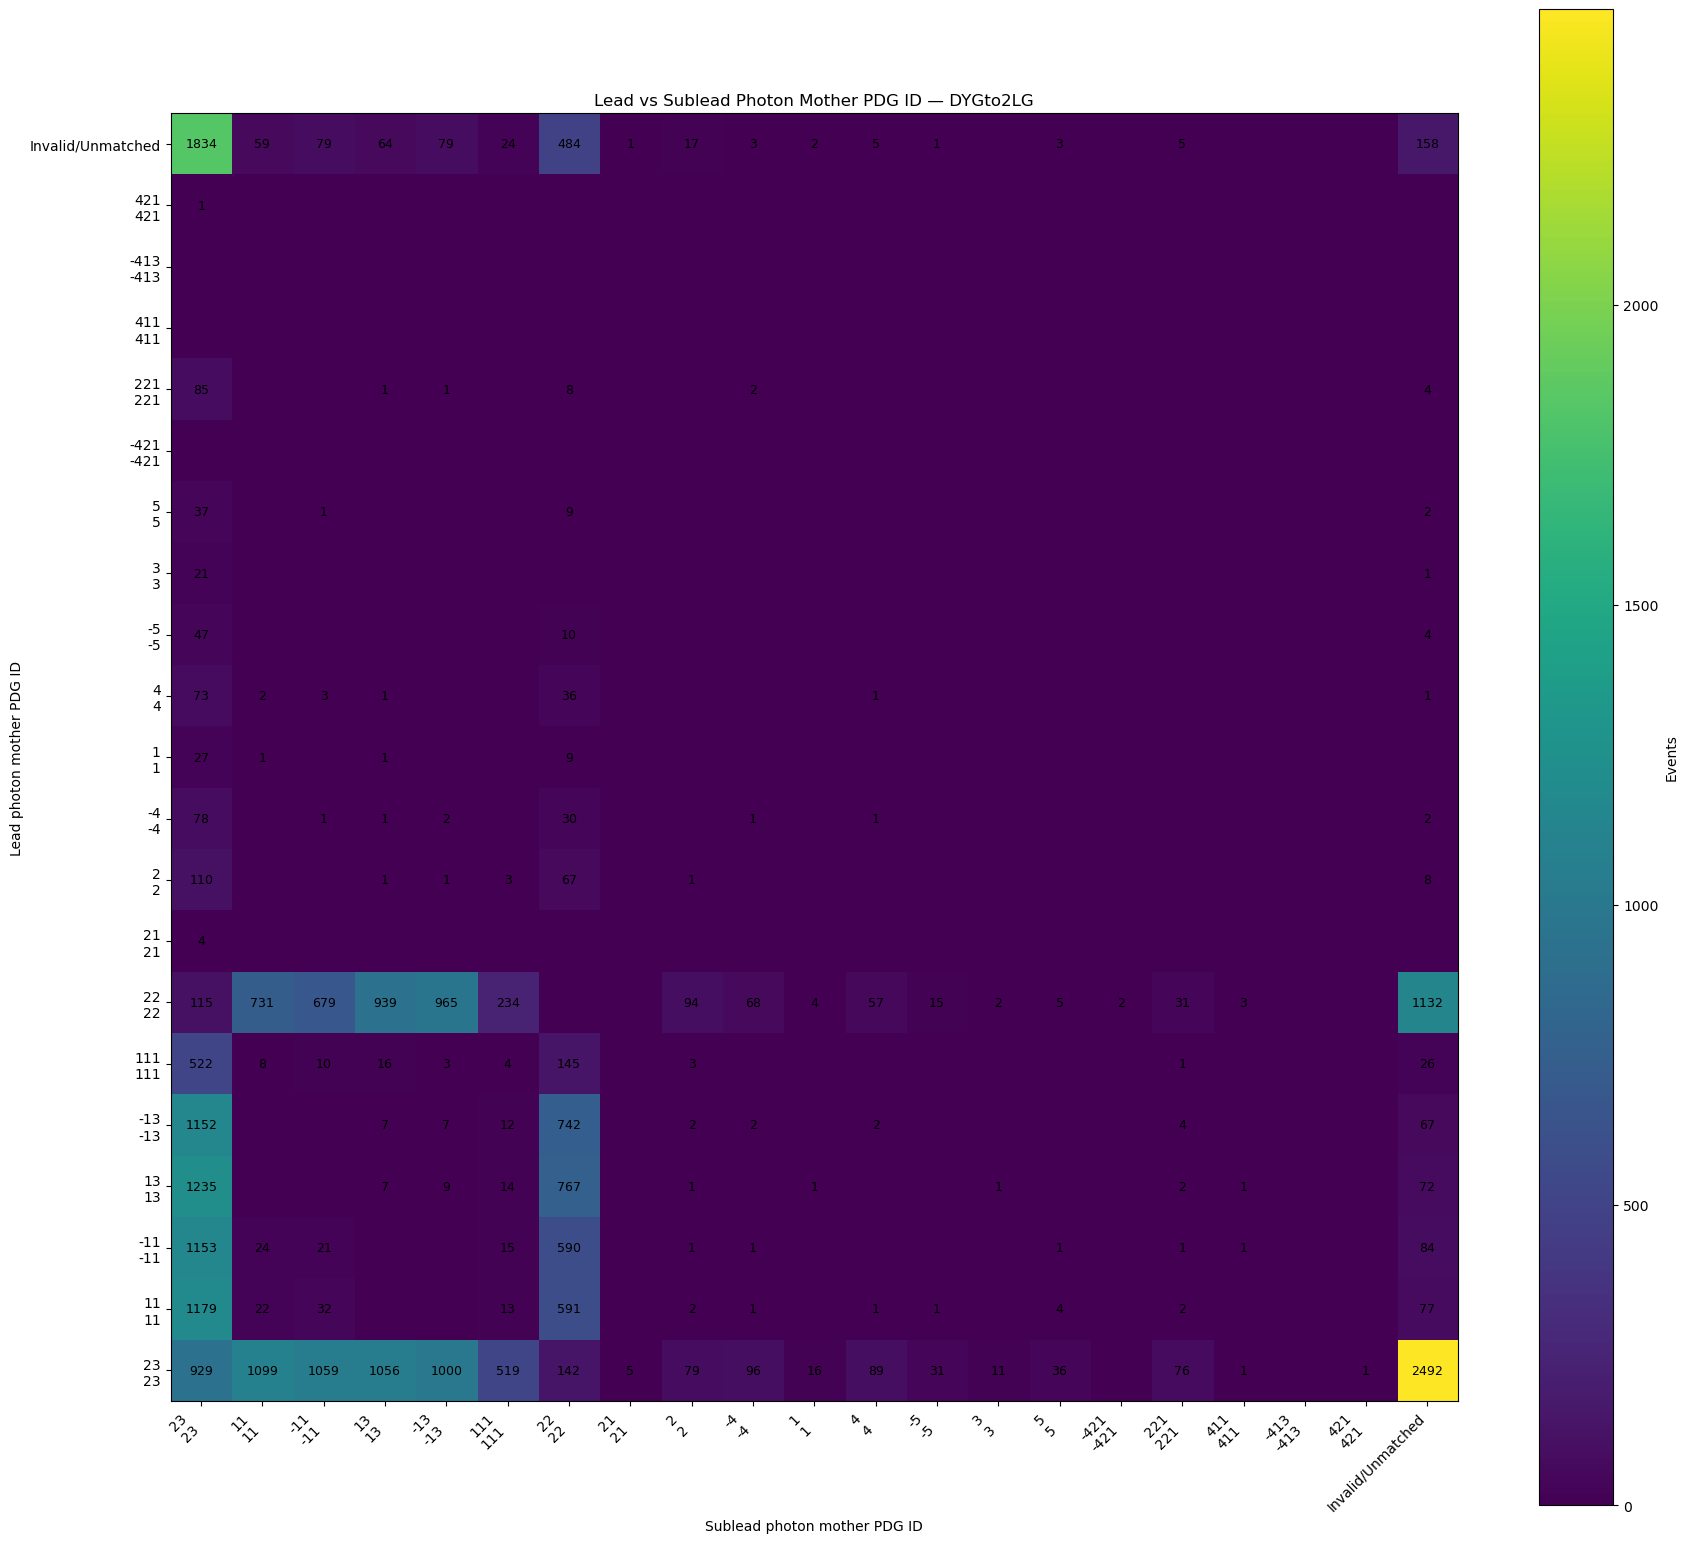

In [10]:
# plot_mother_2d(
#     valid_DYG_events,
#     "DYGto2LG",
#     "DYG_2Dforced"
# )

plot_mother_2d(
    events_DYG,
    "DYGto2LG",
    "DYG_2Dforced"
)

# plot_mother_2d(
#     valid_DYE_events,
#     "DY → e⁺e⁻",
#     "DYE_2Dforced"
# )

# plot_mother_2d(
#     valid_DYM_events,
#     "DY → μ⁺μ⁻",
#     "DYM_2Dforced"
# )

In [10]:
import awkward as ak
import matplotlib.colors as colors
import numpy as np

from pathlib import Path
import awkward as ak

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import correctionlib

output_dir = Path("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/DYGto2LG50_24SummerRun3_selected")

files = sorted(output_dir.glob("part_*.parquet"))

arrays = [ak.from_parquet(str(f)) for f in files]

events_DYG = ak.concatenate(arrays, axis=0)

print(f"Total events: {len(events_DYG)}")


def add_zero_photon_mass_and_charge(photons: ak.Array) -> ak.Array:
    """Add zero mass to the Photon object in the events."""
    # add zero photon mass and charge
    # TODO: remove this temporary fix when https://github.com/scikit-hep/vector/issues/498 is resolved
    photons["mass"] = ak.zeros_like(photons.pt)
    photons["charge"] = ak.zeros_like(photons.pt)
    return photons

def add_jetId(jets, flattenUnflatten=False):
    """
    Add (or recompute) jet ID to the jets object based on the NanoAOD version.
    """
    abs_eta = abs(jets.eta)

    jerc_json = "/eos/user/b/bbapi/HiggsDNA_220526/HiggsDNA/higgs_dna/systematics/JSONs/POG/JME/2024_Summer24/jetid.json.gz"

    cset = correctionlib.CorrectionSet.from_file(jerc_json)

    if flattenUnflatten:
        counts = ak.num(jets)
        jets = ak.flatten(jets, axis=1)

    eval_dict = {
        "eta": jets.eta,
        "chHEF": jets.chHEF,
        "neHEF": jets.neHEF,
        "chEmEF": jets.chEmEF,
        "neEmEF": jets.neEmEF,
        "muEF": jets.muEF,
        "chMultiplicity": jets.chMultiplicity,
        "neMultiplicity": jets.neMultiplicity,
        "multiplicity": jets.chMultiplicity + jets.neMultiplicity
    }

    ## Default tight for NanoAOD version 13 and above
    idTight = cset["AK4PUPPI_Tight"]
    inputsTight = [eval_dict[input.name] for input in idTight.inputs]
    idTight_value = idTight.evaluate(*inputsTight) * 2  # equivalent to bit2

    # Default tight lepton veto
    idTightLepVeto = cset["AK4PUPPI_TightLeptonVeto"]
    inputsTightLepVeto = [eval_dict[input.name] for input in idTightLepVeto.inputs]
    idTightLepVeto_value = idTightLepVeto.evaluate(*inputsTightLepVeto) * 4  # equivalent to bit3

    # Default jet ID
    id_value = idTight_value + idTightLepVeto_value

    if flattenUnflatten:
        return ak.unflatten(id_value, counts)
    else:
        return id_value


def delta_r_mask(first, second, threshold):
    deta = first.eta[:, :, None] - second.eta[:, None, :]
    dphi = np.arctan2(np.sin(first.phi[:, :, None] - second.phi[:, None, :]), np.cos(first.phi[:, :, None] - second.phi[:, None, :]))
    return ak.all((deta * deta + dphi * dphi) > threshold * threshold, axis=-1)

def build_diphoton_candidates(photons, min_pt_lead_photon):
    sorted_photons = photons[ak.argsort(photons.pt, ascending=False)]
    diphotons = ak.combinations(sorted_photons, 2, fields=["pho_lead", "pho_sublead"])
    diphotons = diphotons[diphotons["pho_lead"].pt > min_pt_lead_photon]
    pt1 = diphotons.pho_lead.pt
    eta1 = diphotons.pho_lead.eta
    phi1 = diphotons.pho_lead.phi
    mass1 = diphotons.pho_lead.mass
    pt2 = diphotons.pho_sublead.pt
    eta2 = diphotons.pho_sublead.eta
    phi2 = diphotons.pho_sublead.phi
    mass2 = diphotons.pho_sublead.mass
    px1 = pt1 * np.cos(phi1)
    py1 = pt1 * np.sin(phi1)
    pz1 = pt1 * np.sinh(eta1)
    e1 = np.sqrt(px1 * px1 + py1 * py1 + pz1 * pz1 + mass1 * mass1)
    px2 = pt2 * np.cos(phi2)
    py2 = pt2 * np.sin(phi2)
    pz2 = pt2 * np.sinh(eta2)
    e2 = np.sqrt(px2 * px2 + py2 * py2 + pz2 * pz2 + mass2 * mass2)
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    energy = e1 + e2
    pt = np.sqrt(px * px + py * py)
    phi = np.arctan2(py, px)
    eta = np.arcsinh(pz / pt)
    mass2_total = energy * energy - px * px - py * py - pz * pz
    mass = np.sqrt(np.maximum(mass2_total, 0))
    rapidity = 0.5 * np.log((energy + pz) / (energy - pz))
    diphotons["pt"] = pt
    diphotons["eta"] = eta
    diphotons["phi"] = phi
    diphotons["mass"] = mass
    diphotons["charge"] = diphotons.pho_lead.charge + diphotons.pho_sublead.charge
    diphotons["rapidity"] = rapidity
    diphotons = diphotons[ak.argsort(diphotons.pt, ascending=False)]
    return diphotons

def photon_preselection_bbgg(
    photons: ak.Array,
    events: ak.Array,
    electrons: ak.Array,
    muons: ak.Array
) -> ak.Array:

    dr_cut = delta_r_mask(photons, electrons, 0.2)
    dr_cut_muon = delta_r_mask(photons, muons, 0.2)

    return photons[
        (~photons.pixelSeed)
        & (photons.pt > 15.0)
        & (photons.isScEtaEB | photons.isScEtaEE)
        & dr_cut
        & dr_cut_muon
        &(ak.where(photons.isScEtaEB, photons.mvaID > 0.0439603, photons.mvaID > -0.249526))
    ]


def select_electrons_bbgg(
    electrons: ak.highlevel.Array
) -> ak.highlevel.Array:
    pt_cut = electrons.pt > 30

    eta_cut = abs(electrons.eta) < 2.5

    id_cut = electrons.mvaIso_WP80

    return pt_cut & eta_cut & id_cut

def select_muons_bbgg(
    muons: ak.highlevel.Array
) -> ak.highlevel.Array:
    pt_cut = muons.pt > 26.0

    eta_cut = abs(muons.eta) < 2.4

    id_cut = muons.mediumId
        
    iso_cut = muons.pfIsoId >= 3
   
    global_cut = muons.isGlobal

    return pt_cut & eta_cut & id_cut & iso_cut & global_cut 


def select_jets_bbgg(
    jets: ak.highlevel.Array,
    diphotons: ak.highlevel.Array,
    muons: ak.highlevel.Array,
    electrons: ak.highlevel.Array,
    clean_jet_pho: bool = True,
    clean_jet_ele: bool = True,
    clean_jet_muo: bool = True
) -> ak.highlevel.Array:
    

    jetId_cut = jets.jetId >= 2

    pt_cut = jets.pt > 20
    eta_cut = abs(jets.eta) < 2.4

    if (clean_jet_pho) & (ak.num(diphotons.pt, axis=0) > 0):
        lead = ak.zip(
            {
                "pt": diphotons.pho_lead.pt,
                "eta": diphotons.pho_lead.eta,
                "phi": diphotons.pho_lead.phi,
                "mass": diphotons.pho_lead.mass,
                "charge": diphotons.pho_lead.charge,
            }
        )
        lead = ak.with_name(lead, "PtEtaPhiMCandidate")
        sublead = ak.zip(
            {
                "pt": diphotons.pho_sublead.pt,
                "eta": diphotons.pho_sublead.eta,
                "phi": diphotons.pho_sublead.phi,
                "mass": diphotons.pho_sublead.mass,
                "charge": diphotons.pho_sublead.charge,
            }
        )
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        sublead = ak.with_name(sublead, "PtEtaPhiMCandidate")
        dr_pho_lead_cut = delta_r_mask(jets, lead, 0.4)
        dr_pho_sublead_cut = delta_r_mask(jets, sublead, 0.4)
    else:
        dr_pho_lead_cut = jets.pt > -1
        dr_pho_sublead_cut = jets.pt > -1

    if (clean_jet_ele) & (ak.num(electrons.pt, axis=0) > 0):
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        dr_electrons_cut = delta_r_mask(jets, electrons, 0.4)
    else:
        dr_electrons_cut = jets.pt > -1

    if (clean_jet_muo) & (ak.num(muons.pt, axis=0) > 0):
        jets = ak.with_name(jets, "PtEtaPhiMCandidate")
        dr_muons_cut = delta_r_mask(jets, muons, 0.4)
    else:
        dr_muons_cut = jets.pt > -1

    return (
        (jetId_cut)
        & (pt_cut)
        & (eta_cut)
        & (dr_pho_lead_cut)
        & (dr_pho_sublead_cut)
        & (dr_electrons_cut)
        & (dr_muons_cut)
    )


def select_events(events):
    electrons = events.Electron
    muons = events.Muon
    photons = events.Photon
    photons = add_zero_photon_mass_and_charge(photons)
    Jets = events.Jet
    Jet_id = add_jetId(Jets, flattenUnflatten=True)
    events["Jet"] = ak.with_field(Jets, Jet_id, "jetId")
    jets = events.Jet
    genPart = events.GenPart

    electrons = electrons[select_electrons_bbgg(electrons)]
    muons = muons[select_muons_bbgg(muons)]
    photons = photon_preselection_bbgg(photons, events, electrons, muons)
    diphotons = build_diphoton_candidates(photons, 15.0)
    jets = jets[select_jets_bbgg(jets, diphotons, muons, electrons)]

    one_ele = ak.num(electrons) == 1
    zero_ele = ak.num(electrons) == 0

    one_mu = ak.num(muons) == 1
    zero_mu = ak.num(muons) == 0

    # Define the two exclusive channels
    electron_channel = one_ele & zero_mu
    muon_channel     = one_mu & zero_ele


    lepton_channel_mask = electron_channel | muon_channel


    b_jets = jets[jets.btagUParTAK4B > 0.1272]
    at_least_one_bjets = ak.num(b_jets) >= 1
    at_least_two_photons = ak.num(photons) >= 2

    event_mask = (lepton_channel_mask & at_least_two_photons & at_least_one_bjets)


    photons = photons[event_mask]
    electrons = electrons[event_mask]
    muons = muons[event_mask]
    b_jets = b_jets[event_mask]
    n_bjets = ak.num(b_jets)
    events = events[event_mask]
    genPart = genPart[event_mask]

    photons = photons[ak.argsort(photons.pt, ascending=False)]

    return events, photons, genPart


import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import os


forced_pdgids = [23, 11, -11, 13, -13, 111, 22, 21, 2, -4, 1, 4, -5, 3, 5, -421, 221, 411, -413, 421, -999]

x_pdgids = forced_pdgids
y_pdgids = forced_pdgids


def get_photon_mother_pdgids(photons, genPart):

    photon_genparts = genPart[ak.where(photons.genPartIdx >= 0, photons.genPartIdx, 0)]

    valid_photon = photons.genPartIdx >= 0

    mother_idx = ak.where(valid_photon, photon_genparts.genPartIdxMother, -1)

    valid_mother = mother_idx >= 0

    mother_pdgId = ak.where(valid_mother, genPart[ak.where(valid_mother, mother_idx, 0)].pdgId, -999)

    return mother_pdgId

# =========================================================
# Build lead/sublead mother pair counts
# =========================================================

def get_pair_counts(photons, genPart):

    mother_pdgids = get_photon_mother_pdgids(
        photons,
        genPart
    )

    # photons are already pT sorted by select_events()
    lead = ak.to_numpy(mother_pdgids[:, 0])
    sublead = ak.to_numpy(mother_pdgids[:, 1])

    pair_counts = {}

    for l, s in zip(lead, sublead):
        pair = (int(l), int(s))
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

    return pair_counts


# =========================================================
# 2D plotting function
# =========================================================
def pdgid_to_name(pdgid):
    try:
        p = Particle.from_pdgid(int(pdgid))
        return p.name if p is not None else str(int(pdgid))
    except Exception:
        return str(int(pdgid))

def plot_mother_2d(photons, genPart, sample_name, output_name):

    pair_counts = get_pair_counts(photons, genPart)

    matrix = np.zeros(
        (len(y_pdgids), len(x_pdgids)),
        dtype=int
    )

    for (lead, sublead), count in pair_counts.items():

        if lead in y_pdgids and sublead in x_pdgids:

            i = y_pdgids.index(lead)
            j = x_pdgids.index(sublead)

            matrix[i, j] = count


    # =====================================================
    # Plot
    # =====================================================

    fig, ax = plt.subplots(figsize=(18, 16))

    im = ax.imshow(
        matrix,
        aspect="equal",
        origin="lower"
    )

    x_labels = ["Invalid/Unmatched" if pdgid == -999 else f"{pdgid}\n{pdgid_to_name(pdgid)}" for pdgid in x_pdgids]
    y_labels = ["Invalid/Unmatched" if pdgid == -999 else f"{pdgid}\n{pdgid_to_name(pdgid)}" for pdgid in y_pdgids]

    ax.set_xticks(np.arange(len(x_pdgids)))
    ax.set_yticks(np.arange(len(y_pdgids)))

    ax.set_xticklabels(
        x_labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(y_labels)

    ax.set_xlabel(
        "Sublead photon mother PDG ID"
    )

    ax.set_ylabel(
        "Lead photon mother PDG ID"
    )

    ax.set_title(
        f"Lead vs Sublead Photon Mother PDG ID — {sample_name}"
    )

    # Write counts inside cells
    # for i in range(len(y_pdgids)):
    #     for j in range(len(x_pdgids)):

    #         if matrix[i, j] != 0:
    #             ax.text(
    #                 j,
    #                 i,
    #                 str(matrix[i, j]),
    #                 ha="center",
    #                 va="center",
    #                 fontsize=9
    #             )

    norm = colors.Normalize(vmin=matrix.min(), vmax=matrix.max())
    cmap = plt.get_cmap("viridis")

    for i in range(len(y_pdgids)):
        for j in range(len(x_pdgids)):
            if matrix[i, j] != 0:

                rgba = cmap(norm(matrix[i, j]))

                # Perceived brightness
                brightness = (
                    0.299 * rgba[0] +
                    0.587 * rgba[1] +
                    0.114 * rgba[2]
                )

                text_color = "white" if brightness < 0.5 else "black"

                ax.text(
                    j,
                    i,
                    str(matrix[i, j]),
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=text_color
                )

    print("matrix(-999, -999)", matrix[-1, -1])

    fig.colorbar(
        im,
        ax=ax,
        label="Events"
    )

    plt.tight_layout()

    plt.savefig(
        output_name,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# events_DYG, photons_DYG, genPart_DYG = select_events(events_DYG)

# plot_mother_2d(
#     photons_DYG,
#     genPart_DYG,
#     "DYGto2LG",
#     "DYG_2Dforced"
# )


Total events: 26546


26546


matrix(-999, -999) 0


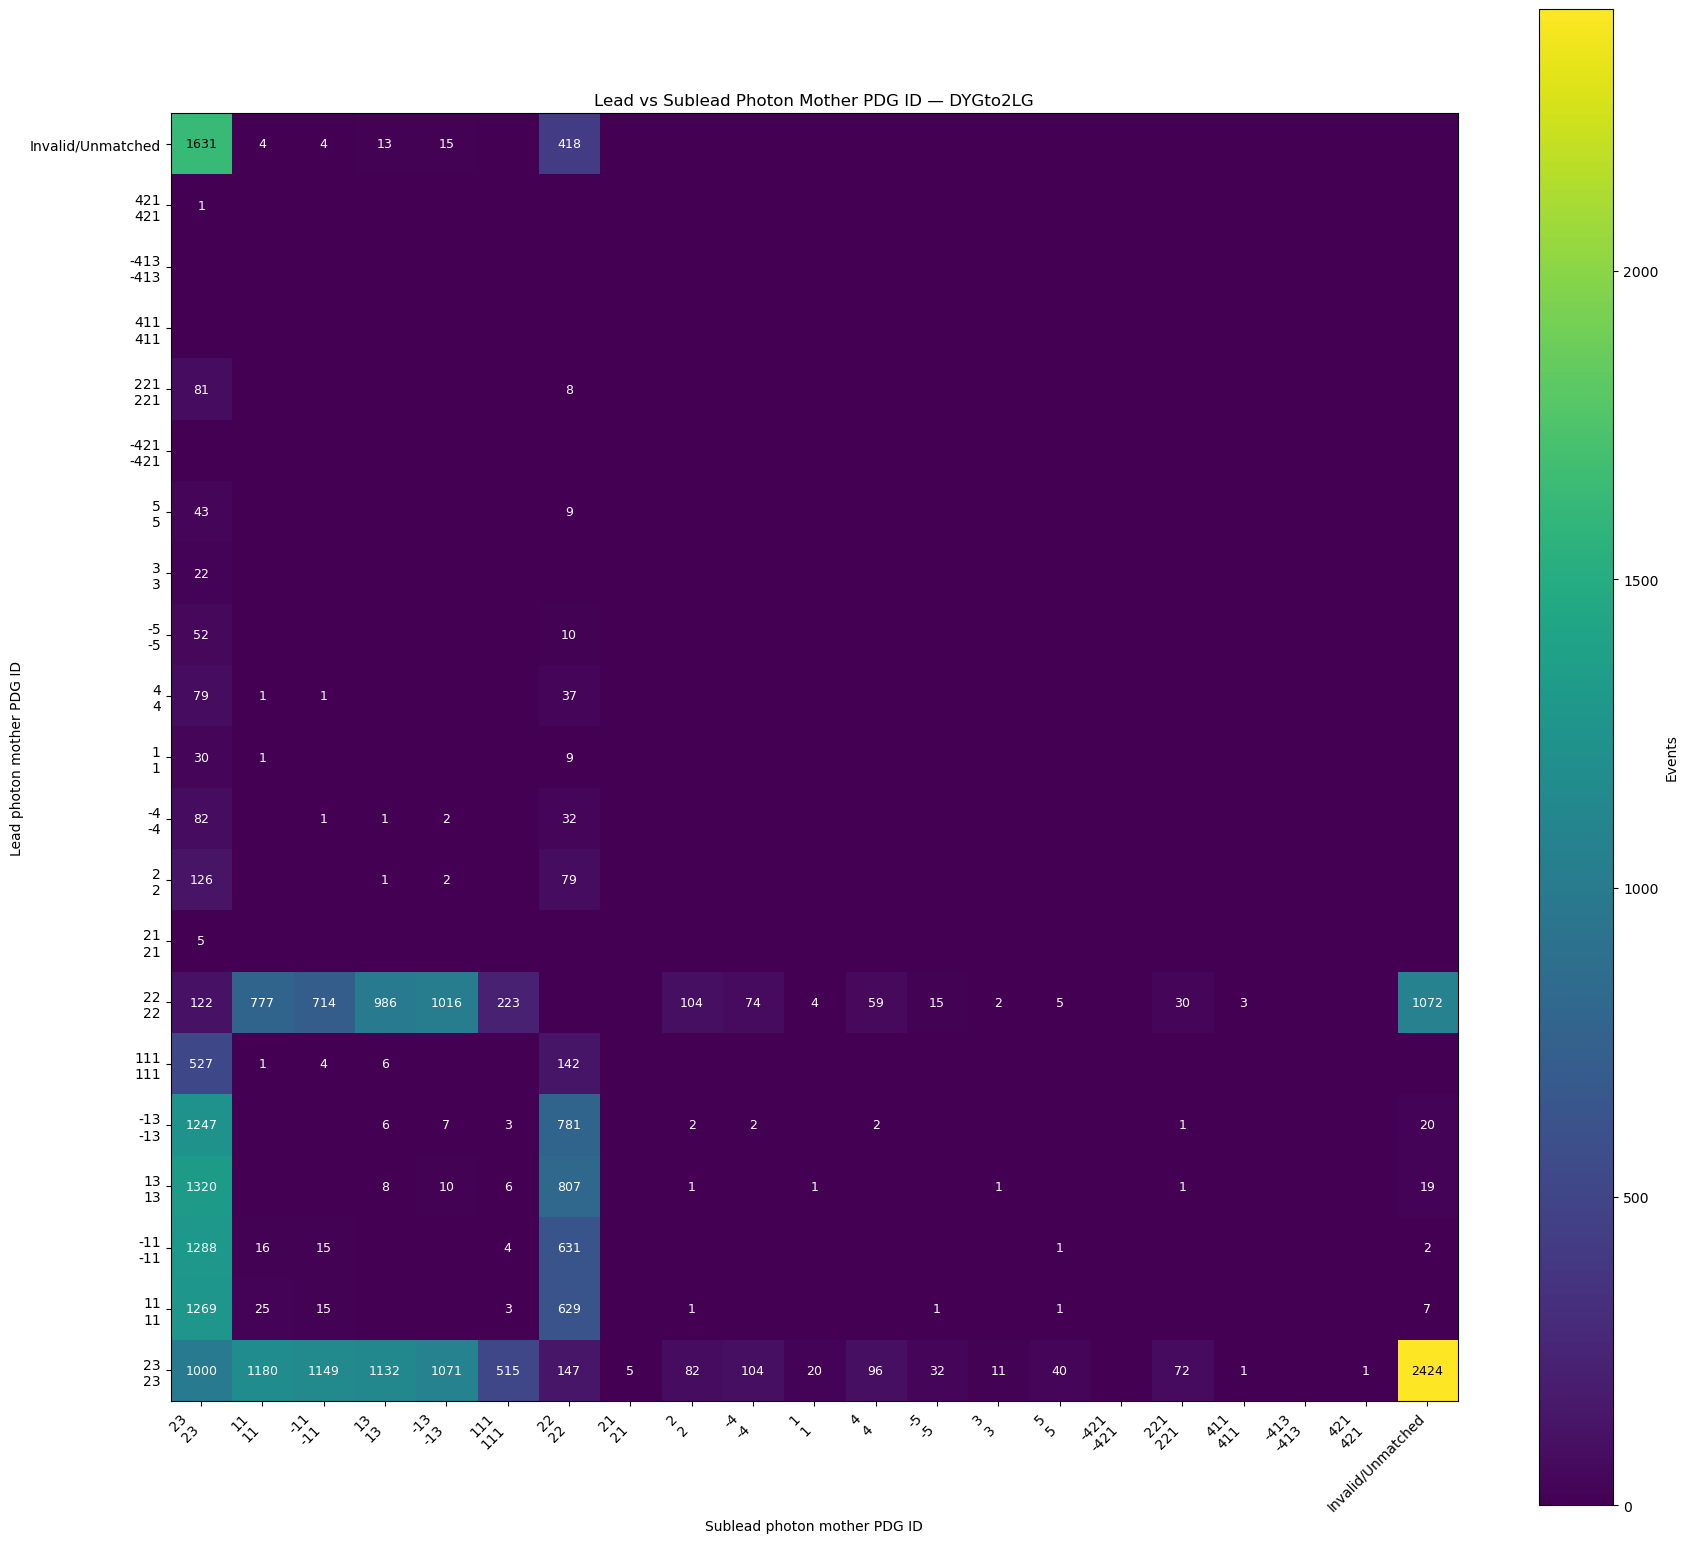

matrix(-999, -999) 50


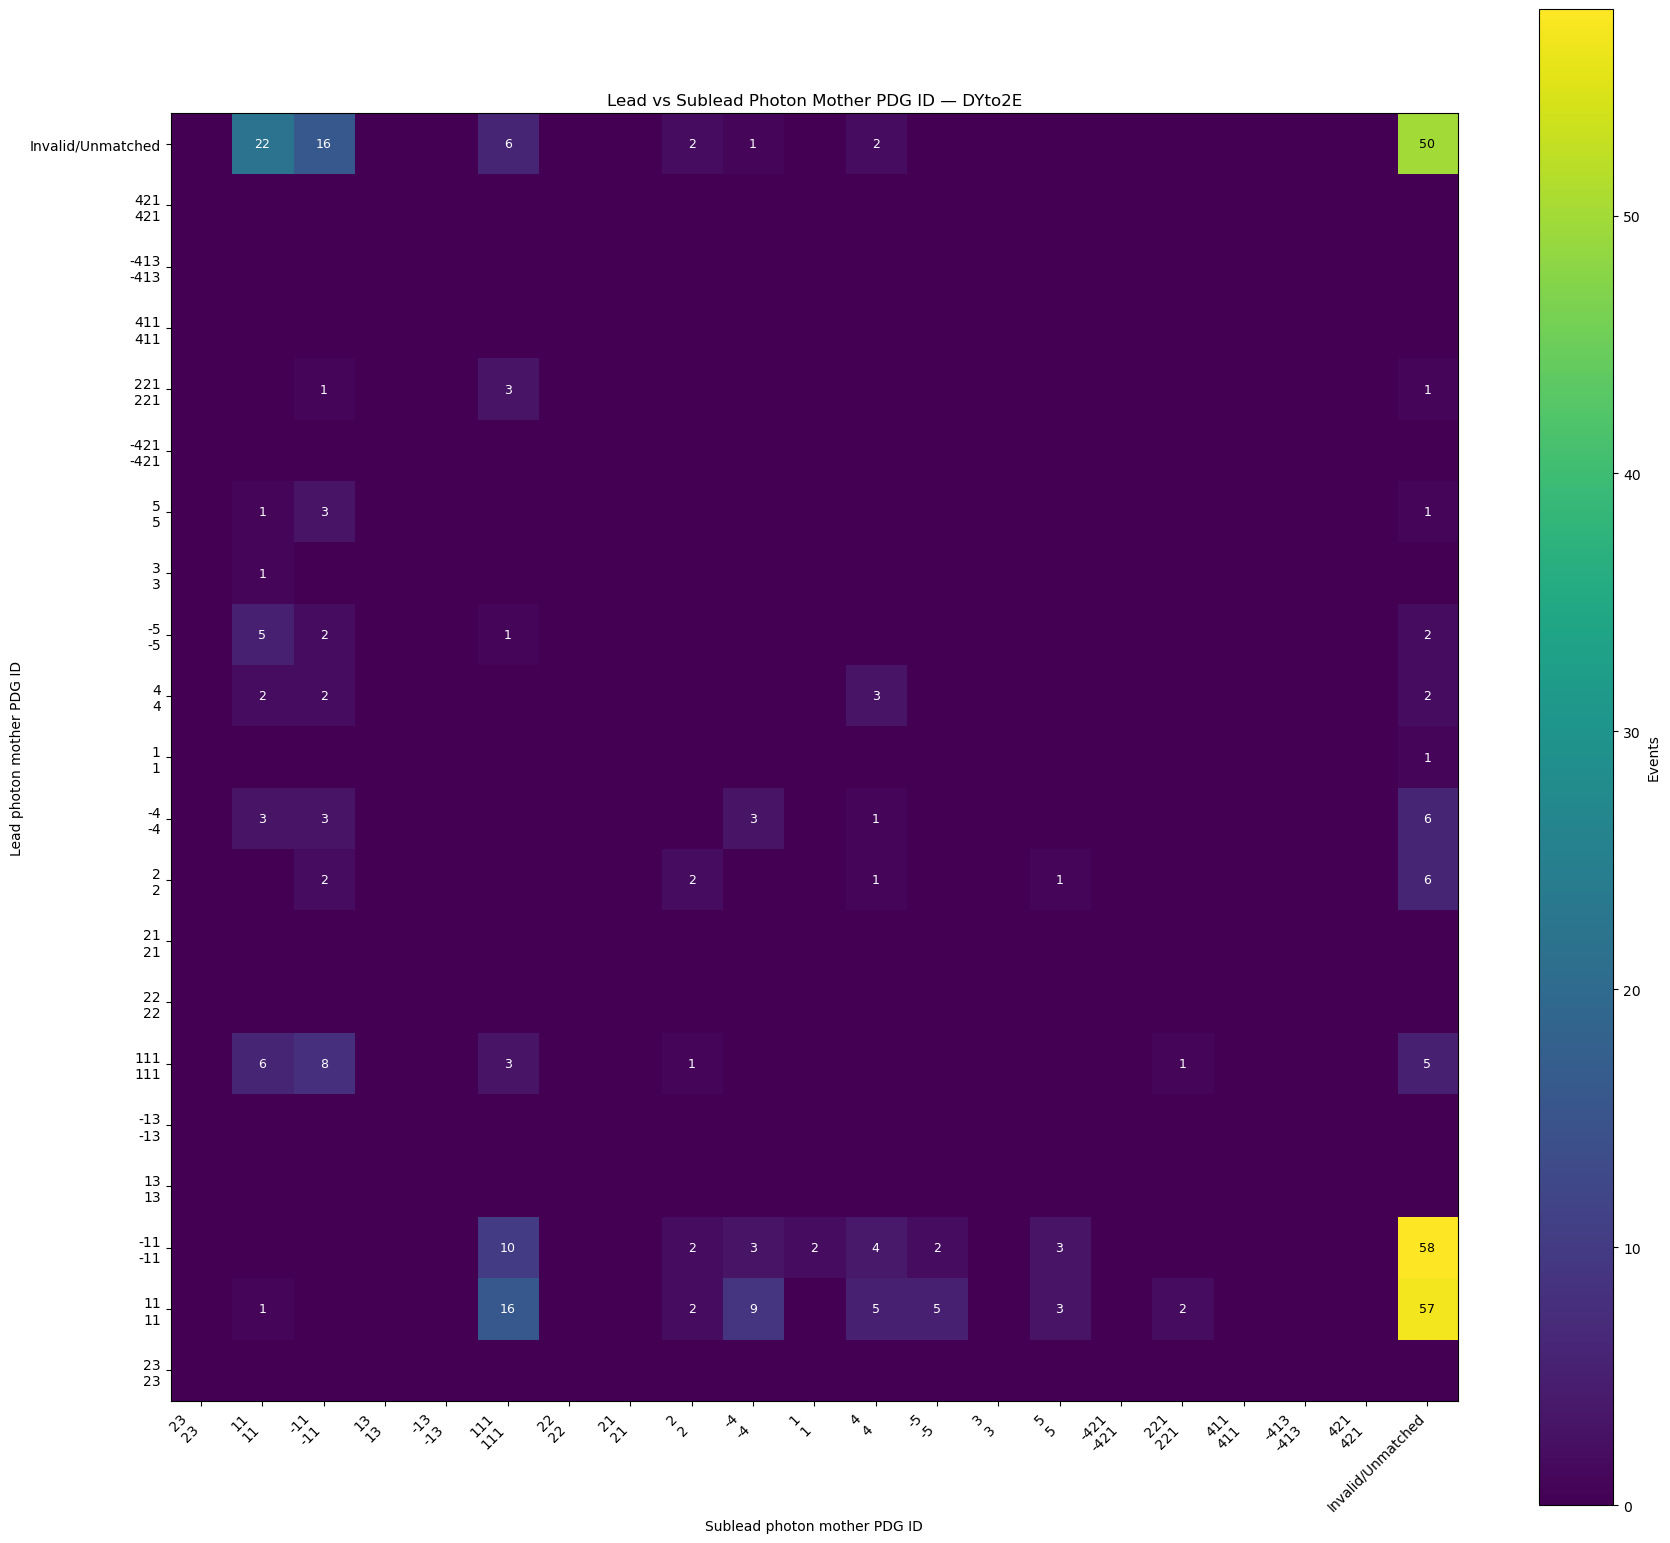

matrix(-999, -999) 58


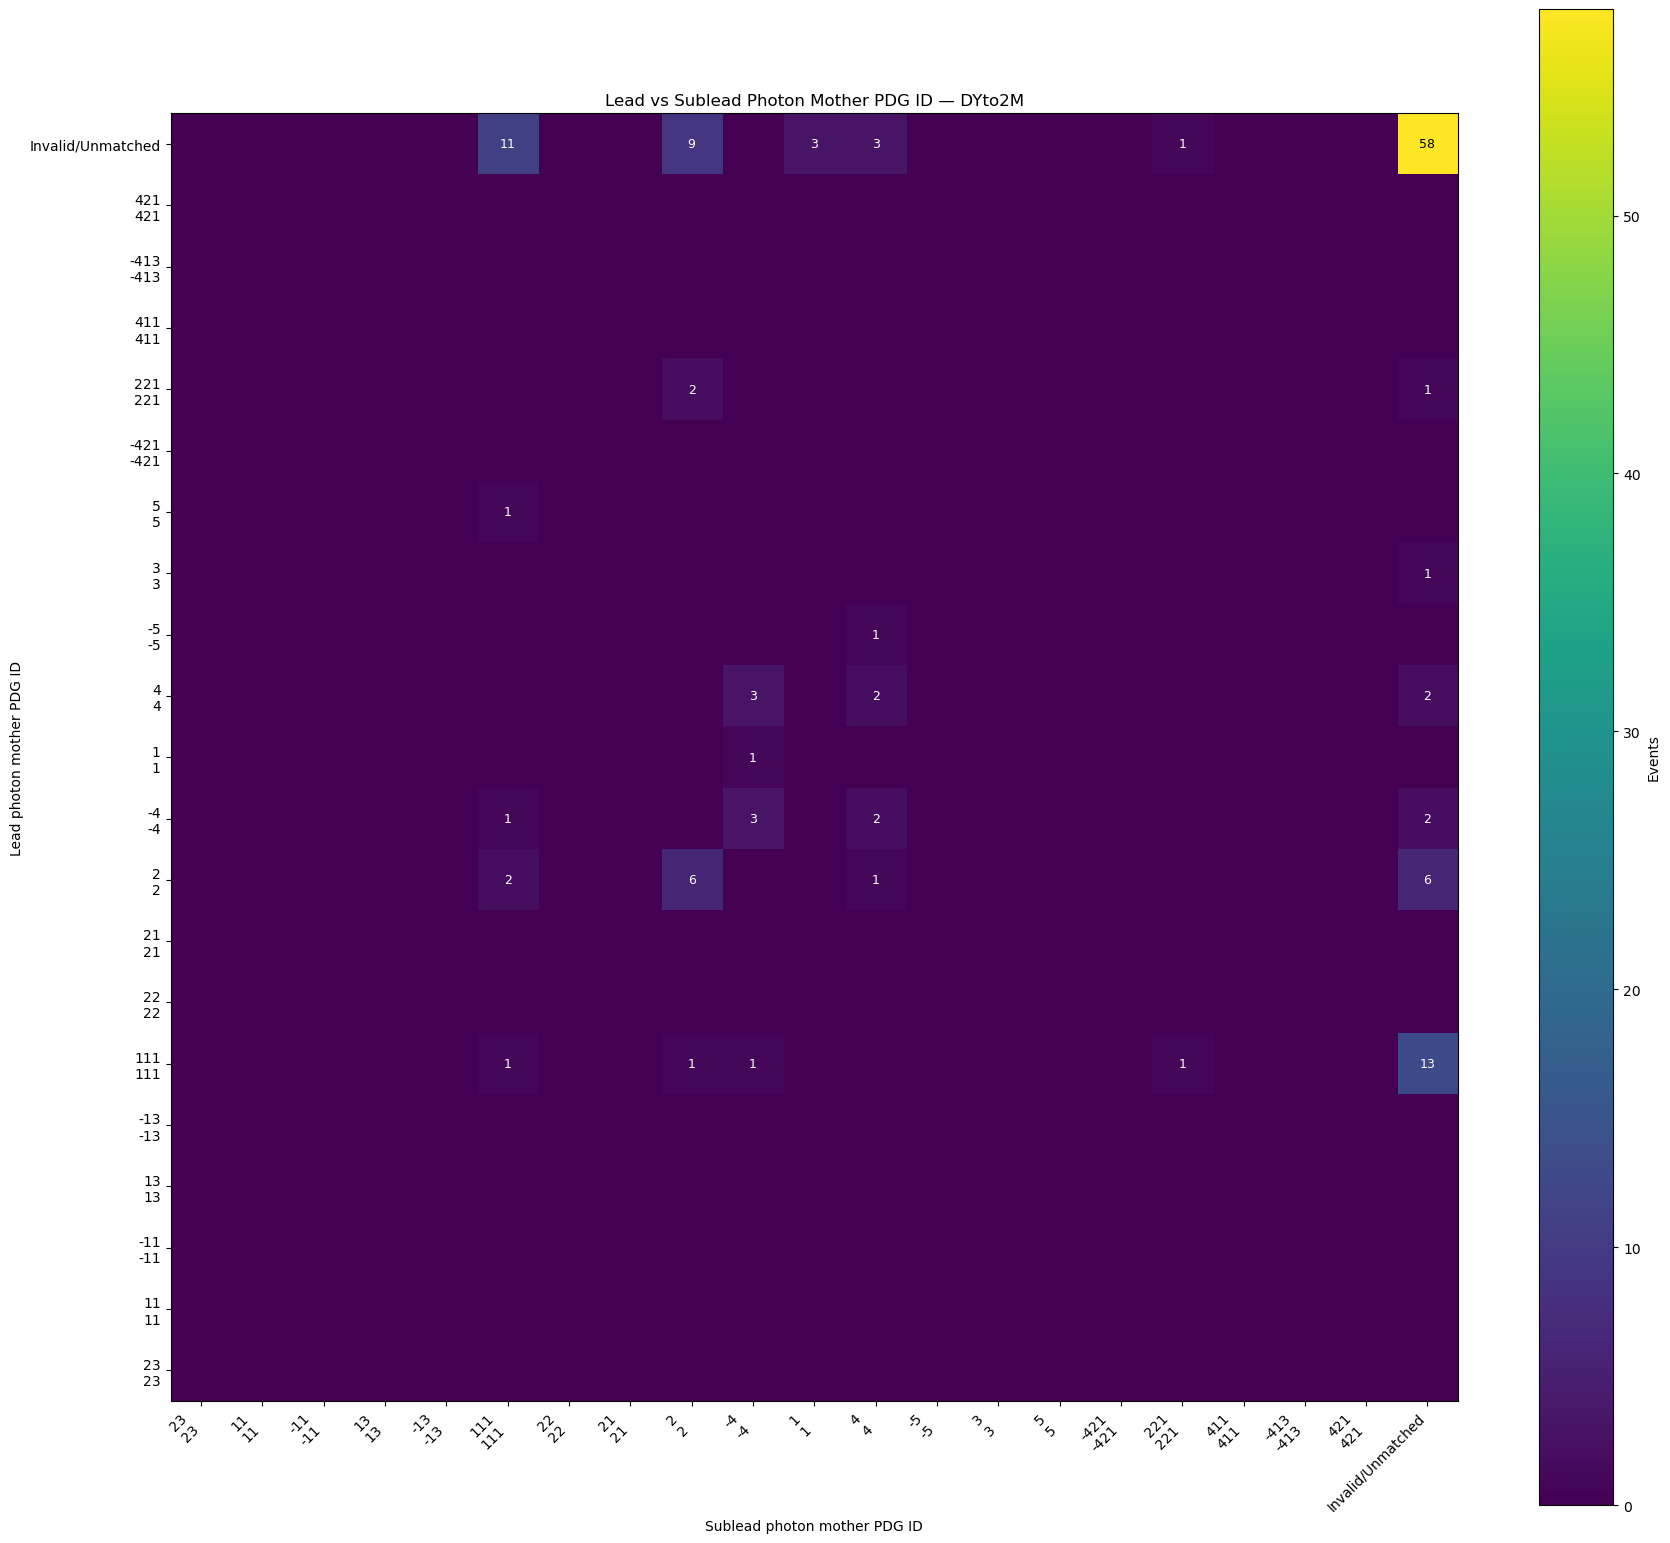

In [11]:
def photon_from_DYG(photons, genpart):

    # Sort photons by pT
    order = ak.argsort(
        photons.pt,
        axis=1,
        ascending=False
    )
    photons = photons[order]

    # Leading and subleading photons
    photons = photons[:, :2]

    idx = photons.genPartIdx
    valid = idx >= 0

    # GenPart matched to reco photon
    photon = ak.mask(
        genpart[idx],
        valid
    )

    # Direct mother
    mother_idx = photon.genPartIdxMother

    mother = ak.mask(
        genpart[mother_idx],
        mother_idx >= 0
    )

    # PDG IDs
    photon_pdgId = photon.pdgId
    mother_pdgId = mother.pdgId

    # ------------------------------------------------
    # Case 1:
    # Matched GenPart is a photon,
    # and its mother is a lepton
    # ------------------------------------------------
    from_lepton = (
        (abs(photon_pdgId) == 22)
        &
        (
            (abs(mother_pdgId) == 11)
            |
            (abs(mother_pdgId) == 13)
        )
    )

    # ------------------------------------------------
    # Case 2:
    # Direct mother is Z
    # ------------------------------------------------
    from_Z = abs(mother_pdgId) == 23

    # ------------------------------------------------
    # Case 3:
    # Direct mother is photon
    # ------------------------------------------------
    from_gamma = abs(mother_pdgId) == 22

    # ------------------------------------------------
    # DYG photon
    # ------------------------------------------------
    is_DYG_photon = (
        from_lepton
        |
        from_Z
        |
        from_gamma
    )

    # Either leading OR subleading photon is DYG
    event_is_DYGto2LG = ak.any(
        is_DYG_photon,
        axis=1
    )

    return event_is_DYGto2LG



print(len(events_DYG))

# =========================================================
# First apply physics selection
# =========================================================

events_DYG, photons_DYG, genPart_DYG = select_events(events_DYG)
events_DYE, photons_DYE, genPart_DYE = select_events(events)
events_DYM, photons_DYM, genPart_DYM = select_events(events_Mu)


# =========================================================
# Then classify using EXACTLY those selected photons
# =========================================================

DYG_mask = photon_from_DYG(
    photons_DYG,
    genPart_DYG
)

DYE_mask = photon_from_DYG(
    photons_DYE,
    genPart_DYE
)

DYM_mask = photon_from_DYG(
    photons_DYM,
    genPart_DYM
)


# =========================================================
# Apply masks directly to all three collections
# =========================================================

valid_DYG_events = events_DYG[DYG_mask]
valid_DYG_photons = photons_DYG[DYG_mask]
valid_DYG_genPart = genPart_DYG[DYG_mask]

valid_DYE_events = events_DYE[~DYE_mask]
valid_DYE_photons = photons_DYE[~DYE_mask]
valid_DYE_genPart = genPart_DYE[~DYE_mask]

valid_DYM_events = events_DYM[~DYM_mask]
valid_DYM_photons = photons_DYM[~DYM_mask]
valid_DYM_genPart = genPart_DYM[~DYM_mask]

plot_mother_2d(
    valid_DYG_photons,
    valid_DYG_genPart,
    "DYGto2LG",
    "DYG_2Dforced"
)

plot_mother_2d(
    valid_DYE_photons,
    valid_DYE_genPart,
    "DYto2E",
    "DYE_2Dforced"
)

plot_mother_2d(
    valid_DYM_photons,
    valid_DYM_genPart,
    "DYto2M",
    "DYM_2Dforced"
)
